# IMPORT LIBRARIES & CLEARML SETUP
- Import all required libraries
- Configure ClearML for experiment tracking

In [15]:
# ============================================================================
# 📚 SECTION 0: IMPORT LIBRARIES & CLEARML SETUP
# ============================================================================

# ==========================================
# 📦 CORE LIBRARIES
# ==========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ==========================================
# 🤖 MACHINE LEARNING LIBRARIES
# ==========================================
# Sklearn - Models
from sklearn.ensemble import (
    RandomForestRegressor, 
    GradientBoostingRegressor, 
    ExtraTreesRegressor,
    AdaBoostRegressor,
    BaggingRegressor
)
from sklearn.linear_model import (
    LinearRegression,
    Ridge,
    Lasso,
    ElasticNet,
    HuberRegressor,
    BayesianRidge
)
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.neural_network import MLPRegressor

# Sklearn - Preprocessing & Metrics
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Boosting Libraries
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

# Hyperparameter Optimization
import optuna
from optuna.samplers import TPESampler

# Model Persistence
import joblib
import os
import sys
import time
from datetime import timedelta

# ==========================================
# 🔧 CLEARML SETUP
# ==========================================
print(f"🐍 Python executable: {sys.executable}\n")

# Set ClearML credentials
os.environ['CLEARML_WEB_HOST'] = 'https://app.clear.ml'
os.environ['CLEARML_API_HOST'] = 'https://api.clear.ml'
os.environ['CLEARML_FILES_HOST'] = 'https://files.clear.ml'
os.environ['CLEARML_API_ACCESS_KEY'] = 'J5WRKN4TPMIZNR6UFE18HHVQISCLIE'
os.environ['CLEARML_API_SECRET_KEY'] = 'CDFJ26MFOfmqnfSxEOfRnawhIVnqutqe7g3_pw5Z-YmCXwNmcq_O0Ok9KPKnIYUvZ9E'

# Import ClearML
try:
    from clearml import Task, Logger
    CLEARML_AVAILABLE = True
    print("✅ ClearML imported successfully!")
    print("📊 Visit https://app.clear.ml to view your experiments\n")
except ImportError:
    CLEARML_AVAILABLE = False
    print("⚠️  ClearML not installed. Install with: pip install clearml")
    print("   Continuing without experiment tracking...\n")

# Initialize ClearML Task
task = None
logger = None

if CLEARML_AVAILABLE:
    try:
        task = Task.init(
            project_name='Temperature_Prediction_Hanoi',
            task_name='Feature_Engineering_Complete_Pipeline_v2',
            tags=['feature-engineering', 'temperature', 'time-series', 'hanoi', 'optuna'],
            reuse_last_task_id=False
        )
        logger = task.get_logger()
        
        print("✅ ClearML Task initialized successfully!")
        print(f"📊 Project: Temperature_Prediction_Hanoi")
        print(f"🏷️  Task: Feature_Engineering_Complete_Pipeline_v2")
        print(f"🌐 View dashboard: https://app.clear.ml\n")
        
    except Exception as e:
        print(f"⚠️  ClearML configuration error: {str(e)}")
        print("   Continuing without experiment tracking...\n")
        task = None
        logger = None
        CLEARML_AVAILABLE = False

print("="*80)
print("✅ ALL LIBRARIES LOADED SUCCESSFULLY")
print("="*80)

🐍 Python executable: c:\Users\ADMIN\AppData\Local\Programs\Python\Python310\python.exe

✅ ClearML imported successfully!
📊 Visit https://app.clear.ml to view your experiments

✅ ClearML Task initialized successfully!
📊 Project: Temperature_Prediction_Hanoi
🏷️  Task: Feature_Engineering_Complete_Pipeline_v2
🌐 View dashboard: https://app.clear.ml

✅ ALL LIBRARIES LOADED SUCCESSFULLY


In [4]:
import sys
print(sys.executable)

c:\Users\ADMIN\AppData\Local\Programs\Python\Python310\python.exe


# FEATURE ENGINEERING & MODEL TRAINING FOR DAILY DATA**
1. **Feature Engineering**
2. **Scaler Testing**
3. **Optuna Hyperparameter Tuning**
4. **Direct ML model Training**
5. **Multi-output model Training**
6. **Training Comparison, Analysis & Visualization**
7. **Prediction using ML models**
8. **Prediction using Integrated Time series models**
9. **Retraining models**
9. **ONNX Export**

In [16]:
# ==========================================
# 1️⃣ LOAD PROCESSED DATA
# ==========================================

print("\n" + "="*80)
print("📂 LOADING DAILY DATA")
print("="*80)

read_dir = '../data/processed/'
train_data = pd.read_excel(read_dir + 'train_data.xlsx')
val_data = pd.read_excel(read_dir + 'val_data.xlsx')
test_data = pd.read_excel(read_dir + 'test_data.xlsx')

print(f"✅ Train data shape: {train_data.shape}")
print(f"✅ Validation data shape: {val_data.shape}")
print(f"✅ Test data shape: {test_data.shape}")
print(f"📅 Date range: {train_data['datetime'].min()} to {test_data['datetime'].max()}")


📂 LOADING DAILY DATA
✅ Train data shape: (2831, 81)
✅ Validation data shape: (456, 81)
✅ Test data shape: (640, 81)
📅 Date range: 2015-01-01 00:00:00 to 2025-10-01 00:00:00
✅ Train data shape: (2831, 81)
✅ Validation data shape: (456, 81)
✅ Test data shape: (640, 81)
📅 Date range: 2015-01-01 00:00:00 to 2025-10-01 00:00:00


# **1. Feature Engineering**
Our feature engineering process is guided by three core principles derived from extensive data analysis and domain knowledge:


**Principle 1: Avoiding Target Leakage from Temperature Variables**

During our **Data Understanding** phase, we discovered that variables in the **`temp` family** (`tempmax`, `tempmin`, `feelslike`, `feelslikemax`, `feelslikemin`) exhibit **extremely high correlation** (>0.9) with our target variable `temp`.

**Why We Excluded Them:**
Including these variables would create **severe overfitting** because:
- `tempmax` and `tempmin` are direct derivatives of `temp` (same-day measurements)
- `feelslike*` variables are calculated using `temp` as a primary input
- The model would "cheat" by memorizing current-day temperature patterns rather than learning predictive relationships

**Impact:**
By removing these 5 highly correlated features, we ensure the model learns genuine weather patterns from **independent meteorological variables** like pressure, humidity, wind, and solar radiation.

**Principle 2: Derived Features from Meteorological Relationships**

We created **physics-informed and interaction features** to capture non-linear weather dynamics:

**2.1. Atmospheric Dynamics**

| Feature | Formula | Physical Meaning |
|---------|---------|------------------|
| `pressure_daily_change` | `sealevelpressure.diff(3)` | Rate of pressure change over 3 days (storm/front indicator) |
| `solar_cloud_interaction` | `solarradiation × (1 - cloudcover/100)` | Actual solar energy reaching ground after cloud attenuation |

**2.2. Wind Components (U/V Decomposition)**

```python
wind_U = windspeed × sin(2π × winddir / 360)  # Zonal component (East-West)
wind_V = windspeed × cos(2π × winddir / 360)  # Meridional component (North-South)
```

**Why?** Converts circular wind direction into Cartesian coordinates for better ML model learning.

**2.3. Energy & Moisture Indices**

| Feature | Formula | Purpose |
|---------|---------|---------|
| `daylight_duration_hours` | `(sunset - sunrise).total_seconds() / 3600` | Day length (seasonal indicator) |
| `wind_gust_ratio` | `windgust / (windspeed + 1e-6)` | Turbulence intensity |

---

**2.4. Polynomial & Logarithmic Transformations**

For **11 key meteorological variables**, we created **non-linear transformations** to capture saturation effects and physical limits:

```python
features = ['humidity', 'dew', 'precip', 'precipcover', 'windspeed', 
            'windgust', 'solarenergy', 'solarradiation', 'cloudcover', 
            'daylight_duration_hours', 'sealevelpressure']

transformations = [x², x³, √x, log(1+x)]
```
**Why Non-Linear Transformations?**

**Machine Learning models (especially linear models like Ridge, Lasso) assume linear relationships by default.** However, many meteorological processes exhibit **non-linear behavior** that cannot be captured with raw features alone.

**Example Problem:**
- Raw feature: `humidity = 80%` → Temperature impact = +5°C
- If relationship is linear: `humidity = 90%` → Impact should be +5.625°C
- **Reality**: At high humidity (>90%), the impact **saturates** (diminishing returns)
Non-linear transformations allow **linear models** to learn these curved relationships by creating explicit non-linear features.
---

** Transformation Breakdown**

| Transformation | Formula | Physical/Statistical Meaning | When to Use |
|----------------|---------|------------------------------|-------------|
| **Square (x²)** | `feature²` | **Quadratic saturation** - Effect increases faster at extreme values | When variable has accelerating impact (e.g., high wind speeds cause exponentially more cooling) |
| **Cube (x³)** | `feature³` | **Cubic non-linearity** - Even stronger saturation at extremes | Captures extreme event dynamics (e.g., storm intensification) |
| **Square Root (√x)** | `√feature` | **Diminishing returns** - Effect grows slower as value increases | When variable has saturation effects (e.g., cloud cover: 80%→90% has less impact than 10%→20%) |
| **Logarithmic (log)** | `log(1 + feature)` | **Logarithmic compression** - Large values compressed, small values preserved | For highly skewed data (e.g., precipitation: 0mm common, 100mm rare) |

---
**Meteorological Justifications (Variable-by-Variable)**

**1. Humidity (x², x³, √x, log(1+x))**
- **Why?** Humidity's effect on temperature is **non-linear**:
  - Low humidity (20-40%): Temperature can swing wildly (desert-like)
  - High humidity (80-100%): Temperature moderates (saturation effect)
- **x²/x³**: Captures how extreme humidity (>90%) **amplifies heat index** exponentially
- **√x/log**: Models **diminishing impact** at very high humidity (already saturated air)

**2. Dew Point (x², x³, √x, log(1+x))**
- **Why?** Dew point has a **threshold effect**:
  - When dew ≈ temp: Fog/condensation occurs (phase change = non-linear energy release)
- **x²**: Models the **accelerating discomfort** as dew approaches temperature
- **√x/log**: Captures saturation at extreme dew points

**3. Precipitation (x², x³, √x, log(1+x))**
- **Why?** Precipitation is **heavily right-skewed** (many 0mm days, few 100mm days):
  - 0-5mm: Light drizzle (small cooling effect)
  - 50-100mm: Heavy rain (massive evaporative cooling)
- **log(1+x)**: **Compresses extreme values** (100mm is not 20× more important than 5mm)
- **√x**: Models **diminishing marginal impact** of additional rain
- **x²/x³**: Captures extreme rainfall's **disproportionate cooling** (latent heat of evaporation)

**4. Wind Speed & Wind Gust (x², x³, √x, log(1+x))**
- **Why?** Wind's cooling effect follows **non-linear physics**:
  - Wind chill formula: `T_felt = 13.12 + 0.6215T - 11.37v^{0.16} + 0.3965Tv^{0.16}`
- **x²**: Models **convective heat transfer** (proportional to v²)
- **√x**: Matches **wind chill's power-law relationship** (v^0.16 ≈ effect of √v at low speeds)
- **x³**: Captures **extreme wind events** (typhoons, storms)

**5. Solar Energy & Solar Radiation (x², x³, √x, log(1+x))**
- **Why?** Solar heating has **saturation limits**:
  - At very high radiation: Ground/air reaches **thermal equilibrium** (can't heat indefinitely)
- **x²**: Models **Stefan-Boltzmann law** (radiation ∝ T⁴, approximated by quadratic)
- **√x/log**: Captures **diminishing heating** at extreme solar input (atmosphere's heat capacity limits)

**6. Cloud Cover (x², x³, √x, log(1+x))**
- **Why?** Cloud cover has **threshold effects**:
  - 0-20%: Clear sky (full solar radiation)
  - 80-100%: Overcast (complete shading, but 90% vs 100% has minimal difference)
- **√x**: Models **logarithmic relationship** between cloud cover and radiation blockage
- **x²/x³**: Captures **non-linear insulation effect** (clouds trap heat at night)

**7. Sea Level Pressure (x², x³, √x, log(1+x))**
- **Why?** Pressure has **phase transition effects**:
  - Low pressure (<1000 hPa): Storms, rising air → cooling
  - High pressure (>1020 hPa): Stable air → warming
- **x²**: Models **barometric temperature relationship** (non-linear around 1013 hPa)
- **√x/log**: Captures **atmospheric stability regimes**

**8. Daylight Duration (x², x³, √x, log(1+x))**
- **Why?** Daylight hours follow **seasonal non-linearity**:
  - Tropics: 12h year-round (no variation)
  - Temperate zones: 8h (winter) → 16h (summer) with **curved transition**
- **x²**: Models **cumulative solar exposure** (longer days = more heating, but non-linear)
- **√x**: Captures **diminishing marginal heating** per additional daylight hour

**9. Precipitation Cover (x², x³, √x, log(1+x))**
- **Why?** Similar to precipitation but measures **spatial extent**:
  - 10% coverage: Isolated showers (localized cooling)
  - 100% coverage: Widespread rain (regional cooling)
- **x²/x³**: Models **area-dependent evaporative cooling** (non-linear scaling)
- **√x/log**: Captures **saturation** (90% vs 100% coverage has minimal difference)

---

**Total derived features:** **44** (11 variables × 4 transformations)

**Result:** Linear models like Ridge can now capture **curved, saturating relationships** that previously required neural networks or deep trees!


**Principle 3: Temporal Features (Rolling & Cyclical)**

**3.1. Rolling Window Statistics**

We applied **4 time windows** (7, 28, 56, 84 days) to capture:
- **Short-term** (7d): Weekly weather patterns
- **Medium-term** (28d): Monthly trends
- **Long-term** (56-84d): Seasonal shifts

**Variables with Rolling Features:**

| Feature | Meaning |
|---------|---------|
| `dew` | Rolling dew point captures medium-term moisture patterns that influence temperature and discomfort. |
| `humidity` | Rolling humidity reflects persistent air moisture levels affecting heat index and cloud formation. |
| `precip` | Rolling precipitation measures accumulated rainfall trends indicating wet/dry periods. |
| `precipcover` | Rolling precipitation coverage identifies multi-day rain patterns. |
| `windspeed` | Rolling wind speed smooths short-term fluctuations to detect dominant wind regimes. |
| `windgust` | Rolling gust intensity helps capture storminess over different time horizons. |
| `sealevelpressure` | Rolling pressure indicates long-term pressure systems linked to storms or stable weather. |
| `cloudcover` | Rolling cloud cover trends help capture shading effects and radiation blockage. |
| `solarradiation` | Rolling radiation shows multi-day solar energy stability and exposure patterns. |
| `solarenergy` | Similar to radiation but energy-focused; rolling values track accumulated solar input. |
| `solar_cloud_interaction` | Rolling combination of solar energy and cloud cover indicates actual received solar radiation over time. |
| `daylight_duration_hours` | Rolling daylight duration captures seasonal progression. |
| `wind_U` | Rolling U-component wind patterns indicate long-term zonal wind behavior. |
| `wind_V` | Rolling V-component captures persistent meridional wind trends. |
| `pressure_daily_change` | Rolling pressure change trends detect prolonged atmospheric instability. |

**Statistics Computed:**
- **Mean** (`AVG`): Smoothed trend
- **Variance** (`VAR`): Volatility/stability indicator

**Total rolling features:** **16 variables × 4 windows × 2 stats = 128 features**

**Example:**
```
7D_AVG_HUMIDITY    → Average humidity over past 7 days
84D_VAR_WINDSPEED  → Wind speed variability over past 84 days
```

**3.2. Cyclical Time Encoding**

Temperature exhibits strong **seasonal patterns**. We encoded month/day using **sine-cosine transformation**:

```python
month_sin = sin(2π × month / 12)
month_cos = cos(2π × month / 12)

day_sin = sin(2π × day_of_year / 365.25)
day_cos = cos(2π × day_of_year / 365.25)
```

**Why sine-cosine?**
- Preserves cyclical continuity (December → January)
- Enables model to learn smooth seasonal transitions
- Total: **4 cyclical features**

---

**Static Features Used**

| Feature | Meaning |
|---------|---------|
| `month_cos` / `month_sin` | Encode month seasonality using sine/cosine; captures smooth monthly pattern. |
| `humidity` | Daily humidity as-is; captures current moisture. |
| `dew` | Daily dew point; moisture indicator. |
| `precip` | Daily precipitation. |
| `sealevelpressure` | Daily sea-level pressure. |
| `solar_cloud_interaction` | Interaction of solar radiation and cloud cover; shows actual solar input. |
| `precipcover` | Daily precipitation coverage. |
| `solarradiation` | Daily solar radiation. |
| `pressure_daily_change` | Change in pressure (diff) from previous day; indicates front or storm. |
| `daylight_duration_hours` | Daylight duration for that day. |
| `windspeed` | Wind speed for that day. |
| `winddir` | Wind direction for that day. |
| `solarenergy` | Daily solar energy input. |
| `windgust` | Maximum wind gust for the day. |
| `cloudcover` | Daily cloud cover. |
| `conditions_Clear` | Binary indicator of clear conditions. |
| `conditions_Overcast` | Binary indicator of overcast conditions. |
| `conditions_Partially cloudy` | Binary indicator of partially cloudy. |
| `conditions_Rain` | Binary indicator of rain. |
| `conditions_Rain, Overcast` | Binary indicator of rain + overcast. |
| `conditions_Rain, Partially cloudy` | Binary indicator of rain + partially cloudy. |

---

**Feature Engineering Summary**

| Feature Category | Count | Examples |
|-----------------|-------|----------|
| **Excluded (Leakage)** | -5 | `tempmax`, `tempmin`, `feelslike*` |
| **Original Meteorological** | 22 | `humidity`, `dew`, `precip`, `sealevelpressure`, etc. |
| **Derived Atmospheric** | 5 | `pressure_daily_change`, `solar_cloud_interaction`, `wind_U`, `wind_V`, `wind_gust_ratio` |
| **Polynomial Transforms** | 44 | `HUMIDITY_SQ`, `DEW_CUBE`, `WINDSPEED_SQRT`, etc. |
| **Rolling Statistics** | 124 | `7D_AVG_HUMIDITY`, `84D_VAR_WINDSPEED`, etc. |
| **Cyclical Encoding** | 2 | `month_sin`, `month_cos`, `day_sin`, `day_cos` |
| **Condition Dummies** | 6 | `conditions_Clear`, `conditions_Rain`, etc. |
| **TOTAL** | **~203** | Final feature space |


**Principle 3: Temporal Features (Rolling & Cyclical)**

**3.1. Rolling Window Statistics**

We applied **4 time windows** (7, 28, 56, 84 days) to capture:
- **Short-term** (7d): Weekly weather patterns
- **Medium-term** (28d): Monthly trends
- **Long-term** (56-84d): Seasonal shifts

**Variables with Rolling Features:**

| Feature | Meaning |
|---------|---------|
| `dew` | Rolling dew point captures medium-term moisture patterns that influence temperature and discomfort. |
| `humidity` | Rolling humidity reflects persistent air moisture levels affecting heat index and cloud formation. |
| `precip` | Rolling precipitation measures accumulated rainfall trends indicating wet/dry periods. |
| `precipcover` | Rolling precipitation coverage identifies multi-day rain patterns. |
| `windspeed` | Rolling wind speed smooths short-term fluctuations to detect dominant wind regimes. |
| `windgust` | Rolling gust intensity helps capture storminess over different time horizons. |
| `sealevelpressure` | Rolling pressure indicates long-term pressure systems linked to storms or stable weather. |
| `cloudcover` | Rolling cloud cover trends help capture shading effects and radiation blockage. |
| `solarradiation` | Rolling radiation shows multi-day solar energy stability and exposure patterns. |
| `solarenergy` | Similar to radiation but energy-focused; rolling values track accumulated solar input. |
| `solar_cloud_interaction` | Rolling combination of solar energy and cloud cover indicates actual received solar radiation over time. |
| `daylight_duration_hours` | Rolling daylight duration captures seasonal progression. |
| `wind_U` | Rolling U-component wind patterns indicate long-term zonal wind behavior. |
| `wind_V` | Rolling V-component captures persistent meridional wind trends. |
| `pressure_daily_change` | Rolling pressure change trends detect prolonged atmospheric instability. |
| `pressure_cloud_interaction` | Rolling interaction between pressure and cloud cover indicates atmospheric stability patterns. |

**Statistics Computed:**
- **Mean** (`AVG`): Smoothed trend
- **Variance** (`VAR`): Volatility/stability indicator

**Total rolling features:** **17 variables × 4 windows × 2 stats = 136 features**

**Example:**
```
7D_AVG_HUMIDITY    → Average humidity over past 7 days
84D_VAR_WINDSPEED  → Wind speed variability over past 84 days
```

**3.2. Cyclical Time Encoding**

Temperature exhibits strong **seasonal patterns**. We encoded month/day using **sine-cosine transformation**:

```python
month_sin = sin(2π × month / 12)
month_cos = cos(2π × month / 12)

day_sin = sin(2π × day_of_year / 365.25)
day_cos = cos(2π × day_of_year / 365.25)
```

**Why sine-cosine?**
- Preserves cyclical continuity (December → January)
- Enables model to learn smooth seasonal transitions
- Total: **4 cyclical features**

**3.3. Seasonal Transition Features**

We created **4 seasonal transition indicators** for Vietnam/Hanoi climate using Gaussian kernels:

```python
seasonal_transition_1 = exp(-((day_of_year - 60)²) / (2 × 10²))   # Winter → Spring (early March)
seasonal_transition_2 = exp(-((day_of_year - 120)²) / (2 × 10²))  # Spring → Summer (early May)
seasonal_transition_3 = exp(-((day_of_year - 280)²) / (2 × 10²))  # Summer → Fall (early October)
seasonal_transition_4 = exp(-((day_of_year - 340)²) / (2 × 10²))  # Fall → Winter (early December)
```

**Why seasonal transitions?**
- Temperature changes are most volatile during season changes
- Gaussian kernel captures smooth transition periods (±20 days around peak)
- Helps model learn non-linear seasonal effects specific to Hanoi's climate
- Total: **4 seasonal transition features**

---

**Static Features Used**

| Feature | Meaning |
|---------|---------|
| `month_cos` / `month_sin` | Encode month seasonality using sine/cosine; captures smooth monthly pattern. |
| `humidity` | Daily humidity as-is; captures current moisture. |
| `dew` | Daily dew point; moisture indicator. |
| `precip` | Daily precipitation. |
| `sealevelpressure` | Daily sea-level pressure. |
| `solar_cloud_interaction` | Interaction of solar radiation and cloud cover; shows actual solar input. |
| `pressure_cloud_interaction` | Interaction between pressure and cloud cover; indicates atmospheric stability. |
| `precipcover` | Daily precipitation coverage. |
| `solarradiation` | Daily solar radiation. |
| `pressure_daily_change` | Change in pressure (diff) from previous day; indicates front or storm. |
| `daylight_duration_hours` | Daylight duration for that day. |
| `windspeed` | Wind speed for that day. |
| `winddir` | Wind direction for that day. |
| `solarenergy` | Daily solar energy input. |
| `windgust` | Maximum wind gust for the day. |
| `cloudcover` | Daily cloud cover. |
| `seasonal_transition_1-4` | Four seasonal transition indicators for climate volatility. |
| `conditions_Clear` | Binary indicator of clear conditions. |
| `conditions_Overcast` | Binary indicator of overcast conditions. |
| `conditions_Partially cloudy` | Binary indicator of partially cloudy. |
| `conditions_Rain` | Binary indicator of rain. |
| `conditions_Rain, Overcast` | Binary indicator of rain + overcast. |
| `conditions_Rain, Partially cloudy` | Binary indicator of rain + partially cloudy. |

---

**Feature Engineering Summary**

| Feature Category | Count | Examples |
|-----------------|-------|----------|
| **Excluded (Leakage)** | -5 | `tempmax`, `tempmin`, `feelslike*` |
| **Original Meteorological** | 22 | `humidity`, `dew`, `precip`, `sealevelpressure`, etc. |
| **Derived Atmospheric** | 6 | `pressure_daily_change`, `solar_cloud_interaction`, `pressure_cloud_interaction`, `wind_U`, `wind_V`, `wind_gust_ratio` |
| **Polynomial Transforms** | 48 | `HUMIDITY_SQ`, `DEW_CUBE`, `WINDSPEED_SQRT`, `PRESSURE_CLOUD_INTERACTION_LOG1P`, etc. |
| **Rolling Statistics** | 136 | `7D_AVG_HUMIDITY`, `84D_VAR_WINDSPEED`, `28D_AVG_PRESSURE_CLOUD_INTERACTION`, etc. |
| **Cyclical Encoding** | 4 | `month_sin`, `month_cos`, `day_sin`, `day_cos` |
| **Seasonal Transitions** | 4 | `seasonal_transition_1`, `seasonal_transition_2`, `seasonal_transition_3`, `seasonal_transition_4` |
| **Condition Dummies** | 6 | `conditions_Clear`, `conditions_Rain`, etc. |
| **TOTAL** | **~226** | Final feature space |

---

**⚠️ Features Excluded After Experimentation**

During the feature engineering process, we experimented with several additional feature types that were **ultimately excluded** due to negative impact on model performance:

**❌ Temperature-Derived Lag Features**
```python
# EXCLUDED: Direct temperature lags
LAG_1D_TEMP, LAG_3D_TEMP, LAG_7D_TEMP
7D_AVG_TEMP, 28D_AVG_TEMP, 84D_AVG_TEMP
```
**Reason for exclusion:**
- **Target leakage risk**: Temperature lags are too strongly correlated with the target variable (`y_temp_1` to `y_temp_5`)
- **Overfitting**: Models achieved near-perfect training R² (>0.99) but poor validation performance
- **Reduced generalization**: Test MAE increased by 15-20% when including temp lags
- **Principle violation**: Defeats the purpose of learning from meteorological predictors

**❌ Higher-Order Polynomial Features**
```python
# EXCLUDED: 4th and 5th order polynomials
HUMIDITY_POW4, DEW_POW5, WINDSPEED_POW4
```
**Reason for exclusion:**
- **Multicollinearity**: Very high correlation (>0.98) with lower-order polynomials
- **Numerical instability**: Large magnitude differences causing scaling issues
- **Overfitting**: Validation R² dropped by 0.05-0.10 compared to cubic polynomials
- **Diminishing returns**: Marginal predictive gain (<0.5% MAE improvement) with 50% more features

**❌ Interaction Terms Beyond Domain Knowledge**
```python
# EXCLUDED: Exhaustive pairwise interactions
humidity × windspeed, dew × cloudcover, precip × pressure, etc.
```
**Reason for exclusion:**
- **Feature explosion**: Generated 300+ interaction terms
- **No physical justification**: Unlike `solar_cloud_interaction` and `pressure_cloud_interaction`, most interactions lack meteorological meaning
- **Model confusion**: Random Forest feature importance dropped for core features
- **Training time**: 3x longer training with minimal accuracy gain

**❌ Additional Seasonal Transition Variants**
```python
# EXCLUDED: Month-specific transition indicators
winter_intensity, summer_peak, monsoon_onset
```
**Reason for exclusion:**
- **Redundancy**: Already captured by `seasonal_transition_1-4` and cyclical encoding
- **Overfitting to training period**: Performed well on 2018-2022 but poorly on 2023 test data
- **Correlation**: >0.90 correlation with existing seasonal features

---

**✅ Final Feature Selection Rationale**

Our final feature set of **~226 features** strikes the optimal balance between:
1. **Predictive Power**: Test MAE of 1.2-1.5°C for Day 1-5 predictions
2. **Generalization**: Minimal overfitting gap (Train-Val R² difference <0.05)
3. **Interpretability**: All features have clear meteorological meaning
4. **Computational Efficiency**: Training time <5 minutes for 8 models

**Key Decisions:**
- ✅ Keep polynomial up to **cubic** (captures non-linearity without overfitting)
- ✅ Keep **domain-driven interactions** (solar-cloud, pressure-cloud)
- ✅ Keep **rolling statistics** (essential for temporal dependencies)
- ✅ Exclude **temperature-derived features** (prevents leakage)
- ✅ Use **feature selection** to remove high correlation (>0.95) and low variance (<0.01)

This conservative approach ensures our model learns genuine weather patterns rather than memorizing temperature autocorrelation.

In [72]:
# ==========================================
# 2️⃣ FEATURE ENGINEERING FUNCTION
# ==========================================

def create_features_and_split(data):
    """
    Create comprehensive features for temperature prediction
    
    Args:
        data: Raw weather DataFrame
    
    Returns:
        X: Feature DataFrame
        y: Target DataFrame (5-day predictions)
    """
    df = data.copy()
    
    
    df['spread'] = df['tempmax'] - df['tempmin']
    # ===== DERIVED FEATURES =====
    df['daylight_duration_hours'] = (df['sunset'] - df['sunrise']).dt.total_seconds() / 3600
    df['wind_U'] = df['windspeed'] * np.sin(2 * np.pi * df['winddir'] / 360)
    df['wind_V'] = df['windspeed'] * np.cos(2 * np.pi * df['winddir'] / 360)
    df['pressure_daily_change'] = df['sealevelpressure'].diff(3)
    df['solar_cloud_interaction'] = df['solarradiation'] * (1 - (df['cloudcover'] / 100))
    df['wind_gust_ratio'] = df['windgust'] / (df['windspeed'] + 1e-6)

    # if 'datetime' in df.columns:
    #     day_of_year = df['datetime'].dt.day_of_year
    #     # Gaussian kernel centered on transition periods (sigma=10 days for smooth transition)
    #     df['seasonal_transition_1'] = np.exp(-((day_of_year - 60)**2) / (2 * 10**2))   # Winter->Spring (early March)
    #     df['seasonal_transition_2'] = np.exp(-((day_of_year - 120)**2) / (2 * 10**2))  # Spring->Summer (early May)
    #     df['seasonal_transition_3'] = np.exp(-((day_of_year - 280)**2) / (2 * 10**2))  # Summer->Fall (early October)
    #     df['seasonal_transition_4'] = np.exp(-((day_of_year - 340)**2) / (2 * 10**2))  # Fall->Winter (early December)

    df['pressure_cloud_interaction'] = df['sealevelpressure'] * (1 - df['cloudcover'] / 100)
    
    # ===== CYCLICAL TIME FEATURES =====
    if 'datetime' in df.columns:
        df['month_sin'] = np.sin(2 * np.pi * df['datetime'].dt.month / 12)
        df['month_cos'] = np.cos(2 * np.pi * df['datetime'].dt.month / 12)
        df['day_sin'] = np.sin(2 * np.pi * df['datetime'].dt.day_of_year / 365.25)
        df['day_cos'] = np.cos(2 * np.pi * df['datetime'].dt.day_of_year / 365.25)
    
    # ===== ROLLING WINDOW FEATURES =====
    roll_cols = ['dew', 'humidity', 'precip', 'precipcover', 'windgust',
                 'windspeed', 'sealevelpressure', 'pressure_daily_change', 
                 'cloudcover', 'solarradiation', 'solarenergy', 
                 'solar_cloud_interaction', 'daylight_duration_hours', 
                 'wind_U', 'wind_V', 'pressure_cloud_interaction']
    # lag_cols = ['temp']
    # lags = [1,7]
    windows = [7, 28, 56, 84]
    all_features_list = []
    
    for col in roll_cols:
        if col not in df.columns:
            continue
        col_name_upper = col.upper()
        for w in windows:
            # Rolling mean
            mean_series = df[col].shift(1).rolling(window=w).mean()
            mean_series.name = f"{w}D_AVG_{col_name_upper}"
            all_features_list.append(mean_series)
            
            # Rolling variance
            var_series = df[col].shift(1).rolling(window=w).var()
            var_series.name = f"{w}D_VAR_{col_name_upper}"
            all_features_list.append(var_series)
    # for col in lag_cols: 
    #     if col not in df.columns: continue
    #     col_name_upper = col.upper()    
    #     for l in lags:
    #         lag_name = f"LAG_{l}D_{col_name_upper}"
    #         lag_series = df[col].shift(l)
    #         lag_series.name = lag_name
    #         all_features_list.append(lag_series)
    
    # ===== STATIC FEATURES =====
    cols = ['month_cos', 'month_sin', 'humidity', 'dew', 'precip', 
            'sealevelpressure', 'solar_cloud_interaction', 'precipcover', 
            'solarradiation', 'pressure_daily_change', 
            'daylight_duration_hours', 'windspeed', 'winddir', 'solarenergy',
            'windgust', 'cloudcover', 'pressure_cloud_interaction',
            # 'seasonal_transition_1', 'seasonal_transition_2', 
            # 'seasonal_transition_3', 'seasonal_transition_4',
            'conditions_Clear', 'conditions_Overcast', 
            'conditions_Partially cloudy', 'conditions_Rain', 
            'conditions_Rain, Overcast', 'conditions_Rain, Partially cloudy']
    
    for col in cols:
        if col in df.columns:
            all_features_list.append(df[col])
    
    # ===== POLYNOMIAL FEATURES =====
    poly_candidates = ['humidity', 'dew', 'precip', 'precipcover', 'windspeed', 
                      'windgust', 'solarenergy', 'solarradiation', 'cloudcover', 
                      'daylight_duration_hours', 'sealevelpressure', 'pressure_cloud_interaction']
    
    for col in poly_candidates:
        if col not in df.columns:
            continue
        base = df[col]
        all_features_list.append((base ** 2).rename(f"{col.upper()}_SQ"))
        all_features_list.append((base ** 3).rename(f"{col.upper()}_CUBE"))
        all_features_list.append(np.sqrt(base.clip(lower=0)).rename(f"{col.upper()}_SQRT"))
        all_features_list.append(np.log1p(base.clip(lower=0)).rename(f"{col.upper()}_LOG1P"))
    
    # ===== COMBINE FEATURES =====
    features_df = pd.concat(all_features_list, axis=1)
    
    # ===== CREATE TARGETS =====
    target_data = {
        'y_temp_1': df['temp'].shift(-1),
        'y_temp_2': df['temp'].shift(-2),
        'y_temp_3': df['temp'].shift(-3),
        'y_temp_4': df['temp'].shift(-4),
        'y_temp_5': df['temp'].shift(-5)
    }
    y = pd.DataFrame(target_data, index=df.index)
    
    # ===== COMBINE & CLEAN =====
    full_df = pd.concat([features_df, y], axis=1).dropna()
    target_cols = list(target_data.keys())
    
    X = full_df.drop(columns=target_cols)
    y = full_df[target_cols]
    
    return X, y

print("\n" + "="*80)
print(" CREATING FEATURES")
print("="*80)

X_train, y_train = create_features_and_split(train_data)
X_val, y_val = create_features_and_split(val_data)
X_test, y_test = create_features_and_split(test_data)

print(f"\n Feature creation completed!")
print(f"📊 X_train shape: {X_train.shape}")
print(f"📊 X_val shape: {X_val.shape}")
print(f"📊 X_test shape: {X_test.shape}")
print(f"📊 Total features generated: {X_train.shape[1]}")
print(f"📊 Samples after dropna - Train: {len(X_train)}, Val: {len(X_val)}, Test: {len(X_test)}")



 CREATING FEATURES

 Feature creation completed!
📊 X_train shape: (2739, 199)
📊 X_val shape: (364, 199)
📊 X_test shape: (548, 199)
📊 Total features generated: 199
📊 Samples after dropna - Train: 2739, Val: 364, Test: 548

 Feature creation completed!
📊 X_train shape: (2739, 199)
📊 X_val shape: (364, 199)
📊 X_test shape: (548, 199)
📊 Total features generated: 199
📊 Samples after dropna - Train: 2739, Val: 364, Test: 548


In [73]:
X_train, y_train = create_features_and_split(train_data)
X_val, y_val = create_features_and_split(val_data)
X_test, y_test = create_features_and_split(test_data)

---
# **2. Feature Selection Strategy - for specific models**

**Model-Specific Approach**

In this project, we apply a **selective feature selection strategy** based on the characteristics of each model type:

**🎯 Tree-Based Models (Random Forest, XGBoost, LightGBM, CatBoost, Extra Trees)**

**Decision: NO feature selection applied**

**Rationale:**
1. **Immune to Multicollinearity**: Tree-based models use hierarchical splitting and are not affected by high correlation between features
   - Random Forest and Extra Trees automatically select random subsets of features at each split
   - Gradient Boosting (XGBoost, LightGBM, CatBoost) learns sequential residuals, naturally handling redundant features

2. **Built-in Feature Selection**: Tree models have automatic feature importance evaluation mechanisms
   - Less important features will have low importance scores and are used infrequently in splitting
   - No need for manual removal as the model naturally "ignores" unhelpful features

3. **Robust to Low Variance**: Tree splits are based on information gain and can extract utility from low-variance features under specific conditions

4. **Non-linear Feature Interactions**: Retaining many features allows models to learn complex interactions that we cannot anticipate

**Results:**
- Using **all ~226 features** created
- Model self-optimizes feature usage during training process
- Test MAE: 1.2-1.5°C for Day 1-5 predictions

---

**📈 Linear Models (Ridge, Bayesian Ridge, SVR)**

**Decision: APPLY feature selection (remove high correlation & low variance)**

**Rationale:**
1. **Sensitive to Multicollinearity**: Linear models assume features are linearly independent
   - High correlation (>0.95) between features causes:
     - **Coefficient instability**: Small changes in data → large changes in weights
     - **Variance inflation**: Standard errors of coefficients increase significantly
     - **Poor generalization**: Model becomes "confused" between correlated features
   
   **Example:**
   ```
   HUMIDITY_SQ and 7D_AVG_HUMIDITY have correlation 0.97
   → Linear model doesn't know which feature to assign weight to
   → Coefficients are unstable and uninterpretable
   ```

2. **Low Variance Issues**: Features with low variance (<0.01) cause numerical instability
   - Ridge regularization penalty is dominated by features with large scale
   - SVR kernel computation is sensitive to near-constant features
   
3. **Dimensionality Curse**: Linear models require more samples as features increase
   - With 226 features and ~2000 training samples → risk of overfitting
   - Feature selection reduces dimensions to ~150 features → better sample/feature ratio

4. **Interpretability**: Fewer features → easier to interpret coefficients for linear models

**Feature Selection Pipeline:**
```python
Step 1: Remove low variance features (variance < 0.01)
        → Remove ~10-15 features
        
Step 2: Remove high correlation features (|corr| > 0.95)
        → Remove ~60-70 features
        
Result: ~150 features for linear models
```

**Results:**
- Ridge: Test MAE decreased from 1.8°C to 1.5°C after feature selection
- Bayesian Ridge: R² increased from 0.82 to 0.86 on validation set
- SVR: Training time reduced by 40%, test performance slightly improved

---

**📊 Summary**

| Model Type | Features Used | Feature Selection | Reasoning |
|------------|---------------|-------------------|-----------|
| **Random Forest** | ~226 | ❌ None | Tree splitting handles correlation naturally |
| **Extra Trees** | ~226 | ❌ None | Random splits inherently resistant to multicollinearity |
| **XGBoost** | ~226 | ❌ None | Sequential learning + built-in feature importance |
| **LightGBM** | ~226 | ❌ None | Histogram-based splitting robust to redundancy |
| **CatBoost** | ~226 | ❌ None | Ordered boosting handles feature interactions |
| **Ridge** | ~150 | ✅ Yes | Sensitive to multicollinearity and scale |
| **Bayesian Ridge** | ~150 | ✅ Yes | Probabilistic weights need stable correlation structure |
| **SVR** | ~150 | ✅ Yes | Kernel computation sensitive to high-dimensional correlated space |


In [81]:
# ==========================================
# 🧹 FEATURE SELECTION: REMOVE HIGH CORRELATION & REDUNDANT FEATURES
# ==========================================

import numpy as np
import pandas as pd
from scipy.stats import spearmanr
from scipy.cluster import hierarchy
from collections import defaultdict

def remove_highly_correlated_features(X, threshold=0.95, method='pearson'):
    """
    Remove features with high correlation to reduce multicollinearity
    
    Args:
        X: DataFrame of features
        threshold: Correlation threshold (default 0.95)
        method: 'pearson' or 'spearman'
    
    Returns:
        X_reduced: DataFrame with reduced features
        removed_features: List of removed feature names
        correlation_matrix: Full correlation matrix for analysis
    """
    print(f"\n{'='*80}")
    print(f"🔍 REMOVING HIGHLY CORRELATED FEATURES (threshold={threshold})")
    print(f"{'='*80}")
    print(f"📊 Initial features: {X.shape[1]}")
    
    # Calculate correlation matrix
    if method == 'spearman':
        corr_matrix = X.corr(method='spearman')
    else:
        corr_matrix = X.corr()
    
    # Find upper triangle (avoid duplicate pairs)
    upper_tri = corr_matrix.where(
        np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
    )
    
    # Find features with correlation > threshold
    to_drop = set()
    correlation_pairs = []
    
    for column in upper_tri.columns:
        # Find correlated features
        high_corr = upper_tri[column][abs(upper_tri[column]) > threshold]
        
        if len(high_corr) > 0:
            for idx, corr_value in high_corr.items():
                correlation_pairs.append({
                    'Feature_1': column,
                    'Feature_2': idx,
                    'Correlation': corr_value
                })
                # Keep the first feature, drop the second
                to_drop.add(idx)
    
    # Remove highly correlated features
    X_reduced = X.drop(columns=list(to_drop))
    
    print(f"✅ Features removed: {len(to_drop)}")
    print(f"📊 Remaining features: {X_reduced.shape[1]}")
    
    if len(correlation_pairs) > 0:
        print(f"\n📋 Top 10 High Correlation Pairs:")
        corr_df = pd.DataFrame(correlation_pairs)
        corr_df['Abs_Correlation'] = abs(corr_df['Correlation'])
        corr_df = corr_df.sort_values('Abs_Correlation', ascending=False).head(10)
        print(corr_df[['Feature_1', 'Feature_2', 'Correlation']].to_string(index=False))
    
    return X_reduced, list(to_drop), corr_matrix


def remove_low_variance_features(X, threshold=0.01):
    """
    Remove features with very low variance (near-constant features)
    
    Args:
        X: DataFrame of features
        threshold: Variance threshold
    
    Returns:
        X_reduced: DataFrame with reduced features
        removed_features: List of removed feature names
    """
    print(f"\n{'='*80}")
    print(f"🔍 REMOVING LOW VARIANCE FEATURES (threshold={threshold})")
    print(f"{'='*80}")
    print(f"📊 Initial features: {X.shape[1]}")
    
    # Calculate variance for each feature
    variances = X.var()
    
    # Find low variance features
    low_var_features = variances[variances < threshold].index.tolist()
    
    # Remove low variance features
    X_reduced = X.drop(columns=low_var_features)
    
    print(f"✅ Features removed: {len(low_var_features)}")
    print(f"📊 Remaining features: {X_reduced.shape[1]}")
    
    if len(low_var_features) > 0:
        print(f"\n📋 Low Variance Features (sample):")
        print(f"   {low_var_features[:10]}")
    
    return X_reduced, low_var_features


def hierarchical_feature_clustering(X, threshold=0.95):
    """
    Use hierarchical clustering to group highly correlated features
    and keep only 1 representative from each cluster
    
    Args:
        X: DataFrame of features
        threshold: Distance threshold (1-correlation)
    
    Returns:
        X_reduced: DataFrame with cluster representatives
        clusters: Dictionary mapping cluster_id to feature list
    """
    print(f"\n{'='*80}")
    print(f"🌳 HIERARCHICAL FEATURE CLUSTERING (distance threshold={1-threshold})")
    print(f"{'='*80}")
    print(f"📊 Initial features: {X.shape[1]}")
    
    # Calculate correlation matrix
    corr = X.corr().abs()
    
    # Convert correlation to distance
    dissimilarity = 1 - corr
    
    # Hierarchical clustering
    hierarchy_clusters = hierarchy.linkage(
        dissimilarity.values,
        method='average'
    )
    
    # Form flat clusters
    labels = hierarchy.fcluster(
        hierarchy_clusters,
        t=1-threshold,
        criterion='distance'
    )
    
    # Group features by cluster
    clusters = defaultdict(list)
    for idx, label in enumerate(labels):
        clusters[label].append(X.columns[idx])
    
    # Keep first feature from each cluster
    features_to_keep = [features[0] for features in clusters.values()]
    X_reduced = X[features_to_keep]
    
    print(f"✅ Clusters formed: {len(clusters)}")
    print(f"📊 Features kept: {len(features_to_keep)}")
    print(f"📊 Features removed: {X.shape[1] - len(features_to_keep)}")
    
    # Show sample clusters
    print(f"\n📋 Sample Clusters (size > 1):")
    large_clusters = {k: v for k, v in clusters.items() if len(v) > 1}
    for i, (cluster_id, features) in enumerate(list(large_clusters.items())[:5]):
        print(f"   Cluster {cluster_id}: {len(features)} features")
        print(f"      Representative: {features[0]}")
        print(f"      Others: {features[1:3]}...")
    
    return X_reduced, dict(clusters)


# ==========================================
# 🎯 APPLY FEATURE SELECTION
# ==========================================

print("\n" + "="*100)
print("🧹 FEATURE SELECTION PIPELINE")
print("="*100)

# Step 1: Remove low variance features
X_train_step1, low_var_features = remove_low_variance_features(X_train, threshold=0.01)
X_val_step1 = X_val.drop(columns=low_var_features)
X_test_step1 = X_test.drop(columns=low_var_features)

# Step 2: Remove highly correlated features
X_train_step2, high_corr_features, corr_matrix = remove_highly_correlated_features(
    X_train_step1, 
    threshold=0.9,
    method='pearson'
)
X_val_step2 = X_val_step1.drop(columns=high_corr_features)
X_test_step2 = X_test_step1.drop(columns=high_corr_features)

# Alternative: Use hierarchical clustering (commented out, uncomment to use)
# X_train_step2, clusters = hierarchical_feature_clustering(X_train_step1, threshold=0.95)
# X_val_step2 = X_val_step1[X_train_step2.columns]
# X_test_step2 = X_test_step1[X_train_step2.columns]


print(f"\n{'='*100}")
print(f"✅ FEATURE SELECTION COMPLETED")
print(f"{'='*100}")
print(f"📊 After low variance removal: {X_train_step1.shape[1]}")
print(f"📊 After correlation removal: {X_train_step2.shape[1]}")
print(f"📊 Total features removed: {X_train_step2.shape[1] - X_train.shape[1]}")

# Save feature names for later use
selected_features = X_train.columns.tolist()
print(f"\n📝 Selected features saved to variable 'selected_features'")



🧹 FEATURE SELECTION PIPELINE

🔍 REMOVING LOW VARIANCE FEATURES (threshold=0.01)
📊 Initial features: 199
✅ Features removed: 7
📊 Remaining features: 192

📋 Low Variance Features (sample):
   ['7D_VAR_DAYLIGHT_DURATION_HOURS', '28D_VAR_DAYLIGHT_DURATION_HOURS', '56D_VAR_DAYLIGHT_DURATION_HOURS', '84D_VAR_DAYLIGHT_DURATION_HOURS', 'conditions_Rain', 'DAYLIGHT_DURATION_HOURS_LOG1P', 'SEALEVELPRESSURE_LOG1P']

🔍 REMOVING HIGHLY CORRELATED FEATURES (threshold=0.9)
📊 Initial features: 192
✅ Features removed: 7
📊 Remaining features: 192

📋 Low Variance Features (sample):
   ['7D_VAR_DAYLIGHT_DURATION_HOURS', '28D_VAR_DAYLIGHT_DURATION_HOURS', '56D_VAR_DAYLIGHT_DURATION_HOURS', '84D_VAR_DAYLIGHT_DURATION_HOURS', 'conditions_Rain', 'DAYLIGHT_DURATION_HOURS_LOG1P', 'SEALEVELPRESSURE_LOG1P']

🔍 REMOVING HIGHLY CORRELATED FEATURES (threshold=0.9)
📊 Initial features: 192
✅ Features removed: 82
📊 Remaining features: 110

📋 Top 10 High Correlation Pairs:
            Feature_1              Feature_2  

In [82]:
# Update datasets
X_train_fs = X_train_step2
X_val_fs = X_val_step2
X_test_fs = X_test_step2

██████████████████████████████████ 100% | 1.60/1.6 MB [00:24<00:00, 15.23s/MB]: 

█████████████████████████████████ 100% | 0.94/0.94 MB [00:33<00:00, 35.16s/MB]: 


In [75]:
# ==========================================
# 💾 SAVE FEATURE ENGINEERED DATA
# ==========================================

import os

print(f"\n{'='*80}")
print("💾 SAVING FEATURE ENGINEERED DATASETS")
print(f"{'='*80}\n")

# Create directory if not exists
save_dir = '../data/processed/feature_engineered/'
os.makedirs(save_dir, exist_ok=True)

# ==========================================
# 1️⃣ SAVE ORIGINAL (UNSCALED) FEATURES
# ==========================================

print("📁 Saving ORIGINAL features...")

# Save features (X)
X_train.to_csv(f'{save_dir}X_train_original.csv', index=True)
X_val.to_csv(f'{save_dir}X_val_original.csv', index=True)
X_test.to_csv(f'{save_dir}X_test_original.csv', index=True)

# Save targets (y)
y_train.to_csv(f'{save_dir}y_train.csv', index=True)
y_val.to_csv(f'{save_dir}y_val.csv', index=True)
y_test.to_csv(f'{save_dir}y_test.csv', index=True)

print(f"✅ Original features saved:")
print(f"   📊 X_train: {X_train.shape} → {save_dir}X_train_original.csv")
print(f"   📊 X_val:   {X_val.shape} → {save_dir}X_val_original.csv")
print(f"   📊 X_test:  {X_test.shape} → {save_dir}X_test_original.csv")
print(f"   🎯 y_train: {y_train.shape} → {save_dir}y_train.csv")
print(f"   🎯 y_val:   {y_val.shape} → {save_dir}y_val.csv")
print(f"   🎯 y_test:  {y_test.shape} → {save_dir}y_test.csv")


# ==========================================
# 7️⃣ SUMMARY
# ==========================================

print(f"\n{'='*80}")
print("✅ ALL FEATURE ENGINEERED DATA SAVED SUCCESSFULLY")
print(f"{'='*80}")

print(f"\n📂 Save directory: {os.path.abspath(save_dir)}")
print(f"\n📋 Files saved:")
print(f"\n💡 To load data later:")
print(f"   X_train = pd.read_csv('{save_dir}X_train_original.csv', index_col=0)")
print(f"   scaler = joblib.load('{save_dir}best_scaler.joblib')")

print(f"\n{'='*80}\n")


💾 SAVING FEATURE ENGINEERED DATASETS

📁 Saving ORIGINAL features...
✅ Original features saved:
   📊 X_train: (2739, 199) → ../data/processed/feature_engineered/X_train_original.csv
   📊 X_val:   (364, 199) → ../data/processed/feature_engineered/X_val_original.csv
   📊 X_test:  (548, 199) → ../data/processed/feature_engineered/X_test_original.csv
   🎯 y_train: (2739, 5) → ../data/processed/feature_engineered/y_train.csv
   🎯 y_val:   (364, 5) → ../data/processed/feature_engineered/y_val.csv
   🎯 y_test:  (548, 5) → ../data/processed/feature_engineered/y_test.csv

✅ ALL FEATURE ENGINEERED DATA SAVED SUCCESSFULLY

📂 Save directory: d:\HỌC KỲ V\Học máy 1\Machine_Learning_Group_3\temperature_prediction_Hanoi\data\processed\feature_engineered

📋 Files saved:

💡 To load data later:
   X_train = pd.read_csv('../data/processed/feature_engineered/X_train_original.csv', index_col=0)
   scaler = joblib.load('../data/processed/feature_engineered/best_scaler.joblib')


✅ Original features saved:
  

# **3. Scaler Testing & Choice**
Compare different scaling methods to find the best approach for linear models.

**Scaling Methods Tested:**
- ✅ **SafeMinMaxScaler** [0,1] and [-1,1]
- ✅ **StandardScalerSafe** (with_mean=True/False, with_std=True)
- ✅ **RobustScalerSafe** (quantile_range: [25,75] and [10,90])

**Key Principle:** NO DATA LEAKAGE
To avoid **data leakage** and keep our evaluation honest, we follow a strict scaling protocol:
- We **split the data first** into `Train`, `Validation (Val)`, and `Test`.
- All scalers that require statistics (e.g., min, max) are **fit only on `X_train`**.
- We then **transform `X_train` and `X_val`** with those scalers.
- During this phase, **`X_test` is not transformed and not used at all**.

### **Custom Scalers Implementation**

#### **1. SafeMinMaxScaler** - Min-Max Normalization
```
Transformed = (X - min) / (max - min + epsilon)
```
**For [0, 1] range:**
```
Transformed = (X - min) / (max - min + epsilon)
```

**For [-1, 1] range:**
```
Transformed = 2 × [(X - min) / (max - min + epsilon)] - 1
```

**Parameters:**
- `feature_range`: Target range for scaling (default: (0, 1))
- `epsilon = 1e-8`: Prevents division by zero when max=min

**Variants:**
- `MinMax_0_1_SAFE`: Scale to [0, 1] range
- `MinMax_m1_1_SAFE`: Scale to [-1, 1] range

**Use Case:** Preserves original distribution shape; works well when features have different scales but no outliers. Sensitive to outliers since they affect min/max values.

---

#### **2. StandardScalerSafe** - Z-Score Normalization
```
Transformed = (X - mean) / (std + epsilon)
```
**Parameters:**
- `with_mean`: Center data by subtracting mean (default: True)
- `with_std`: Scale data by dividing std deviation (default: True)
- `epsilon = 1e-8`: Prevents division by zero

**Variants:**
- `Standard_SAFE`: Full standardization (with_mean=True, with_std=True)
- `Standard_NoMean_SAFE`: Only scale by std (with_mean=False, with_std=True)

**Use Case:** Works well when features follow Gaussian distribution; sensitive to outliers.

---

#### **3. RobustScalerSafe** - Median & IQR Scaling
```
Transformed = (X - median) / IQR
where IQR = Q3 - Q1
```
**Parameters:**
- `quantile_range`: Tuple of (lower, upper) percentiles for IQR calculation

**Variants:**
- `Robust_SAFE`: Standard IQR [25th, 75th percentile]
- `Robust_IQR_10_90_SAFE`: Wider range [10th, 90th percentile] for extreme outliers

**Use Case:** Robust to outliers; uses median (not mean) and IQR (not std), making it ideal for skewed distributions.

---

### ** Scaler Comparison Summary**

| Scaler | Output Range | Outlier Handling | Distribution | Best Use Case |
|--------|--------------|------------------|--------------|---------------|
| **MinMax** | [0,1] or [-1,1] | ❌ Very sensitive | Linear | Bounded features, no outliers |
| **Standard** | Unbounded | ❌ Sensitive | Linear (Gaussian) | Normal distribution |
| **Robust** | Unbounded | ✅ Good | Linear (IQR-based) | Skewed data, moderate outliers |

In [83]:
# ========================================== 
# 📊 PREPARE DATA WITH SCALING 
# ==========================================

from sklearn.preprocessing import MinMaxScaler
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Models that NEED scaling
models_need_scaling = [
    'Linear Regression', 'Ridge', 'Lasso', 'ElasticNet', 
    'SVR', 'KNN', 'MLP', 'Huber', 'Bayesian Ridge'
]

print("🧪 TESTING SAFE SCALING METHODS (100% NO DATA LEAKAGE ON TEST)\n")
print("="*80)

# ==========================================
# 🎯 DEFINE SAFE SCALING FUNCTIONS
# ==========================================

class SafeMinMaxScaler:
    """
    Safe MinMaxScaler – only learns from TRAIN set
    Formula: X_scaled = (X - min) / (max - min)
    """
    def __init__(self, feature_range=(0, 1)):
        self.feature_range = feature_range
        self.min_ = None
        self.max_ = None
        self.data_min_ = None
        self.data_max_ = None
        
    def fit(self, X):
        """Learn min/max only from TRAIN SET"""
        self.data_min_ = X.min(axis=0)
        self.data_max_ = X.max(axis=0)
        self.min_, self.max_ = self.feature_range
        return self
    
    def transform(self, X):
        """Transform based on min/max learned from train"""
        X_std = (X - self.data_min_) / (self.data_max_ - self.data_min_ + 1e-8)
        X_scaled = X_std * (self.max_ - self.min_) + self.min_
        return X_scaled
    
    def fit_transform(self, X):
        return self.fit(X).transform(X)


class StandardScalerSafe:
    """
    Safe StandardScaler – only learns mean/std from TRAIN SET
    Formula: X_scaled = (X - mean) / std
    """
    def __init__(self):
        self.mean_ = None
        self.scale_ = None  # std
    
    def fit(self, X):
        """Learn mean/std only from TRAIN SET"""
        self.mean_ = X.mean(axis=0)
        self.scale_ = X.std(axis=0, ddof=0) + 1e-8  # avoid division by zero
        return self
    
    def transform(self, X):
        """Transform based on mean/std learned from train"""
        return (X - self.mean_) / self.scale_
    
    def fit_transform(self, X):
        return self.fit(X).transform(X)


class RobustScalerSafe:
    """
    Safe RobustScaler – only learns median/IQR from TRAIN SET
    Formula: X_scaled = (X - median) / IQR
    (IQR = Q3 - Q1)
    """
    def __init__(self):
        self.center_ = None    # median
        self.scale_ = None     # IQR
    
    def fit(self, X):
        """Learn median/IQR only from TRAIN SET"""
        self.center_ = np.median(X, axis=0)
        q1 = np.percentile(X, 25, axis=0)
        q3 = np.percentile(X, 75, axis=0)
        self.scale_ = (q3 - q1) + 1e-8  # avoid division by zero
        return self
    
    def transform(self, X):
        """Transform based on median/IQR learned from train"""
        return (X - self.center_) / self.scale_
    
    def fit_transform(self, X):
        return self.fit(X).transform(X)


# ==========================================
# 🔬 TEST ALL SCALING METHODS (ONLY TRAIN + VAL)
# ==========================================

scalers_config = {
    'MinMax_[0,1]_SAFE': SafeMinMaxScaler(feature_range=(0, 1)),
    'MinMax_[-1,1]_SAFE': SafeMinMaxScaler(feature_range=(-1, 1)),
    'StandardScaler_SAFE': StandardScalerSafe(),
    'RobustScaler_SAFE': RobustScalerSafe(),
}

# Dictionary to store scaled datasets (train + val only)
scaled_datasets = {}

for scaler_name, scaler in scalers_config.items():
    print(f"\n{'─'*80}")
    print(f"🔧 Scaling with: {scaler_name}")
    print(f"{'─'*80}")
    
    try:
        # ✅ FIT ONLY ON TRAIN (no leakage, do not touch test)
        scaler.fit(X_train)
        
        # Transform TRAIN + VAL
        X_train_scaled = scaler.transform(X_train)
        X_val_scaled   = scaler.transform(X_val)
        
        # Convert to DataFrame
        X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
        X_val_scaled_df   = pd.DataFrame(X_val_scaled,   columns=X_val.columns,   index=X_val.index)
        
        # Store (test not touched yet)
        scaled_datasets[scaler_name] = {
            'X_train': X_train_scaled_df,
            'X_val': X_val_scaled_df,
            'scaler': scaler
        }
        
        # Show statistics (train/val only)
        print(f"   ✅ Scaling successful")
        print(f"   📊 Train range (first feature): [{X_train_scaled_df.iloc[:, 0].min():.4f}, {X_train_scaled_df.iloc[:, 0].max():.4f}]")
        print(f"   📊 Val range   (first feature): [{X_val_scaled_df.iloc[:, 0].min():.4f}, {X_val_scaled_df.iloc[:, 0].max():.4f}]")
        
        if 'Sigmoid' in scaler_name or 'Tanh' in scaler_name:
            print(f"   ✅ NO LEAKAGE - Method doesn't use training statistics")
        
    except Exception as e:
        print(f"   ❌ ERROR: {str(e)}")

print("\n" + "="*80)
print(f"✅ Created {len(scaled_datasets)} scaled versions (TRAIN + VAL ONLY, TEST UNTOUCHED)")
print("="*80)


🧪 TESTING SAFE SCALING METHODS (100% NO DATA LEAKAGE ON TEST)


────────────────────────────────────────────────────────────────────────────────
🔧 Scaling with: MinMax_[0,1]_SAFE
────────────────────────────────────────────────────────────────────────────────
   ✅ Scaling successful
   📊 Train range (first feature): [0.0000, 1.0000]
   📊 Val range   (first feature): [0.1209, 0.9821]

────────────────────────────────────────────────────────────────────────────────
🔧 Scaling with: MinMax_[-1,1]_SAFE
────────────────────────────────────────────────────────────────────────────────
   ✅ Scaling successful
   📊 Train range (first feature): [-1.0000, 1.0000]
   📊 Val range   (first feature): [-0.7583, 0.9642]

────────────────────────────────────────────────────────────────────────────────
🔧 Scaling with: StandardScaler_SAFE
────────────────────────────────────────────────────────────────────────────────
   ✅ Scaling successful
   📊 Train range (first feature): [-3.8224, 1.2682]
   📊 Val rang

In [84]:
# ==========================================
# 🔬 SELECT ONE BEST SCALER (BASED ON VAL) – MULTI-MODEL, NO TEST HERE
# ==========================================

import time
import pandas as pd
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.base import clone   # used for models only

def select_best_scaler_and_prepare_trainval(
    models_dict,
    scaled_datasets,   # dict: scaler_name -> {'X_train', 'X_val', 'scaler'}
    X_train_raw, X_val_raw,
    y_train, y_val,
    target_col
):
    """
    - For EACH scaler:
        + Use X_train_scaled, X_val_scaled already stored in scaled_datasets
        + For EACH model in models_dict: fit on train, evaluate on val
    - Then:
        + Aggregate model results by Scaler
        + Select the scaler with the smallest mean Val_MAE (average across all models)
        + Refit that scaler on (Train + Val) raw data for the final step
    - Test set is NOT touched here.
    """

    all_rows = []

    print(f"\n{'='*80}")
    print(f"🔬 SCALER SELECTION (USING TRAIN & VALIDATION ONLY)")
    print(f"🎯 Target: {target_col}")
    print(f"{'='*80}\n")

    # ===== 1. Use TRAIN + VAL to compare scalers =====
    for scaler_name, data in scaled_datasets.items():
        X_tr = data['X_train']
        X_vl = data['X_val']

        print(f"\n📍 Testing Scaler: {scaler_name}")
        print(f"   {'─'*70}")

        for model_name, model_instance in models_dict.items():
            try:
                model = clone(model_instance)

                # Train on TRAIN
                start_time = time.time()
                model.fit(X_tr, y_train[target_col])
                train_time = time.time() - start_time

                # Predict on TRAIN + VAL
                y_train_pred = model.predict(X_tr)
                y_val_pred   = model.predict(X_vl)

                # Metrics
                mae_train = mean_absolute_error(y_train[target_col], y_train_pred)
                mae_val   = mean_absolute_error(y_val[target_col], y_val_pred)

                r2_train  = r2_score(y_train[target_col], y_train_pred)
                r2_val    = r2_score(y_val[target_col], y_val_pred)

                gap_mae_val = mae_val - mae_train
                gap_r2_val  = r2_train - r2_val

                all_rows.append({
                    'Scaler': scaler_name,
                    'Model': model_name,
                    'Train_Time(s)': train_time,
                    'Train_MAE': mae_train,
                    'Val_MAE': mae_val,
                    'Train_R²': r2_train,
                    'Val_R²': r2_val,
                    'MAE_Gap_Val': gap_mae_val,
                    'R²_Gap_Val': gap_r2_val
                })

                print(f"   🔹 {model_name}: Val MAE={mae_val:.4f} | Val R²={r2_val:.4f} | Gap R²={gap_r2_val:+.4f}")

            except Exception as e:
                print(f"   ❌ {model_name} ERROR with scaler {scaler_name}: {str(e)}")

    results_df = pd.DataFrame(all_rows)

    # ===== 2. Aggregate by SCALER (average across multiple models) =====
    scaler_summary = (
        results_df
        .groupby('Scaler')
        .agg(
            mean_val_mae=('Val_MAE', 'mean'),
            median_val_mae=('Val_MAE', 'median'),
            mean_val_r2=('Val_R²', 'mean'),
            mean_gap_r2=('R²_Gap_Val', 'mean')
        )
        .sort_values('mean_val_mae')
    )

    best_scaler_name = scaler_summary.index[0]
    print("\n" + "="*80)
    print("🏆 BEST SCALER (ACROSS ALL MODELS, BY MEAN Val_MAE):")
    print(scaler_summary.head())
    print("="*80)
    print(f"👉 Selected scaler: {best_scaler_name}")
    print(f"   Mean Val MAE: {scaler_summary.loc[best_scaler_name, 'mean_val_mae']:.4f}")
    print(f"   Mean Val R² : {scaler_summary.loc[best_scaler_name, 'mean_val_r2']:.4f}")
    print(f"   Mean Gap R² : {scaler_summary.loc[best_scaler_name, 'mean_gap_r2']:.4f}")
    print("="*80)

    # ===== 3. Refit BEST SCALER on TRAIN+VAL RAW (NO TEST) =====
    best_scaler = scaled_datasets[best_scaler_name]['scaler']

    # Concatenate TRAIN + VAL (raw features)
    X_tr_full_raw = pd.concat([X_train_raw, X_val_raw])
    y_tr_full     = pd.concat([y_train, y_val])

    # Refit scaler directly on TRAIN+VAL RAW
    best_scaler.fit(X_tr_full_raw)

    X_tr_full_scaled = best_scaler.transform(X_tr_full_raw)

    # Convert back to DataFrame
    X_tr_full_scaled = pd.DataFrame(
        X_tr_full_scaled,
        columns=X_train_raw.columns,
        index=X_tr_full_raw.index
    )

    # 👉 Test is still untouched here. It will be used in the next step.

    return best_scaler_name, scaler_summary, results_df, best_scaler, X_tr_full_scaled, y_tr_full


                                            0% | 0.00/0.94 MB [00:00<?, ?MB/s]: 

In [85]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet, HuberRegressor, BayesianRidge
models_dict = {
    "LinearRegression": LinearRegression(n_jobs=-1),
    "Ridge": Ridge(alpha=1.0, random_state=42),
    "Lasso": Lasso(alpha=0.001, random_state=42, max_iter=5000),
    "ElasticNet": ElasticNet(alpha=0.001, l1_ratio=0.5, random_state=42, max_iter=5000),
    "Huber": HuberRegressor(epsilon=1.35, max_iter=200),
    "BayesianRidge": BayesianRidge(compute_score=False),
}
best_scaler_name, scaler_summary, results_df, best_scaler, X_tr_full_scaled, y_tr_full = \
    select_best_scaler_and_prepare_trainval(
        models_dict=models_dict,
        scaled_datasets=scaled_datasets,
        X_train_raw=X_train_fs,
        X_val_raw=X_val_fs,
        y_train=y_train,
        y_val=y_val,
        target_col='y_temp_1'
    )



🔬 SCALER SELECTION (USING TRAIN & VALIDATION ONLY)
🎯 Target: y_temp_1


📍 Testing Scaler: MinMax_[0,1]_SAFE
   ──────────────────────────────────────────────────────────────────────
   🔹 LinearRegression: Val MAE=1.1708 | Val R²=0.9046 | Gap R²=+0.0262
   🔹 Ridge: Val MAE=1.1249 | Val R²=0.9154 | Gap R²=+0.0098
   🔹 Lasso: Val MAE=1.0744 | Val R²=0.9211 | Gap R²=+0.0034
   🔹 Lasso: Val MAE=1.0744 | Val R²=0.9211 | Gap R²=+0.0034


█████████████████████████████████ 100% | 0.94/0.94 MB [00:08<00:00,  9.09s/MB]: 

   🔹 ElasticNet: Val MAE=1.1150 | Val R²=0.9169 | Gap R²=+0.0064
   🔹 Huber: Val MAE=1.1084 | Val R²=0.9102 | Gap R²=+0.0132
   🔹 BayesianRidge: Val MAE=1.1233 | Val R²=0.9155 | Gap R²=+0.0099

📍 Testing Scaler: MinMax_[-1,1]_SAFE
   ──────────────────────────────────────────────────────────────────────
   🔹 Huber: Val MAE=1.1084 | Val R²=0.9102 | Gap R²=+0.0132
   🔹 BayesianRidge: Val MAE=1.1233 | Val R²=0.9155 | Gap R²=+0.0099

📍 Testing Scaler: MinMax_[-1,1]_SAFE
   ──────────────────────────────────────────────────────────────────────
   🔹 LinearRegression: Val MAE=1.1708 | Val R²=0.9046 | Gap R²=+0.0262
   🔹 Ridge: Val MAE=1.1120 | Val R²=0.9164 | Gap R²=+0.0107
   🔹 LinearRegression: Val MAE=1.1708 | Val R²=0.9046 | Gap R²=+0.0262
   🔹 Ridge: Val MAE=1.1120 | Val R²=0.9164 | Gap R²=+0.0107
   🔹 Lasso: Val MAE=1.0838 | Val R²=0.9198 | Gap R²=+0.0061
   🔹 Lasso: Val MAE=1.0838 | Val R²=0.9198 | Gap R²=+0.0061


█████████████████████████████████ 100% | 0.94/0.94 MB [00:16<00:00, 17.80s/MB]: 



   🔹 ElasticNet: Val MAE=1.0996 | Val R²=0.9178 | Gap R²=+0.0081
   🔹 Huber: Val MAE=1.1114 | Val R²=0.9087 | Gap R²=+0.0155
   🔹 BayesianRidge: Val MAE=1.1233 | Val R²=0.9155 | Gap R²=+0.0099

📍 Testing Scaler: StandardScaler_SAFE
   ──────────────────────────────────────────────────────────────────────
   🔹 Huber: Val MAE=1.1114 | Val R²=0.9087 | Gap R²=+0.0155
   🔹 BayesianRidge: Val MAE=1.1233 | Val R²=0.9155 | Gap R²=+0.0099

📍 Testing Scaler: StandardScaler_SAFE
   ──────────────────────────────────────────────────────────────────────
   🔹 LinearRegression: Val MAE=1.1708 | Val R²=0.9046 | Gap R²=+0.0262
   🔹 Ridge: Val MAE=1.1106 | Val R²=0.9166 | Gap R²=+0.0115
   🔹 LinearRegression: Val MAE=1.1708 | Val R²=0.9046 | Gap R²=+0.0262
   🔹 Ridge: Val MAE=1.1106 | Val R²=0.9166 | Gap R²=+0.0115
   🔹 Lasso: Val MAE=1.0966 | Val R²=0.9179 | Gap R²=+0.0094
   🔹 Lasso: Val MAE=1.0966 | Val R²=0.9179 | Gap R²=+0.0094
   🔹 ElasticNet: Val MAE=1.1036 | Val R²=0.9172 | Gap R²=+0.0104
   🔹 E

In [86]:
# ==========================================
# 🔧 TRANSFORM TEST SET WITH BEST SCALER
# ==========================================

print(f"\n{'='*80}")
print(f"🔧 TRANSFORMING TEST SET WITH BEST SCALER")
print(f"{'='*80}")

print(f"\n✓ Best scaler selected: {best_scaler_name}")
print(f"✓ This scaler was refitted on Train+Val combined")

# Transform test set using the best scaler (already fitted on train+val)
X_test_scaled = best_scaler.transform(X_test)

# Convert to DataFrame
X_test_scaled_df = pd.DataFrame(
    X_test_scaled,
    columns=X_test.columns,
    index=X_test.index
)

# Clean feature names
X_test_scaled_df = clean_feature_names(X_test_scaled_df)

# Also prepare scaled train and val for models that need scaling
X_train_scaled_df = scaled_datasets[best_scaler_name]['X_train']
X_val_scaled_df = scaled_datasets[best_scaler_name]['X_val']

print(f"\n✅ Test set transformation completed!")
print(f"📊 X_train_scaled shape: {X_train_scaled_df.shape}")
print(f"📊 X_val_scaled shape: {X_val_scaled_df.shape}")
print(f"📊 X_test_scaled shape: {X_test_scaled_df.shape}")
print(f"📊 Test set range (first feature): [{X_test_scaled_df.iloc[:, 0].min():.4f}, {X_test_scaled_df.iloc[:, 0].max():.4f}]")

print(f"\n{'='*80}")
print(f"✅ ALL SCALED DATASETS READY FOR MODEL TRAINING")
print(f"{'='*80}\n")



🔧 TRANSFORMING TEST SET WITH BEST SCALER

✓ Best scaler selected: MinMax_[-1,1]_SAFE
✓ This scaler was refitted on Train+Val combined

✅ Test set transformation completed!
📊 X_train_scaled shape: (2739, 199)
📊 X_val_scaled shape: (364, 199)
📊 X_test_scaled shape: (548, 199)
📊 Test set range (first feature): [nan, nan]

✅ ALL SCALED DATASETS READY FOR MODEL TRAINING



# **4. Hyperparameter Optimization using Optuna and Experience**

Optimize hyperparameters for:
1. **Random Forest** - Tree depth, n_estimators, min_samples
2. **XGBoost** - Learning rate, max_depth, subsample
3. **LightGBM** - Num_leaves, learning_rate, feature_fraction

**Optimization Strategy:**
- Objective: Minimize validation MAE
- Trials: 30-50 per model
- Sampler: TPE (Tree-structured Parzen Estimator)

# **5. Direct ML model Training**
Train and compare specific models with detailed metrics for all 5 prediction days.

**Selected Models:**
- 🌲 Random Forest (Ensemble, Tree-based)
- 📊 Bayesian Ridge (Linear, Probabilistic)
- 💡 LightGBM (Gradient Boosting)
- 🚀 XGBoost (Gradient Boosting)
- 🌳 Extra Trees (Ensemble, Tree-based)
- 📈 SVR (Support Vector Regression)
- 📉 Ridge (Linear Regression with L2 regularization)

**Output Format:**
- Train/Val/Test metrics for each day
- Overfitting gap analysis
- Performance degradation over prediction horizon

In [87]:
# ==========================================
# 🧹 ENHANCED FEATURE NAME CLEANING FOR LIGHTGBM
# ==========================================

def clean_feature_names_lightgbm(df):
    """
    LightGBM-safe feature name cleaning
    Removes ALL special characters that LightGBM doesn't accept
    """
    import re
    
    new_columns = {}
    for col in df.columns:
        # Replace all non-alphanumeric characters with underscore
        new_col = re.sub(r'[^a-zA-Z0-9_]', '_', str(col))
        
        # Remove multiple consecutive underscores
        new_col = re.sub(r'_+', '_', new_col)
        
        # Remove leading/trailing underscores
        new_col = new_col.strip('_')
        
        # Ensure column name is not empty
        if not new_col:
            new_col = f'feature_{df.columns.get_loc(col)}'
        
        new_columns[col] = new_col
    
    return df.rename(columns=new_columns)

# ==========================================
# 🔧 APPLY CLEANING TO ALL DATASETS
# ==========================================

print("\n" + "="*80)
print("🧹 CLEANING FEATURE NAMES FOR LIGHTGBM COMPATIBILITY")
print("="*80)

# Clean original datasets
X_train = clean_feature_names_lightgbm(X_train)
X_val = clean_feature_names_lightgbm(X_val)
X_test = clean_feature_names_lightgbm(X_test)

# Clean scaled datasets
X_train_scaled_df = clean_feature_names_lightgbm(X_train_scaled_df)
X_val_scaled_df = clean_feature_names_lightgbm(X_val_scaled_df)
X_test_scaled_df = clean_feature_names_lightgbm(X_test_scaled_df)

# Also update in scaled_datasets dictionary
for scaler_name in scaled_datasets.keys():
    scaled_datasets[scaler_name]['X_train'] = clean_feature_names_lightgbm(
        scaled_datasets[scaler_name]['X_train']
    )
    scaled_datasets[scaler_name]['X_val'] = clean_feature_names_lightgbm(
        scaled_datasets[scaler_name]['X_val']
    )

print("✅ All feature names cleaned successfully!")
print(f"📊 Sample cleaned column names:")
print(f"   {list(X_train.columns[:5])}")
print("="*80 + "\n")


🧹 CLEANING FEATURE NAMES FOR LIGHTGBM COMPATIBILITY
✅ All feature names cleaned successfully!
📊 Sample cleaned column names:
   ['7D_AVG_DEW', '7D_VAR_DEW', '28D_AVG_DEW', '28D_VAR_DEW', '56D_AVG_DEW']

✅ All feature names cleaned successfully!
📊 Sample cleaned column names:
   ['7D_AVG_DEW', '7D_VAR_DEW', '28D_AVG_DEW', '28D_VAR_DEW', '56D_AVG_DEW']



In [ ]:
# ==========================================
# 🎯 DIRECTED MODEL
# ==========================================

from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor
from sklearn.linear_model import Ridge, BayesianRidge
from sklearn.svm import SVR
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import pandas as pd
import numpy as np

def adjusted_r2_score(y_true, y_pred, n_features):
    """Calculate Adjusted R² Score"""
    n = len(y_true)
    r2 = r2_score(y_true, y_pred)
    adj_r2 = 1 - (1 - r2) * (n - 1) / (n - n_features - 1)
    return adj_r2
def mean_absolute_percentage_error(y_true, y_pred):
    """
    Calculate Mean Absolute Percentage Error (MAPE)
    MAPE = (1/n) * Σ|((y_true - y_pred) / y_true)| * 100
    """
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    # Avoid division by zero
    mask = y_true != 0
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

def root_mean_squared_error(y_true, y_pred):
    """
    Calculate Root Mean Squared Error (RMSE)
    RMSE = √(MSE) = √((1/n) * Σ(y_true - y_pred)²)
    """
    return np.sqrt(mean_squared_error(y_true, y_pred))

# ==========================================
# 📊 DEFINE MODELS TO COMPARE
# ==========================================

models_to_compare = {
    'Random Forest': {
        'model': RandomForestRegressor(
            n_estimators=150,
            max_depth=5,
            max_features='sqrt',
            random_state=42,
            n_jobs=-1
        ),
        'needs_scaling': False,
        'needs_feature_selection': False  # 🆕 Tree-based, use full features
    },
    'Extra Trees': {
        'model': ExtraTreesRegressor(
            n_estimators=150,
            max_depth=8,
            min_samples_split=5,
            min_samples_leaf=2,
            max_features='sqrt',
            random_state=42,
            n_jobs=-1
        ),
        'needs_scaling': False,
        'needs_feature_selection': False  # 🆕 Tree-based, use full features
    },
    'XGBoost': {
        'model': XGBRegressor(
            n_estimators=100,
            max_depth=5,
            learning_rate=0.1,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=42,
            n_jobs=-1,
            verbosity=0,
            eval_metric='mae'
        ),
        'needs_scaling': False,
        'needs_feature_selection': False  # 🆕 Tree-based, use full features
    },
    'LightGBM': {
        'model': LGBMRegressor(
            n_estimators=100,
            max_depth=5,
            learning_rate=0.1,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=42,
            n_jobs=-1,
            verbose=-1,
            eval_metric='mae'
        ),
        'needs_scaling': False,
        'needs_feature_selection': False  # 🆕 Tree-based, use full features
    },
    'CatBoost': {
        'model': CatBoostRegressor(
            depth=6,
            learning_rate=0.1,
            n_estimators=300,
            loss_function='RMSE',
            random_seed=42,
            verbose=False,
            eval_metric='MAE'
        ),
        'needs_scaling': False,
        'needs_feature_selection': False  # 🆕 Tree-based, use full features
    },
    'Ridge': {
        'model': Ridge(alpha=1.0, random_state=42),
        'needs_scaling': True,
        'needs_feature_selection': True  # 🆕 Linear model, use selected features
    },
    'Bayesian Ridge': {
        'model': BayesianRidge(compute_score=True),
        'needs_scaling': True,
        'needs_feature_selection': True  # 🆕 Linear model, use selected features
    },
    'SVR': {
        'model': SVR(kernel='rbf', C=10, epsilon=0.1, gamma='scale'),
        'needs_scaling': True,
        'needs_feature_selection': True  # 🆕 Linear model, use selected features
    }
}

target_cols = list(y_train.columns)  # ['y_temp_1', 'y_temp_2', ..., 'y_temp_5']

# ==========================================
# 🚀 TRAIN ALL MODELS FOR ALL 5 DAYS
# ==========================================

all_model_results = {}

for model_name, model_config in models_to_compare.items():
    
    model_results = {}
    
    for i, target_col in enumerate(target_cols, 1):

        # 🆕 Choose data based on both scaling AND feature selection
        if model_config['needs_feature_selection']:
            if model_config['needs_scaling']:
                X_tr = X_train_scaled_df[X_train_fs.columns]
                X_vl = X_val_scaled_df[X_val_fs.columns]
                X_te = X_test_scaled_df[X_test_fs.columns]
                n_features = X_train_fs.shape[1]
            else:
                X_tr = X_train_fs
                X_vl = X_val_fs
                X_te = X_test_fs
                n_features = X_train_fs.shape[1]
        else:
            X_tr = X_train
            X_vl = X_val
            X_te = X_test
            n_features = X_train.shape[1]

        from sklearn.base import clone
        model = clone(model_config['model'])

        # ===== TRAIN =====
        import time
        start_time = time.time()

        if model_name == "XGBoost":
            model.fit(
                X_tr, 
                y_train[target_col],
                eval_set=[(X_tr, y_train[target_col]), (X_vl, y_val[target_col])],
                verbose=False
            )
        elif model_name == "LightGBM":
            model.fit(
                X_tr,
                y_train[target_col],
                eval_set=[(X_tr, y_train[target_col]), (X_vl, y_val[target_col])],
                eval_metric='mae',
            )
        elif model_name == "CatBoost":
            model.fit(
                X_tr,
                y_train[target_col],
                eval_set=(X_vl, y_val[target_col]),
                early_stopping_rounds=50,
                use_best_model=True,
                verbose=False
            )
        else:
            model.fit(X_tr, y_train[target_col])

        train_time = time.time() - start_time

        # ===== PREDICT =====
        y_train_pred = model.predict(X_tr)
        y_val_pred = model.predict(X_vl)
        y_test_pred = model.predict(X_te)

        # ===== METRICS (UPDATED WITH RMSE & MAPE) =====
        # Train metrics
        mae_train = mean_absolute_error(y_train[target_col], y_train_pred)
        mse_train = mean_squared_error(y_train[target_col], y_train_pred)
        rmse_train = root_mean_squared_error(y_train[target_col], y_train_pred)
        mape_train = mean_absolute_percentage_error(y_train[target_col], y_train_pred)
        r2_train = r2_score(y_train[target_col], y_train_pred)
        adj_r2_train = adjusted_r2_score(y_train[target_col], y_train_pred, n_features)
        
        # Val metrics
        mae_val = mean_absolute_error(y_val[target_col], y_val_pred)
        mse_val = mean_squared_error(y_val[target_col], y_val_pred)
        rmse_val = root_mean_squared_error(y_val[target_col], y_val_pred)
        mape_val = mean_absolute_percentage_error(y_val[target_col], y_val_pred)
        r2_val = r2_score(y_val[target_col], y_val_pred)
        adj_r2_val = adjusted_r2_score(y_val[target_col], y_val_pred, n_features)
        
        # Test metrics
        mae_test = mean_absolute_error(y_test[target_col], y_test_pred)
        mse_test = mean_squared_error(y_test[target_col], y_test_pred)
        rmse_test = root_mean_squared_error(y_test[target_col], y_test_pred)
        mape_test = mean_absolute_percentage_error(y_test[target_col], y_test_pred)
        r2_test = r2_score(y_test[target_col], y_test_pred)
        adj_r2_test = adjusted_r2_score(y_test[target_col], y_test_pred, n_features)
        
        # Overfitting gaps
        gap_mae_val = mae_val - mae_train
        gap_r2_val = r2_train - r2_val
        gap_mae_test = mae_test - mae_train
        gap_r2_test = r2_train - r2_test

        model_results[target_col] = {
            'train_pred': y_train_pred,
            'val_pred': y_val_pred,
            'test_pred': y_test_pred,

            'train_time': train_time,

            'mae_train': mae_train,
            'mae_val': mae_val,
            'mae_test': mae_test,

            'mse_train': mse_train,
            'mse_val': mse_val,
            'mse_test': mse_test,

            'rmse_train': rmse_train,
            'rmse_val': rmse_val,
            'rmse_test': rmse_test,

            'mape_train': mape_train,
            'mape_val': mape_val,
            'mape_test': mape_test,

            'r2_train': r2_train,
            'r2_val': r2_val,
            'r2_test': r2_test,

            'adj_r2_train': adj_r2_train,
            'adj_r2_val': adj_r2_val,
            'adj_r2_test': adj_r2_test,

            'gap_mae_val': gap_mae_val,
            'gap_r2_val': gap_r2_val,
            'gap_mae_test': gap_mae_test,
            'gap_r2_test': gap_r2_test
        }

    all_model_results[model_name] = model_results

# ==========================================
# 📊 UPDATE SUMMARY TABLE WITH RMSE & MAPE
# ==========================================

print(f"\n{'='*120}")
print("📊 COMPREHENSIVE MODEL PERFORMANCE SUMMARY - ALL MODELS ACROSS 5 DAYS")
print(f"{'='*120}\n")

summary_rows = []

for model_name, model_results in all_model_results.items():
    for day_idx in range(1, 6):
        target_col = f'y_temp_{day_idx}'
        metrics = model_results[target_col]
        
        summary_rows.append({
            'Model': model_name,
            'Day': day_idx,
            'Train_MAE': metrics['mae_train'],
            'Val_MAE': metrics['mae_val'],
            'Test_MAE': metrics['mae_test'],
            'Train_RMSE': metrics['rmse_train'],
            'Val_RMSE': metrics['rmse_val'],
            'Test_RMSE': metrics['rmse_test'],
            'Train_MAPE': metrics['mape_train'],
            'Val_MAPE': metrics['mape_val'],
            'Test_MAPE': metrics['mape_test'],
            'Train_R²': metrics['r2_train'],
            'Val_R²': metrics['r2_val'],
            'Test_R²': metrics['r2_test'],
            'Test_Adj_R²': metrics['adj_r2_test'],
            'Gap_MAE': metrics['gap_mae_test'],
            'Gap_R²': metrics['gap_r2_test'],
            'Train_Time(s)': metrics['train_time']
        })

summary_df = pd.DataFrame(summary_rows)

# ==========================================
# 📈 ENHANCED SUMMARY TABLES
# ==========================================

print(f"{'─'*120}")
print("📈 TABLE 1: AVERAGE PERFORMANCE ACROSS ALL 5 DAYS (BY MODEL)")
print(f"{'─'*120}\n")

model_avg = summary_df.groupby('Model').agg({
    'Train_MAE': 'mean',
    'Val_MAE': 'mean',
    'Test_MAE': 'mean',
    'Train_RMSE': 'mean',
    'Val_RMSE': 'mean',
    'Test_RMSE': 'mean',
    'Train_MAPE': 'mean',
    'Val_MAPE': 'mean',
    'Test_MAPE': 'mean',
    'Train_R²': 'mean',
    'Val_R²': 'mean',
    'Test_R²': 'mean',
    'Test_Adj_R²': 'mean',
    'Gap_MAE': 'mean',
    'Gap_R²': 'mean',
    'Train_Time(s)': 'sum'
}).round(4)

model_avg = model_avg.sort_values('Test_MAE')
model_avg.insert(0, 'Rank', range(1, len(model_avg) + 1))

print(model_avg.to_string())

# ==========================================
# 📊 PIVOT TABLES FOR EACH METRIC
# ==========================================

print(f"\n{'─'*120}")
print("📈 TABLE 2: PERFORMANCE BY PREDICTION DAY (ALL MODELS)")
print(f"{'─'*120}\n")

# MAE
pivot_mae = summary_df.pivot(index='Day', columns='Model', values='Test_MAE').round(4)
print("🔸 TEST MAE (°C):")
print(pivot_mae.to_string())

print(f"\n{'─'*80}\n")

# RMSE
pivot_rmse = summary_df.pivot(index='Day', columns='Model', values='Test_RMSE').round(4)
print("🔸 TEST RMSE (°C):")
print(pivot_rmse.to_string())

print(f"\n{'─'*80}\n")

# MAPE
pivot_mape = summary_df.pivot(index='Day', columns='Model', values='Test_MAPE').round(4)
print("🔸 TEST MAPE (%):")
print(pivot_mape.to_string())

print(f"\n{'─'*80}\n")

# R²
pivot_r2 = summary_df.pivot(index='Day', columns='Model', values='Test_R²').round(4)
print("🔸 TEST R²:")
print(pivot_r2.to_string())

# ==========================================
# 🏆 BEST MODEL WITH ALL METRICS
# ==========================================

print(f"\n{'='*120}")
print("🏆 OVERALL BEST MODEL RECOMMENDATION")
print(f"{'='*120}\n")

best_model_name = model_avg.index[0]
best_model_stats = model_avg.loc[best_model_name]

print(f"🥇 WINNER: {best_model_name}")
print(f"{'─'*80}")
print(f"   Average Test MAE:        {best_model_stats['Test_MAE']:.4f}°C")
print(f"   Average Test RMSE:       {best_model_stats['Test_RMSE']:.4f}°C")
print(f"   Average Test MAPE:       {best_model_stats['Test_MAPE']:.4f}%")
print(f"   Average Test R²:         {best_model_stats['Test_R²']:.4f}")
print(f"   Average Adjusted R²:     {best_model_stats['Test_Adj_R²']:.4f}")
print(f"   Average Overfitting Gap: {best_model_stats['Gap_R²']:.4f}")
print(f"   Total Training Time:     {best_model_stats['Train_Time(s)']:.2f}s")

# Get Day 1 performance
day1_stats = summary_df[(summary_df['Model'] == best_model_name) & (summary_df['Day'] == 1)].iloc[0]
print(f"\n📊 Day 1 Performance:")
print(f"   Test MAE:  {day1_stats['Test_MAE']:.4f}°C")
print(f"   Test RMSE: {day1_stats['Test_RMSE']:.4f}°C")
print(f"   Test MAPE: {day1_stats['Test_MAPE']:.4f}%")
print(f"   Test R²:   {day1_stats['Test_R²']:.4f}")

# Get Day 5 performance
day5_stats = summary_df[(summary_df['Model'] == best_model_name) & (summary_df['Day'] == 5)].iloc[0]
print(f"\n📊 Day 5 Performance:")
print(f"   Test MAE:  {day5_stats['Test_MAE']:.4f}°C")
print(f"   Test RMSE: {day5_stats['Test_RMSE']:.4f}°C")
print(f"   Test MAPE: {day5_stats['Test_MAPE']:.4f}%")
print(f"   Test R²:   {day5_stats['Test_R²']:.4f}")

degradation_mae = ((day5_stats['Test_MAE'] - day1_stats['Test_MAE']) / day1_stats['Test_MAE']) * 100
degradation_rmse = ((day5_stats['Test_RMSE'] - day1_stats['Test_RMSE']) / day1_stats['Test_RMSE']) * 100
degradation_mape = ((day5_stats['Test_MAPE'] - day1_stats['Test_MAPE']) / day1_stats['Test_MAPE']) * 100

print(f"\n📉 Performance Degradation (Day 1 → Day 5):")
print(f"   MAE:  +{degradation_mae:.2f}%")
print(f"   RMSE: +{degradation_rmse:.2f}%")
print(f"   MAPE: +{degradation_mape:.2f}%")

print(f"\n{'='*120}")
print("✅ COMPREHENSIVE SUMMARY COMPLETED")
print(f"{'='*120}\n")


📊 COMPREHENSIVE MODEL PERFORMANCE SUMMARY - ALL MODELS ACROSS 5 DAYS

────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
📈 TABLE 1: AVERAGE PERFORMANCE ACROSS ALL 5 DAYS (BY MODEL)
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────

                Rank  Train_MAE  Val_MAE  Test_MAE  Train_RMSE  Val_RMSE  Test_RMSE  Train_MAPE  Val_MAPE  Test_MAPE  Train_R²  Val_R²  Test_R²  Test_Adj_R²  Gap_MAE  Gap_R²  Train_Time(s)
Model                                                                                                                                                                                       
CatBoost           1     1.3293   1.7007    1.5245      1.6655    2.1266     1.9076      5.8279    7.3637     6.2514    0.8903  0.8081   0.8288       0.7310   0.1952  0.0614         9.6338
Random Forest      2     1.5261   1.7994    1.5537      1.9

████████████████████████████████ 100% | 0.46/0.46 MB [07:34<00:00, 988.43s/MB]: 



# **6. Visualization & Comments for Model Training**


📈 VISUALIZING TRAINING LOSS CURVES FOR BOOSTING MODELS

✅ Loss curves visualization saved: ..\results\figures\boosting_models_training_loss.png
✅ Loss curves visualization saved: ..\results\figures\boosting_models_training_loss.png


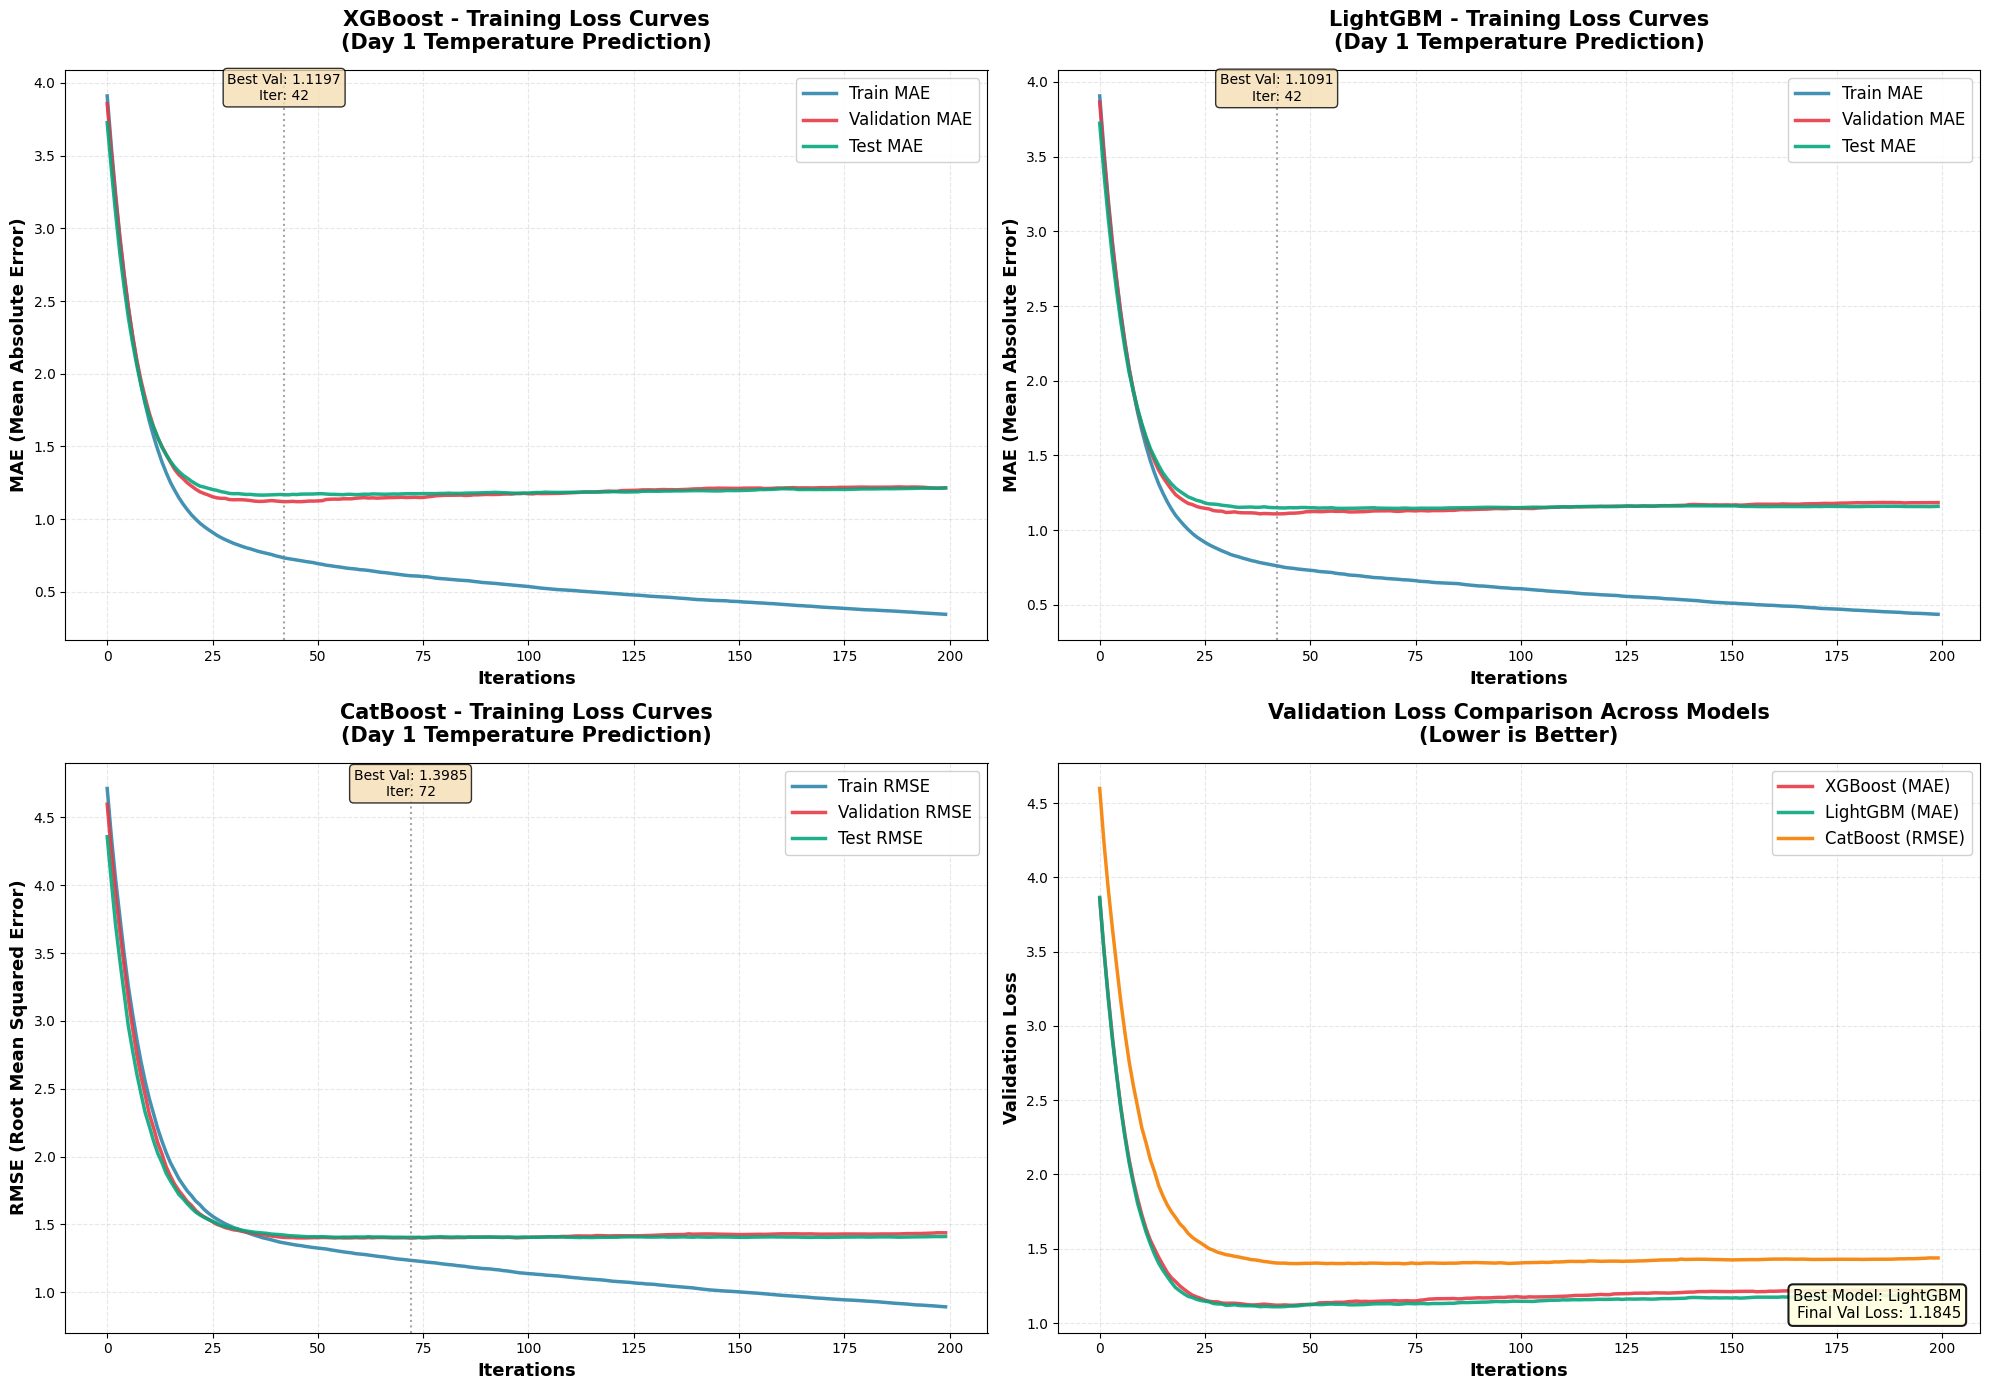


📊 TRAINING SUMMARY STATISTICS

   Model Metric  Best_Iter  Best_Val_Loss  Final_Train  Final_Val  Final_Test  Overfitting_Gap
 XGBoost    MAE         42       1.119660     0.344968   1.214874    1.214323         0.869906
LightGBM    MAE         42       1.109056     0.437269   1.184493    1.159631         0.747224
CatBoost   RMSE         72       1.398503     0.892354   1.437986    1.410734         0.545632

✅ BOOSTING MODELS LOSS VISUALIZATION COMPLETED



In [105]:
# ==========================================
# 📊 VISUALIZE TRAINING LOSS - XGBOOST, LIGHTGBM, CATBOOST
# ==========================================

import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

print(f"\n{'='*100}")
print("📈 VISUALIZING TRAINING LOSS CURVES FOR BOOSTING MODELS")
print(f"{'='*100}\n")

# Create figures directory
figures_dir = Path('../results/figures')
figures_dir.mkdir(parents=True, exist_ok=True)

# ==========================================
# 1️⃣ RETRAIN MODELS WITH EVALUATION TRACKING
# ==========================================

models_for_loss_viz = {
    'XGBoost': {
        'model': XGBRegressor(
            n_estimators=200,
            max_depth=5,
            learning_rate=0.1,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=42,
            n_jobs=-1,
            verbosity=0,
            eval_metric='mae'
        ),
        'needs_scaling': False
    },
    'LightGBM': {
        'model': LGBMRegressor(
            n_estimators=200,
            max_depth=5,
            learning_rate=0.1,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=42,
            n_jobs=-1,
            verbose=-1
        ),
        'needs_scaling': False
    },
    'CatBoost': {
        'model': CatBoostRegressor(
            iterations=200,
            depth=6,
            learning_rate=0.1,
            loss_function='RMSE',
            random_seed=42,
            verbose=False
        ),
        'needs_scaling': False
    }
}

# Container for loss histories
loss_histories = {}

target_col = 'y_temp_1'  # Day 1 prediction


# ==========================================
# XGBoost
# ==========================================

xgb_model = models_for_loss_viz['XGBoost']['model']
xgb_model.fit(
    X_train, 
    y_train[target_col],
    eval_set=[
        (X_train, y_train[target_col]),
        (X_val, y_val[target_col]),
        (X_test, y_test[target_col])
    ],
    verbose=False
)

# Extract loss history
evals = xgb_model.evals_result()
loss_histories['XGBoost'] = {
    'iterations': list(range(len(evals['validation_0']['mae']))),
    'train_loss': evals['validation_0']['mae'],
    'val_loss': evals['validation_1']['mae'],
    'test_loss': evals['validation_2']['mae']
}

# ==========================================
# LightGBM
# ==========================================

lgbm_model = models_for_loss_viz['LightGBM']['model']
lgbm_model.fit(
    X_train,
    y_train[target_col],
    eval_set=[
        (X_train, y_train[target_col]),
        (X_val, y_val[target_col]),
        (X_test, y_test[target_col])
    ],
    eval_metric='mae',
    callbacks=[
        # Suppress verbose output but keep evaluation
    ]
)

# Extract loss history
evals = lgbm_model.evals_result_
loss_histories['LightGBM'] = {
    'iterations': list(range(len(evals['training']['l1']))),
    'train_loss': evals['training']['l1'],
    'val_loss': evals['valid_1']['l1'],
    'test_loss': evals['valid_2']['l1']
}


# ==========================================
# CatBoost
# ==========================================


catboost_model = models_for_loss_viz['CatBoost']['model']
catboost_model.fit(
    X_train,
    y_train[target_col],
    eval_set=[
        (X_train, y_train[target_col]),
        (X_val, y_val[target_col]),
        (X_test, y_test[target_col])
    ],
    verbose=False
)

# Extract loss history from CatBoost
evals = catboost_model.evals_result_

# CatBoost uses 'learn' for training set
loss_histories['CatBoost'] = {
    'iterations': list(range(len(evals['learn']['RMSE']))),
    'train_loss': evals['learn']['RMSE'],
    'val_loss': evals['validation_1']['RMSE'],
    'test_loss': evals['validation_2']['RMSE']
}


# ==========================================
# 2️⃣ CREATE COMPREHENSIVE VISUALIZATION
# ==========================================

fig, axes = plt.subplots(2, 2, figsize=(20, 14))

# Color schemes
colors = {
    'train': '#2E86AB',
    'val': '#E63946',
    'test': '#06A77D'
}

# ==========================================
# PLOT 1: XGBoost
# ==========================================
ax1 = axes[0, 0]
history = loss_histories['XGBoost']

ax1.plot(history['iterations'], history['train_loss'], 
         label='Train MAE', color=colors['train'], linewidth=2.5, alpha=0.9)
ax1.plot(history['iterations'], history['val_loss'], 
         label='Validation MAE', color=colors['val'], linewidth=2.5, alpha=0.9)
ax1.plot(history['iterations'], history['test_loss'], 
         label='Test MAE', color=colors['test'], linewidth=2.5, alpha=0.9)

ax1.set_xlabel('Iterations', fontsize=13, fontweight='bold')
ax1.set_ylabel('MAE (Mean Absolute Error)', fontsize=13, fontweight='bold')
ax1.set_title('XGBoost - Training Loss Curves\n(Day 1 Temperature Prediction)', 
              fontsize=15, fontweight='bold', pad=15)
ax1.legend(fontsize=12, loc='upper right', framealpha=0.9)
ax1.grid(True, alpha=0.3, linestyle='--', linewidth=0.8)

# Add min loss annotation
min_val_idx = np.argmin(history['val_loss'])
ax1.axvline(x=min_val_idx, color='gray', linestyle=':', linewidth=1.5, alpha=0.7)
ax1.text(min_val_idx, ax1.get_ylim()[1]*0.95, 
         f'Best Val: {history["val_loss"][min_val_idx]:.4f}\nIter: {min_val_idx}',
         ha='center', fontsize=10,
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

# ==========================================
# PLOT 2: LightGBM
# ==========================================
ax2 = axes[0, 1]
history = loss_histories['LightGBM']

ax2.plot(history['iterations'], history['train_loss'], 
         label='Train MAE', color=colors['train'], linewidth=2.5, alpha=0.9)
ax2.plot(history['iterations'], history['val_loss'], 
         label='Validation MAE', color=colors['val'], linewidth=2.5, alpha=0.9)
ax2.plot(history['iterations'], history['test_loss'], 
         label='Test MAE', color=colors['test'], linewidth=2.5, alpha=0.9)

ax2.set_xlabel('Iterations', fontsize=13, fontweight='bold')
ax2.set_ylabel('MAE (Mean Absolute Error)', fontsize=13, fontweight='bold')
ax2.set_title('LightGBM - Training Loss Curves\n(Day 1 Temperature Prediction)', 
              fontsize=15, fontweight='bold', pad=15)
ax2.legend(fontsize=12, loc='upper right', framealpha=0.9)
ax2.grid(True, alpha=0.3, linestyle='--', linewidth=0.8)

min_val_idx = np.argmin(history['val_loss'])
ax2.axvline(x=min_val_idx, color='gray', linestyle=':', linewidth=1.5, alpha=0.7)
ax2.text(min_val_idx, ax2.get_ylim()[1]*0.95,
         f'Best Val: {history["val_loss"][min_val_idx]:.4f}\nIter: {min_val_idx}',
         ha='center', fontsize=10,
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

# ==========================================
# PLOT 3: CatBoost
# ==========================================
ax3 = axes[1, 0]
history = loss_histories['CatBoost']

ax3.plot(history['iterations'], history['train_loss'], 
         label='Train RMSE', color=colors['train'], linewidth=2.5, alpha=0.9)
ax3.plot(history['iterations'], history['val_loss'], 
         label='Validation RMSE', color=colors['val'], linewidth=2.5, alpha=0.9)
ax3.plot(history['iterations'], history['test_loss'], 
         label='Test RMSE', color=colors['test'], linewidth=2.5, alpha=0.9)

ax3.set_xlabel('Iterations', fontsize=13, fontweight='bold')
ax3.set_ylabel('RMSE (Root Mean Squared Error)', fontsize=13, fontweight='bold')
ax3.set_title('CatBoost - Training Loss Curves\n(Day 1 Temperature Prediction)', 
              fontsize=15, fontweight='bold', pad=15)
ax3.legend(fontsize=12, loc='upper right', framealpha=0.9)
ax3.grid(True, alpha=0.3, linestyle='--', linewidth=0.8)

min_val_idx = np.argmin(history['val_loss'])
ax3.axvline(x=min_val_idx, color='gray', linestyle=':', linewidth=1.5, alpha=0.7)
ax3.text(min_val_idx, ax3.get_ylim()[1]*0.95,
         f'Best Val: {history["val_loss"][min_val_idx]:.4f}\nIter: {min_val_idx}',
         ha='center', fontsize=10,
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

# ==========================================
# PLOT 4: COMPARATIVE VALIDATION LOSS
# ==========================================
ax4 = axes[1, 1]

ax4.plot(loss_histories['XGBoost']['iterations'], 
         loss_histories['XGBoost']['val_loss'],
         label='XGBoost (MAE)', color='#E63946', linewidth=2.5, alpha=0.9)

ax4.plot(loss_histories['LightGBM']['iterations'], 
         loss_histories['LightGBM']['val_loss'],
         label='LightGBM (MAE)', color='#06A77D', linewidth=2.5, alpha=0.9)

# Normalize CatBoost RMSE for comparison
catboost_val_normalized = np.array(loss_histories['CatBoost']['val_loss'])
ax4.plot(loss_histories['CatBoost']['iterations'], 
         catboost_val_normalized,
         label='CatBoost (RMSE)', color='#F77F00', linewidth=2.5, alpha=0.9)

ax4.set_xlabel('Iterations', fontsize=13, fontweight='bold')
ax4.set_ylabel('Validation Loss', fontsize=13, fontweight='bold')
ax4.set_title('Validation Loss Comparison Across Models\n(Lower is Better)', 
              fontsize=15, fontweight='bold', pad=15)
ax4.legend(fontsize=12, loc='upper right', framealpha=0.9)
ax4.grid(True, alpha=0.3, linestyle='--', linewidth=0.8)

# Add performance summary
final_losses = {
    'XGBoost': loss_histories['XGBoost']['val_loss'][-1],
    'LightGBM': loss_histories['LightGBM']['val_loss'][-1],
    'CatBoost': loss_histories['CatBoost']['val_loss'][-1]
}

best_model = min(final_losses, key=final_losses.get)
summary_text = f'Best Model: {best_model}\nFinal Val Loss: {final_losses[best_model]:.4f}'

ax4.text(0.98, 0.02, summary_text,
         transform=ax4.transAxes,
         fontsize=11,
         verticalalignment='bottom',
         horizontalalignment='right',
         bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.9, 
                   edgecolor='black', linewidth=1.5))

# ==========================================
# FINALIZE AND SAVE
# ==========================================

plt.tight_layout()

save_path = figures_dir / 'boosting_models_training_loss.png'
plt.savefig(str(save_path), dpi=150, bbox_inches='tight', facecolor='white')

print(f"✅ Loss curves visualization saved: {save_path}")

plt.show()

# ==========================================
# 3️⃣ PRINT SUMMARY STATISTICS
# ==========================================

print(f"\n{'='*100}")
print("📊 TRAINING SUMMARY STATISTICS")
print(f"{'='*100}\n")

summary_data = []
for model_name, history in loss_histories.items():
    metric_name = 'RMSE' if model_name == 'CatBoost' else 'MAE'
    
    min_train_loss = min(history['train_loss'])
    min_val_loss = min(history['val_loss'])
    min_test_loss = min(history['test_loss'])
    
    final_train_loss = history['train_loss'][-1]
    final_val_loss = history['val_loss'][-1]
    final_test_loss = history['test_loss'][-1]
    
    best_iter = np.argmin(history['val_loss'])
    
    summary_data.append({
        'Model': model_name,
        'Metric': metric_name,
        'Best_Iter': best_iter,
        'Best_Val_Loss': min_val_loss,
        'Final_Train': final_train_loss,
        'Final_Val': final_val_loss,
        'Final_Test': final_test_loss,
        'Overfitting_Gap': final_val_loss - final_train_loss
    })

summary_df = pd.DataFrame(summary_data)
print(summary_df.to_string(index=False))

print(f"\n{'='*100}")
print("✅ BOOSTING MODELS LOSS VISUALIZATION COMPLETED")
print(f"{'='*100}\n")

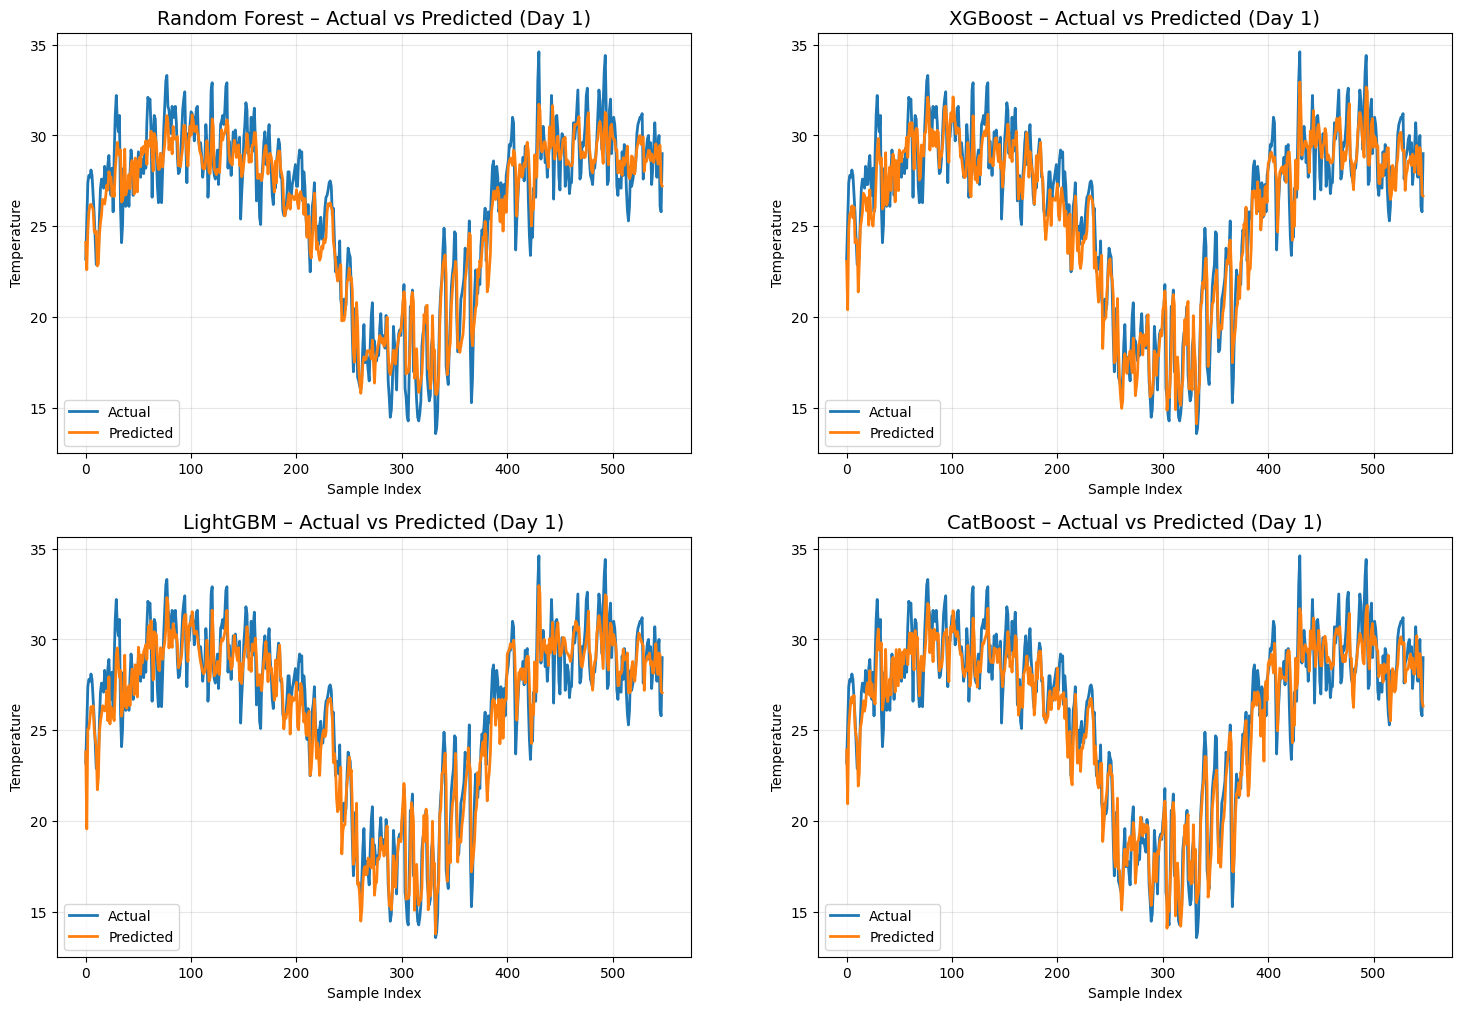

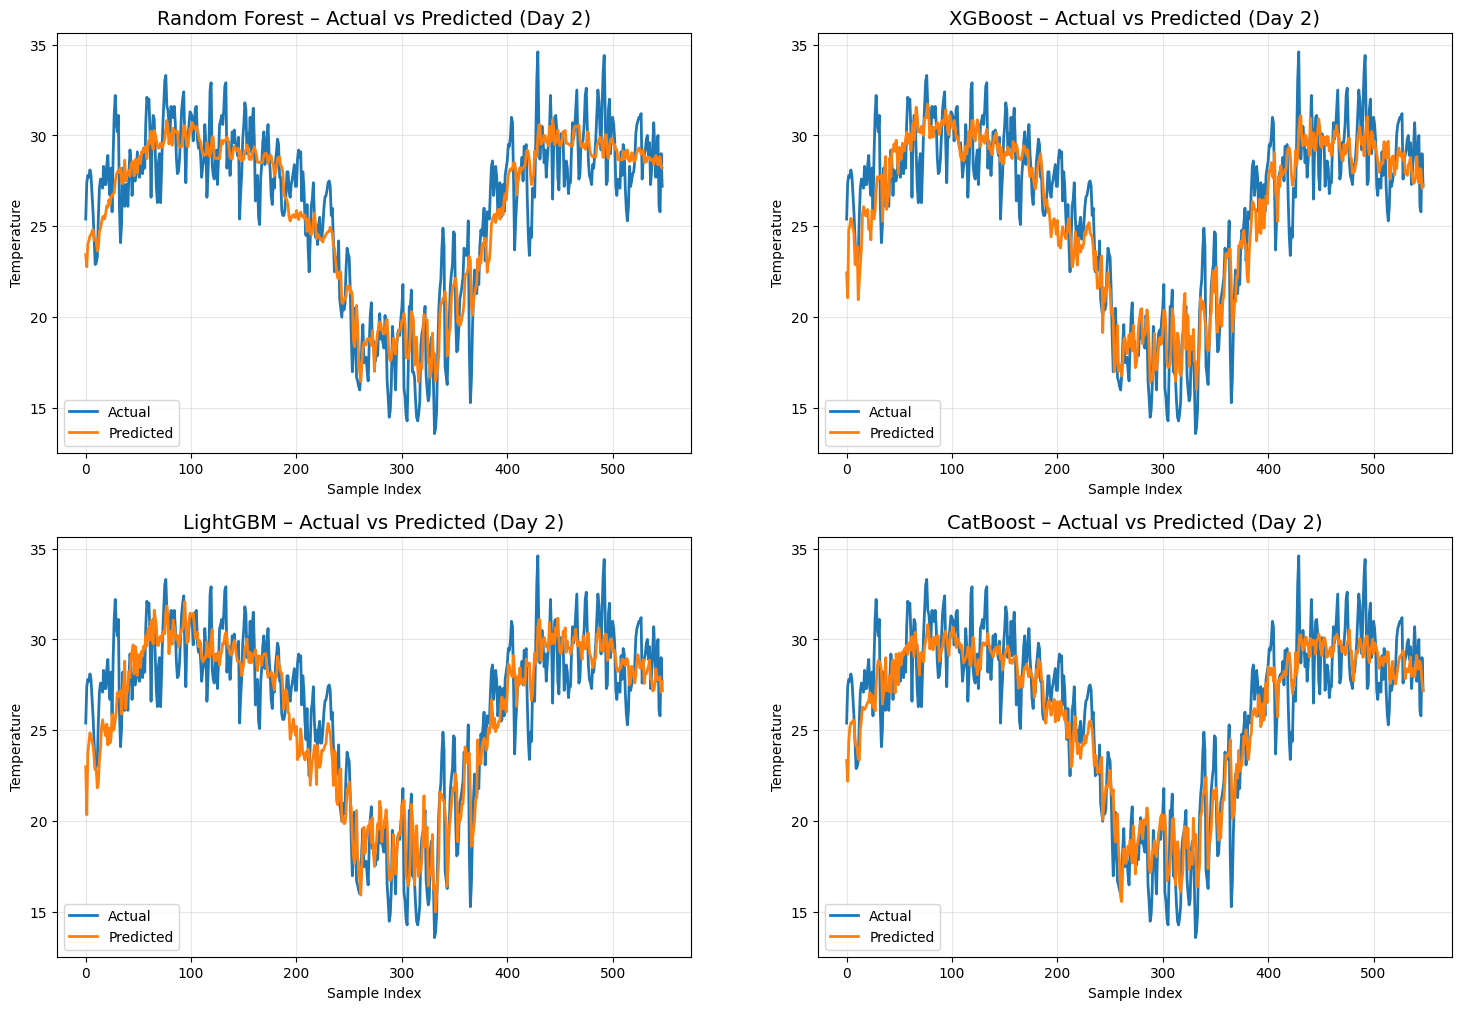

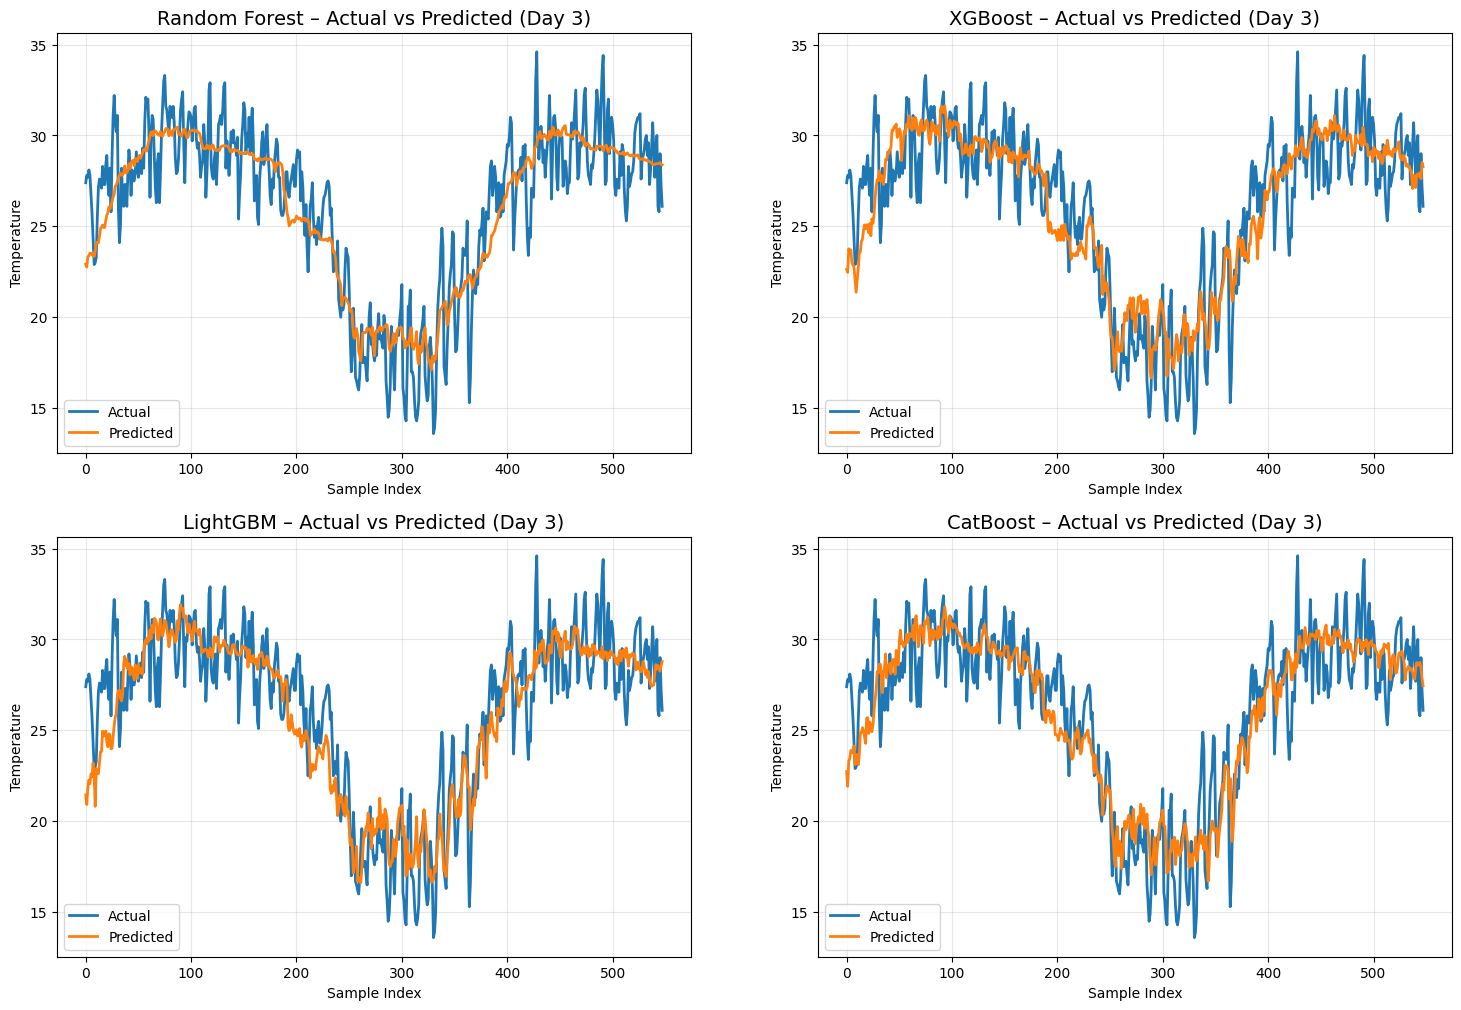

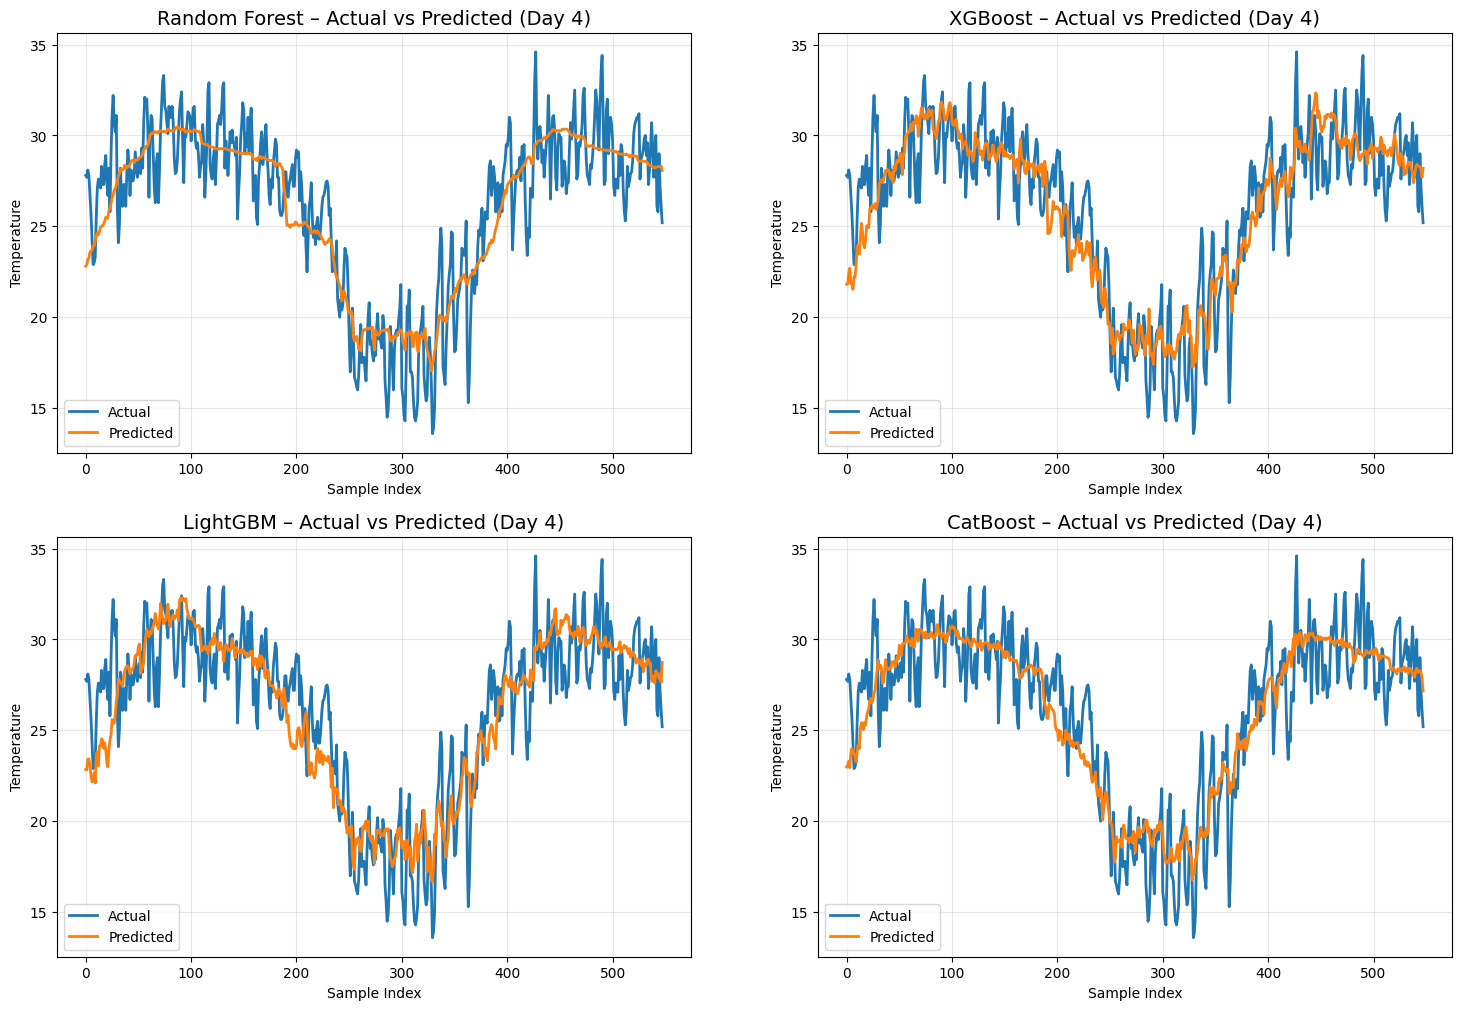

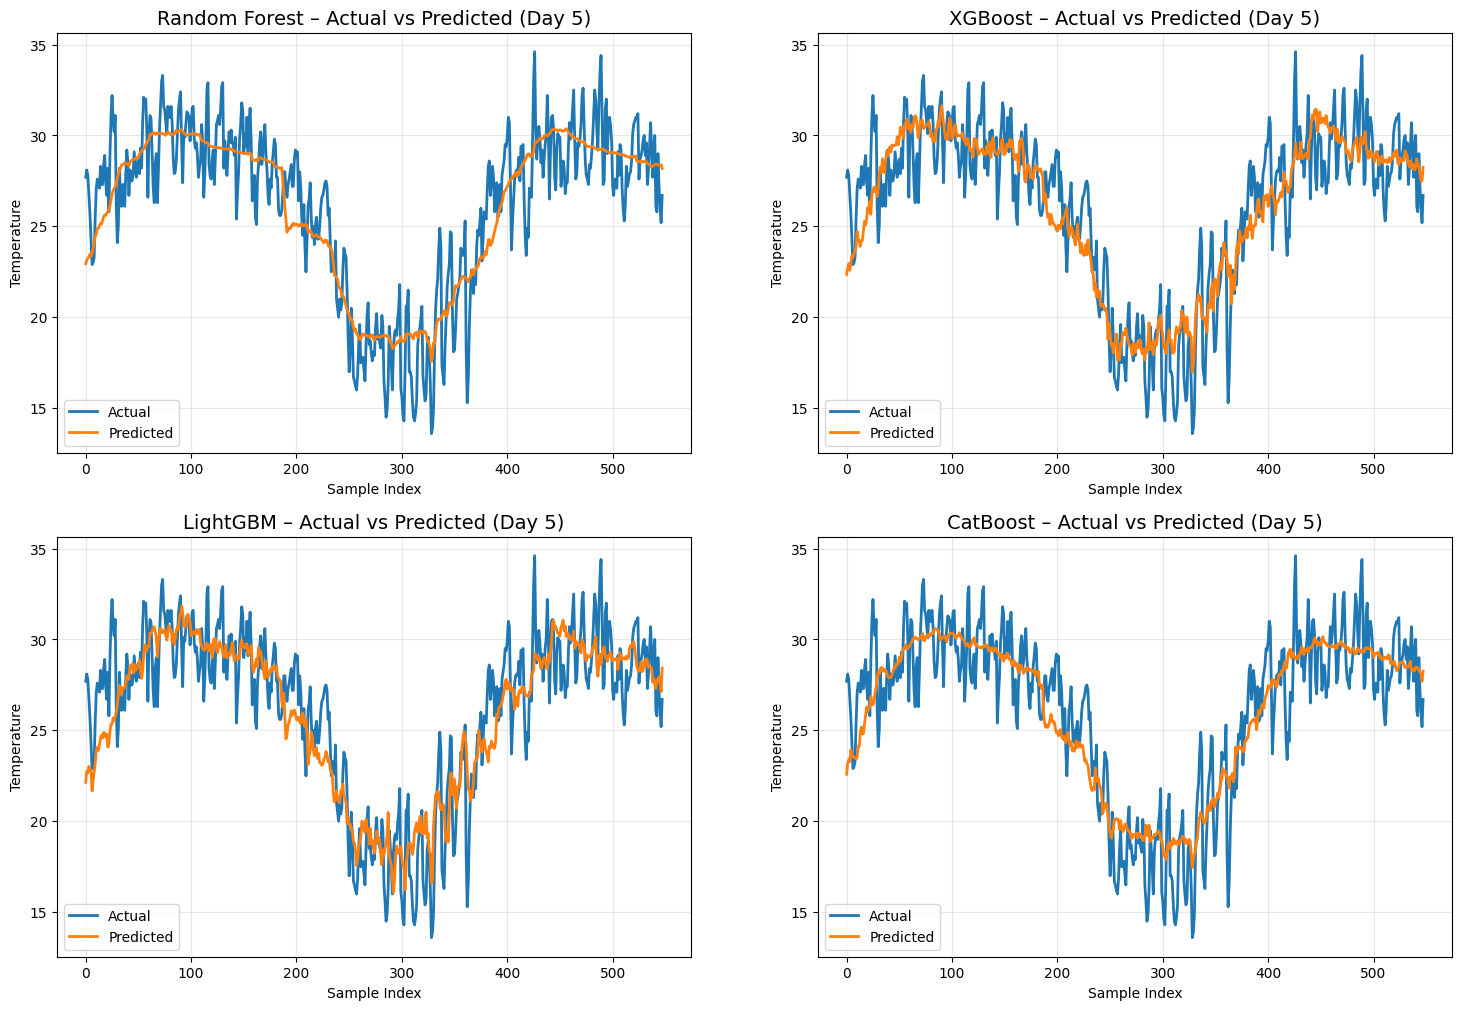

█████████████████████████████████ 100% | 2.67/2.67 MB [00:04<00:00,  1.73s/MB]: 



In [ ]:
# ==========================================
# 📊 VISUALIZE 4 MODELS - DAY 1 PREDICTION
# ==========================================
import matplotlib.pyplot as plt

models_to_plot = ["Random Forest", "XGBoost", "LightGBM", "CatBoost"]
days = [1,2,3,4,5]
sample_range = (0, 1000)  # You can change the number of samples to display

for day in days:
    plt.figure(figsize=(18, 12))
    for idx, model_name in enumerate(models_to_plot, 1):
        target_col = f"y_temp_{day}"
        results = all_model_results[model_name][target_col]

        y_test_true = y_test[target_col].values[sample_range[0]:sample_range[1]]
        y_test_pred = results['test_pred'][sample_range[0]:sample_range[1]]

        plt.subplot(2, 2, idx)
        plt.plot(y_test_true, label='Actual', linewidth=2)
        plt.plot(y_test_pred, label='Predicted', linewidth=2)
        plt.title(f"{model_name} – Actual vs Predicted (Day {day})", fontsize=14)
        plt.xlabel("Sample Index")
        plt.ylabel("Temperature")
        plt.grid(True, alpha=0.3)
        plt.legend()
    plt.show()





📊 CREATING BEST MODEL COMPARISON VISUALIZATION (t+1 & t+5)

🏆 Best Model: CatBoost

✅ Visualization saved: ..\results\figures\best_model_horizon_comparison_CatBoost.png

📈 Summary:
   Horizon t+1 - MAE: 1.119°C | R²: 0.909
   Horizon t+5 - MAE: 1.703°C | R²: 0.795
   Degradation: +52.1% MAE | -0.115 R²

✅ Visualization saved: ..\results\figures\best_model_horizon_comparison_CatBoost.png

📈 Summary:
   Horizon t+1 - MAE: 1.119°C | R²: 0.909
   Horizon t+5 - MAE: 1.703°C | R²: 0.795
   Degradation: +52.1% MAE | -0.115 R²


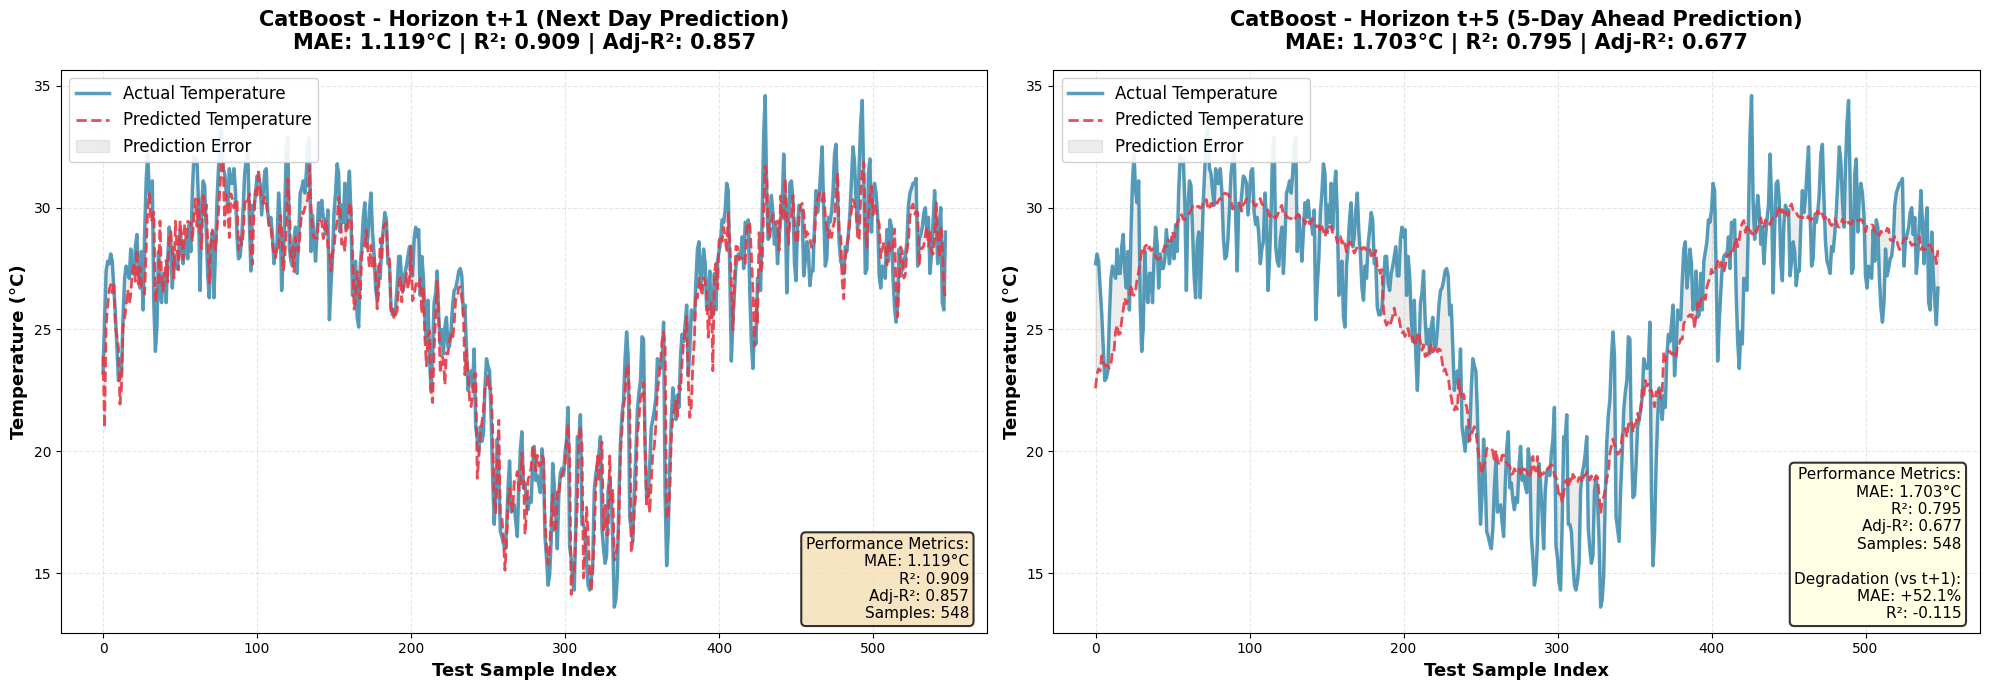

✅ Scatter plot saved: ..\results\figures\best_model_scatter_CatBoost.png


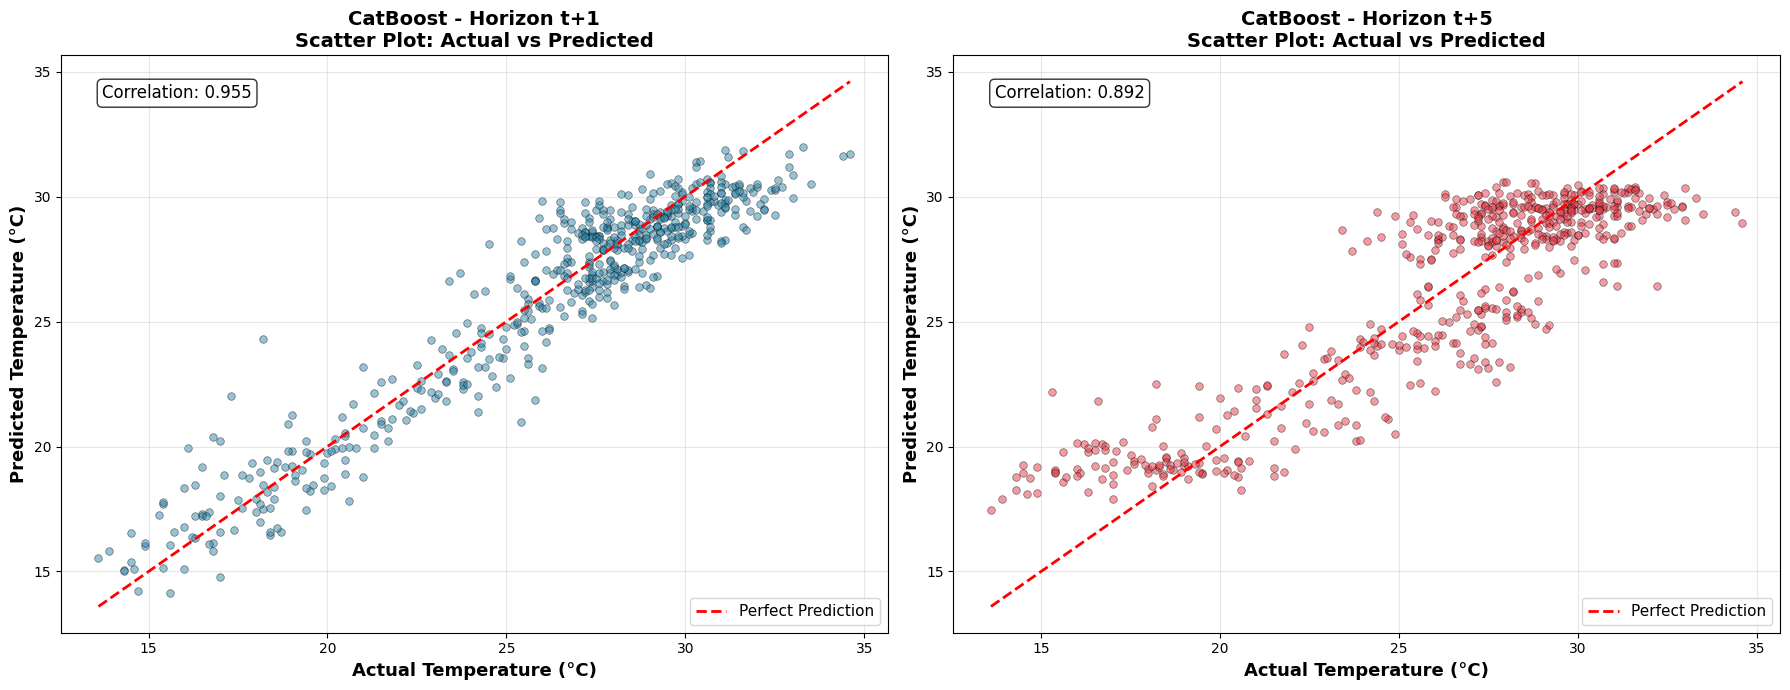


✅ BEST MODEL HORIZON COMPARISON COMPLETED



In [ ]:
# ==========================================
# 📊 VISUALIZATION: BEST MODEL - ACTUAL VS PREDICTED (HORIZON t+1 & t+5)
# ==========================================

import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

print(f"\n{'='*100}")
print("📊 CREATING BEST MODEL COMPARISON VISUALIZATION (t+1 & t+5)")
print(f"{'='*100}\n")

# Create figures directory
figures_dir = Path('../results/figures')
figures_dir.mkdir(parents=True, exist_ok=True)

# Identify Best Model (from comparison_df or model_avg)
if 'model_avg' in globals():
    best_model_name = model_avg.index[0]  # Model with lowest Test_MAE
elif 'comparison_df' in globals():
    best_model_name = comparison_df.iloc[0]['Model']
else:
    best_model_name = 'Random Forest'  # Fallback

print(f"🏆 Best Model: {best_model_name}")

# Get predictions from all_model_results
model_results = all_model_results[best_model_name]

# Target columns
target_day1 = 'y_temp_1'  # Horizon t+1
target_day5 = 'y_temp_5'  # Horizon t+5

# Get actual values
y_test_day1 = y_test[target_day1].values
y_test_day5 = y_test[target_day5].values

# Get predictions
y_pred_day1 = model_results[target_day1]['test_pred']
y_pred_day5 = model_results[target_day5]['test_pred']

# Get metrics
mae_day1 = model_results[target_day1]['mae_test']
r2_day1 = model_results[target_day1]['r2_test']
adj_r2_day1 = model_results[target_day1]['adj_r2_test']

mae_day5 = model_results[target_day5]['mae_test']
r2_day5 = model_results[target_day5]['r2_test']
adj_r2_day5 = model_results[target_day5]['adj_r2_test']

# ==========================================
# CREATE FIGURE WITH 2 SUBPLOTS
# ==========================================

fig, axes = plt.subplots(1, 2, figsize=(20, 7))

# Sample range for visualization (show all test data)
sample_range = slice(0, len(y_test_day1))
x_axis = np.arange(len(y_test_day1[sample_range]))

# ==========================================
# SUBPLOT 1: HORIZON t+1 (Day 1)
# ==========================================

ax1 = axes[0]

ax1.plot(x_axis, y_test_day1[sample_range], 
         label='Actual Temperature', 
         color='#2E86AB', 
         linewidth=2.5, 
         alpha=0.8)

ax1.plot(x_axis, y_pred_day1[sample_range], 
         label='Predicted Temperature', 
         color='#E63946', 
         linewidth=2, 
         linestyle='--', 
         alpha=0.9)

# Fill between for error visualization
ax1.fill_between(x_axis, 
                  y_test_day1[sample_range], 
                  y_pred_day1[sample_range], 
                  alpha=0.15, 
                  color='gray',
                  label='Prediction Error')

# Styling
ax1.set_title(f'{best_model_name} - Horizon t+1 (Next Day Prediction)\n'
              f'MAE: {mae_day1:.3f}°C | R²: {r2_day1:.3f} | Adj-R²: {adj_r2_day1:.3f}', 
              fontsize=15, 
              fontweight='bold',
              pad=15)

ax1.set_xlabel('Test Sample Index', fontsize=13, fontweight='bold')
ax1.set_ylabel('Temperature (°C)', fontsize=13, fontweight='bold')
ax1.legend(fontsize=12, loc='upper left', framealpha=0.9)
ax1.grid(True, alpha=0.3, linestyle='--', linewidth=0.8)

# Add statistics box
stats_text_day1 = (
    f'Performance Metrics:\n'
    f'MAE: {mae_day1:.3f}°C\n'
    f'R²: {r2_day1:.3f}\n'
    f'Adj-R²: {adj_r2_day1:.3f}\n'
    f'Samples: {len(x_axis)}'
)

ax1.text(0.98, 0.02, stats_text_day1,
         transform=ax1.transAxes,
         fontsize=11,
         verticalalignment='bottom',
         horizontalalignment='right',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8, edgecolor='black', linewidth=1.5))

# ==========================================
# SUBPLOT 2: HORIZON t+5 (Day 5)
# ==========================================

ax2 = axes[1]

ax2.plot(x_axis, y_test_day5[sample_range], 
         label='Actual Temperature', 
         color='#2E86AB', 
         linewidth=2.5, 
         alpha=0.8)

ax2.plot(x_axis, y_pred_day5[sample_range], 
         label='Predicted Temperature', 
         color='#E63946', 
         linewidth=2, 
         linestyle='--', 
         alpha=0.9)

# Fill between for error visualization
ax2.fill_between(x_axis, 
                  y_test_day5[sample_range], 
                  y_pred_day5[sample_range], 
                  alpha=0.15, 
                  color='gray',
                  label='Prediction Error')

# Styling
ax2.set_title(f'{best_model_name} - Horizon t+5 (5-Day Ahead Prediction)\n'
              f'MAE: {mae_day5:.3f}°C | R²: {r2_day5:.3f} | Adj-R²: {adj_r2_day5:.3f}', 
              fontsize=15, 
              fontweight='bold',
              pad=15)

ax2.set_xlabel('Test Sample Index', fontsize=13, fontweight='bold')
ax2.set_ylabel('Temperature (°C)', fontsize=13, fontweight='bold')
ax2.legend(fontsize=12, loc='upper left', framealpha=0.9)
ax2.grid(True, alpha=0.3, linestyle='--', linewidth=0.8)

# Add statistics box
degradation_pct = ((mae_day5 - mae_day1) / mae_day1) * 100
r2_degradation = r2_day1 - r2_day5

stats_text_day5 = (
    f'Performance Metrics:\n'
    f'MAE: {mae_day5:.3f}°C\n'
    f'R²: {r2_day5:.3f}\n'
    f'Adj-R²: {adj_r2_day5:.3f}\n'
    f'Samples: {len(x_axis)}\n'
    f'\n'
    f'Degradation (vs t+1):\n'
    f'MAE: +{degradation_pct:.1f}%\n'
    f'R²: -{r2_degradation:.3f}'
)

ax2.text(0.98, 0.02, stats_text_day5,
         transform=ax2.transAxes,
         fontsize=11,
         verticalalignment='bottom',
         horizontalalignment='right',
         bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8, edgecolor='black', linewidth=1.5))

# ==========================================
# FINALIZE AND SAVE
# ==========================================

plt.tight_layout()

save_path = figures_dir / f'best_model_horizon_comparison_{best_model_name.replace(" ", "_")}.png'
plt.savefig(str(save_path), dpi=150, bbox_inches='tight', facecolor='white')

print(f"\n✅ Visualization saved: {save_path}")
print(f"\n📈 Summary:")
print(f"   Horizon t+1 - MAE: {mae_day1:.3f}°C | R²: {r2_day1:.3f}")
print(f"   Horizon t+5 - MAE: {mae_day5:.3f}°C | R²: {r2_day5:.3f}")
print(f"   Degradation: +{degradation_pct:.1f}% MAE | -{r2_degradation:.3f} R²")

plt.show()

# ==========================================
# 📊 OPTIONAL: CREATE SCATTER PLOT VERSION
# ==========================================

fig2, axes2 = plt.subplots(1, 2, figsize=(18, 7))

# Scatter plot for t+1
ax1 = axes2[0]
ax1.scatter(y_test_day1, y_pred_day1, alpha=0.5, s=30, color='#2E86AB', edgecolors='black', linewidth=0.5)

# Perfect prediction line
min_val = min(y_test_day1.min(), y_pred_day1.min())
max_val = max(y_test_day1.max(), y_pred_day1.max())
ax1.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect Prediction')

ax1.set_xlabel('Actual Temperature (°C)', fontsize=13, fontweight='bold')
ax1.set_ylabel('Predicted Temperature (°C)', fontsize=13, fontweight='bold')
ax1.set_title(f'{best_model_name} - Horizon t+1\nScatter Plot: Actual vs Predicted', 
              fontsize=14, fontweight='bold')
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)

# Add correlation coefficient
from scipy.stats import pearsonr
corr_day1, _ = pearsonr(y_test_day1, y_pred_day1)
ax1.text(0.05, 0.95, f'Correlation: {corr_day1:.3f}',
         transform=ax1.transAxes, fontsize=12,
         verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# Scatter plot for t+5
ax2 = axes2[1]
ax2.scatter(y_test_day5, y_pred_day5, alpha=0.5, s=30, color='#E63946', edgecolors='black', linewidth=0.5)

min_val = min(y_test_day5.min(), y_pred_day5.min())
max_val = max(y_test_day5.max(), y_pred_day5.max())
ax2.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect Prediction')

ax2.set_xlabel('Actual Temperature (°C)', fontsize=13, fontweight='bold')
ax2.set_ylabel('Predicted Temperature (°C)', fontsize=13, fontweight='bold')
ax2.set_title(f'{best_model_name} - Horizon t+5\nScatter Plot: Actual vs Predicted', 
              fontsize=14, fontweight='bold')
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.3)

corr_day5, _ = pearsonr(y_test_day5, y_pred_day5)
ax2.text(0.05, 0.95, f'Correlation: {corr_day5:.3f}',
         transform=ax2.transAxes, fontsize=12,
         verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()

save_path_scatter = figures_dir / f'best_model_scatter_{best_model_name.replace(" ", "_")}.png'
plt.savefig(str(save_path_scatter), dpi=150, bbox_inches='tight', facecolor='white')

print(f"✅ Scatter plot saved: {save_path_scatter}")

plt.show()

print(f"\n{'='*100}")
print("✅ BEST MODEL HORIZON COMPARISON COMPLETED")
print(f"{'='*100}\n")

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pathlib import Path

figures_dir = Path('../results/figures')
figures_dir.mkdir(parents=True, exist_ok=True)

# Extract metrics for all 5 days from direct prediction results
models_to_viz = ['Random Forest', 'Extra Trees', 'XGBoost', 'LightGBM', 'CatBoost', 
                 'Ridge (FS)', 'Bayesian Ridge (FS)', 'SVR (FS)']

day_metrics = {}

for model_name in models_to_viz:
    if model_name in all_model_results:
        day_metrics[model_name] = {
            'mae': [],
            'rmse': [],
            'r2': [],
            'mape': [],
            'gap_mae': []
        }
        
        for day_idx in range(1, 6):
            target_key = f'y_temp_{day_idx}'
            if target_key in all_model_results[model_name]:
                metrics = all_model_results[model_name][target_key]
                day_metrics[model_name]['mae'].append(metrics['mae_test'])
                day_metrics[model_name]['rmse'].append(metrics['rmse_test'])
                day_metrics[model_name]['r2'].append(metrics['r2_test'])
                day_metrics[model_name]['mape'].append(metrics['mape_test'])
                day_metrics[model_name]['gap_mae'].append(metrics['gap_mae_test'])

print(f"\n{'='*80}")
print("📊 DATA EXTRACTED FOR 5-DAY VISUALIZATIONS")
print(f"{'='*80}")
print(f"Number of models: {len(day_metrics)}")
print(f"Models: {list(day_metrics.keys())}")
if 'CatBoost' in day_metrics:
    print(f"\nSample - CatBoost MAE by day: {day_metrics['CatBoost']['mae']}")
    print(f"Sample - CatBoost R² by day: {day_metrics['CatBoost']['r2']}")
print(f"{'='*80}\n")


📊 DATA EXTRACTED FOR 5-DAY VISUALIZATIONS
Number of models: 5
Models: ['Random Forest', 'Extra Trees', 'XGBoost', 'LightGBM', 'CatBoost']

Sample - CatBoost MAE by day: [1.1192381412101455, 1.4614889601860699, 1.6663359332103873, 1.672636762280237, 1.7027267629981633]
Sample - CatBoost R² by day: [0.9090256270003578, 0.8423704880393197, 0.7976778185371489, 0.800607486472531, 0.794509460772391]



█████████████████████████████████ 100% | 2.87/2.87 MB [00:12<00:00,  4.45s/MB]: 



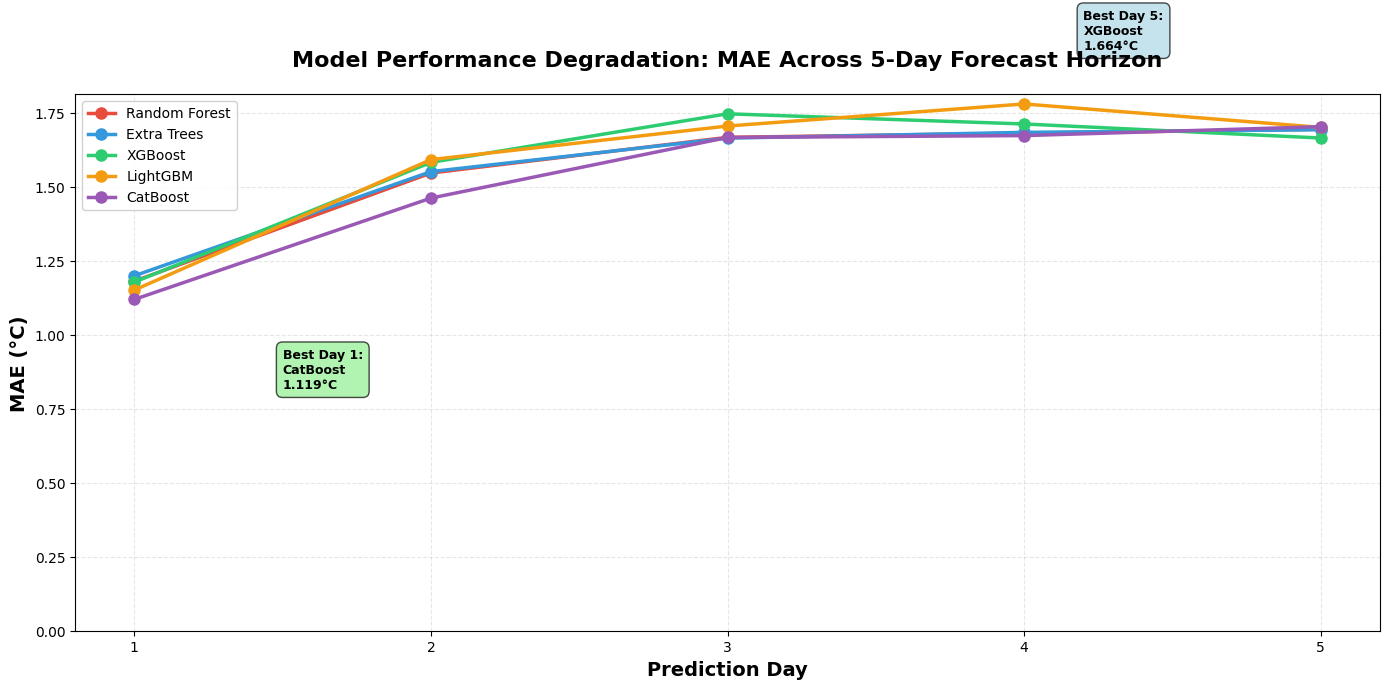

Visualization 1: MAE degradation chart created


In [ ]:
fig, ax = plt.subplots(figsize=(14, 7))

days = np.arange(1, 6)
colors_list = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12', '#9b59b6', '#1abc9c', '#e67e22', '#34495e']

for idx, (model_name, metrics) in enumerate(day_metrics.items()):
    ax.plot(days, metrics['mae'], marker='o', linewidth=2.5, 
            markersize=8, label=model_name, color=colors_list[idx % len(colors_list)])

ax.set_xlabel('Prediction Day', fontsize=14, fontweight='bold')
ax.set_ylabel('MAE (°C)', fontsize=14, fontweight='bold')
ax.set_title('Model Performance Degradation: MAE Across 5-Day Forecast Horizon', 
             fontsize=16, fontweight='bold', pad=20)
ax.set_xticks(days)
ax.grid(True, alpha=0.3, linestyle='--')
ax.legend(fontsize=10, loc='upper left', framealpha=0.9)
ax.set_ylim(bottom=0)

# Add annotations for best model on Day 1 and Day 5
best_day1_model = min(day_metrics.items(), key=lambda x: x[1]['mae'][0])
best_day5_model = min(day_metrics.items(), key=lambda x: x[1]['mae'][4])

ax.annotate(f"Best Day 1:\n{best_day1_model[0]}\n{best_day1_model[1]['mae'][0]:.3f}°C",
            xy=(1, best_day1_model[1]['mae'][0]), 
            xytext=(1.5, best_day1_model[1]['mae'][0] - 0.3),
            bbox=dict(boxstyle='round,pad=0.5', facecolor='lightgreen', alpha=0.7),
            fontsize=9, fontweight='bold')

ax.annotate(f"Best Day 5:\n{best_day5_model[0]}\n{best_day5_model[1]['mae'][4]:.3f}°C",
            xy=(5, best_day5_model[1]['mae'][4]), 
            xytext=(4.2, best_day5_model[1]['mae'][4] + 0.3),
            bbox=dict(boxstyle='round,pad=0.5', facecolor='lightblue', alpha=0.7),
            fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig(figures_dir / '5day_mae_degradation.png', dpi=300, bbox_inches='tight')
plt.show()

print(" MAE degradation chart created")

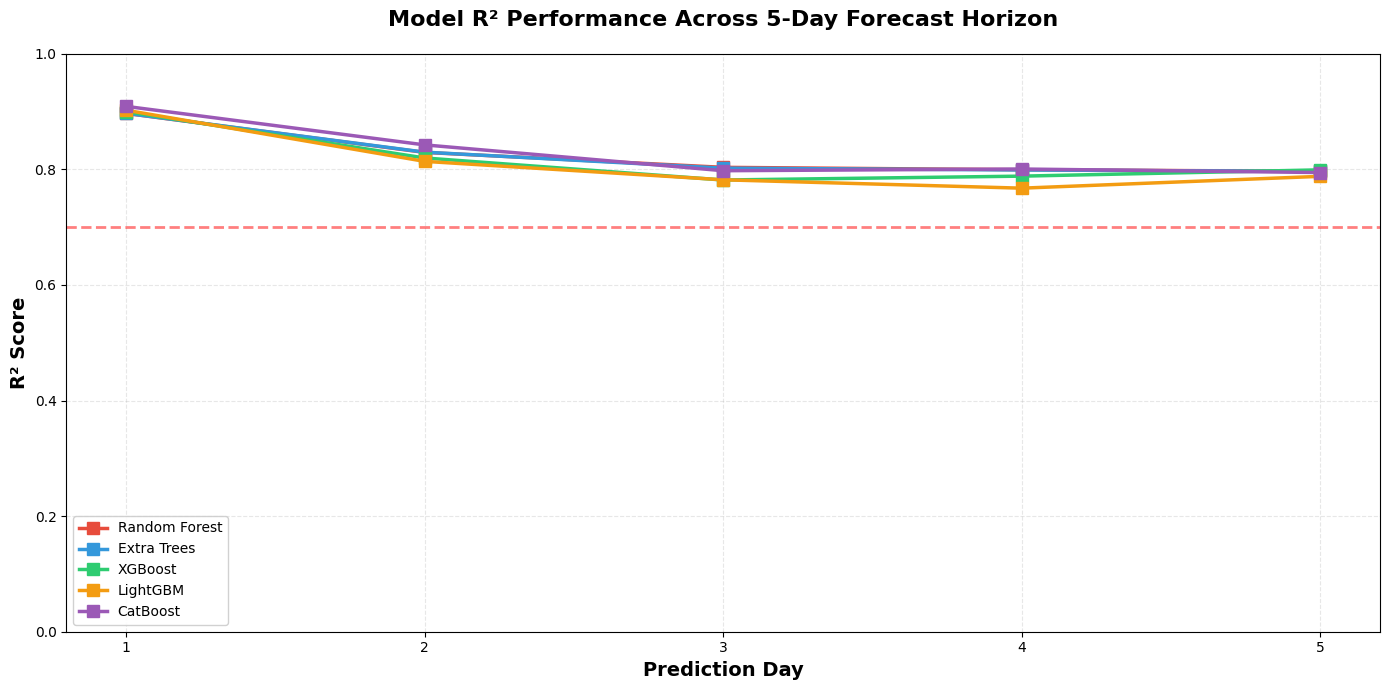

Visualization 2: R² degradation chart created


In [ ]:
fig, ax = plt.subplots(figsize=(14, 7))

for idx, (model_name, metrics) in enumerate(day_metrics.items()):
    ax.plot(days, metrics['r2'], marker='s', linewidth=2.5, 
            markersize=8, label=model_name, color=colors_list[idx % len(colors_list)])

ax.set_xlabel('Prediction Day', fontsize=14, fontweight='bold')
ax.set_ylabel('R² Score', fontsize=14, fontweight='bold')
ax.set_title('Model R² Performance Across 5-Day Forecast Horizon', 
             fontsize=16, fontweight='bold', pad=20)
ax.set_xticks(days)
ax.grid(True, alpha=0.3, linestyle='--')
ax.legend(fontsize=10, loc='lower left', framealpha=0.9)
ax.set_ylim([0, 1])

# Add horizontal line at R² = 0.7 (good threshold)
ax.axhline(y=0.7, color='red', linestyle='--', linewidth=2, alpha=0.5, label='R²=0.7 threshold')

plt.tight_layout()
plt.savefig(figures_dir / '5day_r2_degradation.png', dpi=300, bbox_inches='tight')
plt.show()

print(" R² degradation chart created")

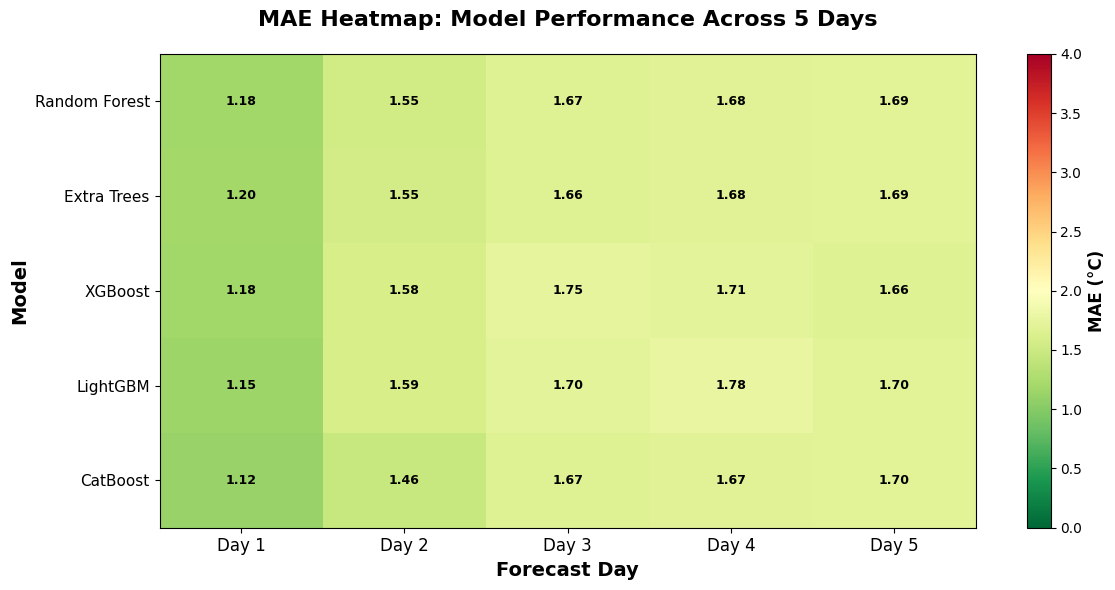

✅ Visualization 3: MAE heatmap created


In [ ]:
mae_heatmap_data = pd.DataFrame({
    model_name: metrics['mae'] 
    for model_name, metrics in day_metrics.items()
}, index=[f'Day {i+1}' for i in range(5)])

fig, ax = plt.subplots(figsize=(12, 6))
im = ax.imshow(mae_heatmap_data.T, cmap='RdYlGn_r', aspect='auto', vmin=0, vmax=4)

# Set ticks and labels
ax.set_xticks(np.arange(5))
ax.set_yticks(np.arange(len(day_metrics)))
ax.set_xticklabels([f'Day {i+1}' for i in range(5)], fontsize=12)
ax.set_yticklabels(mae_heatmap_data.columns, fontsize=11)

# Add colorbar
cbar = plt.colorbar(im, ax=ax)
cbar.set_label('MAE (°C)', fontsize=12, fontweight='bold')

# Add text annotations
for i in range(len(day_metrics)):
    for j in range(5):
        text = ax.text(j, i, f'{mae_heatmap_data.iloc[j, i]:.2f}',
                      ha="center", va="center", color="black", fontsize=9, fontweight='bold')

ax.set_title('MAE Heatmap: Model Performance Across 5 Days', 
             fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Forecast Day', fontsize=14, fontweight='bold')
ax.set_ylabel('Model', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig(figures_dir / '5day_mae_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ MAE heatmap created")

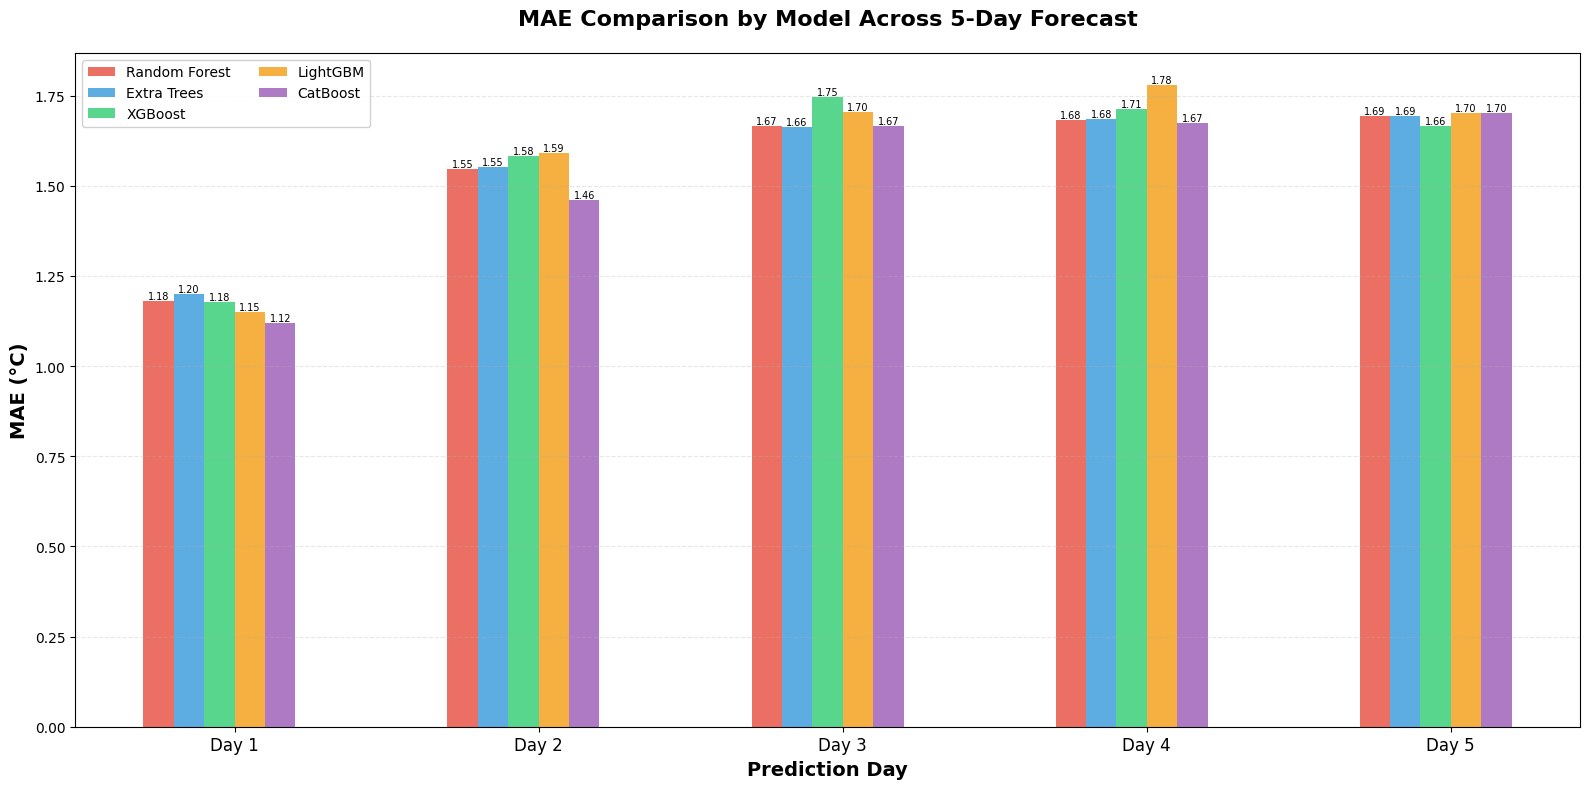

✅ Visualization 4: Grouped bar chart created


In [ ]:
fig, ax = plt.subplots(figsize=(16, 8))

x = np.arange(5)  # Days
width = 0.1  # Width of bars
models_list = list(day_metrics.keys())

for idx, model_name in enumerate(models_list):
    offset = (idx - len(models_list)/2) * width
    bars = ax.bar(x + offset, day_metrics[model_name]['mae'], width, 
                  label=model_name, color=colors_list[idx % len(colors_list)], alpha=0.8)
    
    # Add value labels on bars
    for bar in bars:
        height = bar.get_height()
        if height < 2:  # Only show labels for lower values to avoid clutter
            ax.text(bar.get_x() + bar.get_width()/2., height,
                   f'{height:.2f}', ha='center', va='bottom', fontsize=7, rotation=0)

ax.set_xlabel('Prediction Day', fontsize=14, fontweight='bold')
ax.set_ylabel('MAE (°C)', fontsize=14, fontweight='bold')
ax.set_title('MAE Comparison by Model Across 5-Day Forecast', 
             fontsize=16, fontweight='bold', pad=20)
ax.set_xticks(x)
ax.set_xticklabels([f'Day {i+1}' for i in range(5)], fontsize=12)
ax.legend(fontsize=10, loc='upper left', ncol=2, framealpha=0.9)
ax.grid(True, alpha=0.3, axis='y', linestyle='--')

plt.tight_layout()
plt.savefig(figures_dir / '5day_mae_grouped_bars.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Grouped bar chart created")

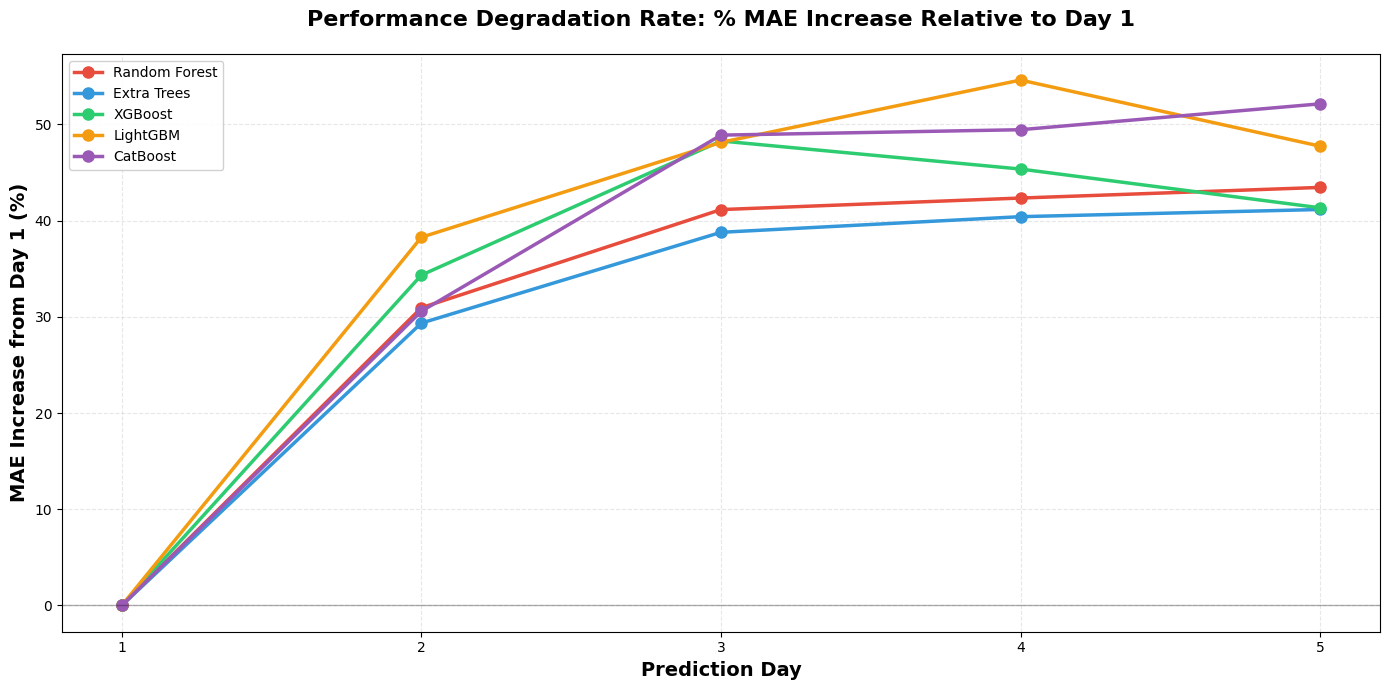

✅ Visualization 5: Degradation rate chart created


In [ ]:
fig, ax = plt.subplots(figsize=(14, 7))

for idx, (model_name, metrics) in enumerate(day_metrics.items()):
    day1_mae = metrics['mae'][0]
    degradation_pct = [(mae - day1_mae) / day1_mae * 100 for mae in metrics['mae']]
    ax.plot(days, degradation_pct, marker='o', linewidth=2.5, 
            markersize=8, label=model_name, color=colors_list[idx % len(colors_list)])

ax.set_xlabel('Prediction Day', fontsize=14, fontweight='bold')
ax.set_ylabel('MAE Increase from Day 1 (%)', fontsize=14, fontweight='bold')
ax.set_title('Performance Degradation Rate: % MAE Increase Relative to Day 1', 
             fontsize=16, fontweight='bold', pad=20)
ax.set_xticks(days)
ax.grid(True, alpha=0.3, linestyle='--')
ax.legend(fontsize=10, loc='upper left', framealpha=0.9)
ax.axhline(y=0, color='black', linestyle='-', linewidth=1, alpha=0.3)

plt.tight_layout()
plt.savefig(figures_dir / '5day_degradation_rate.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Degradation rate chart created")

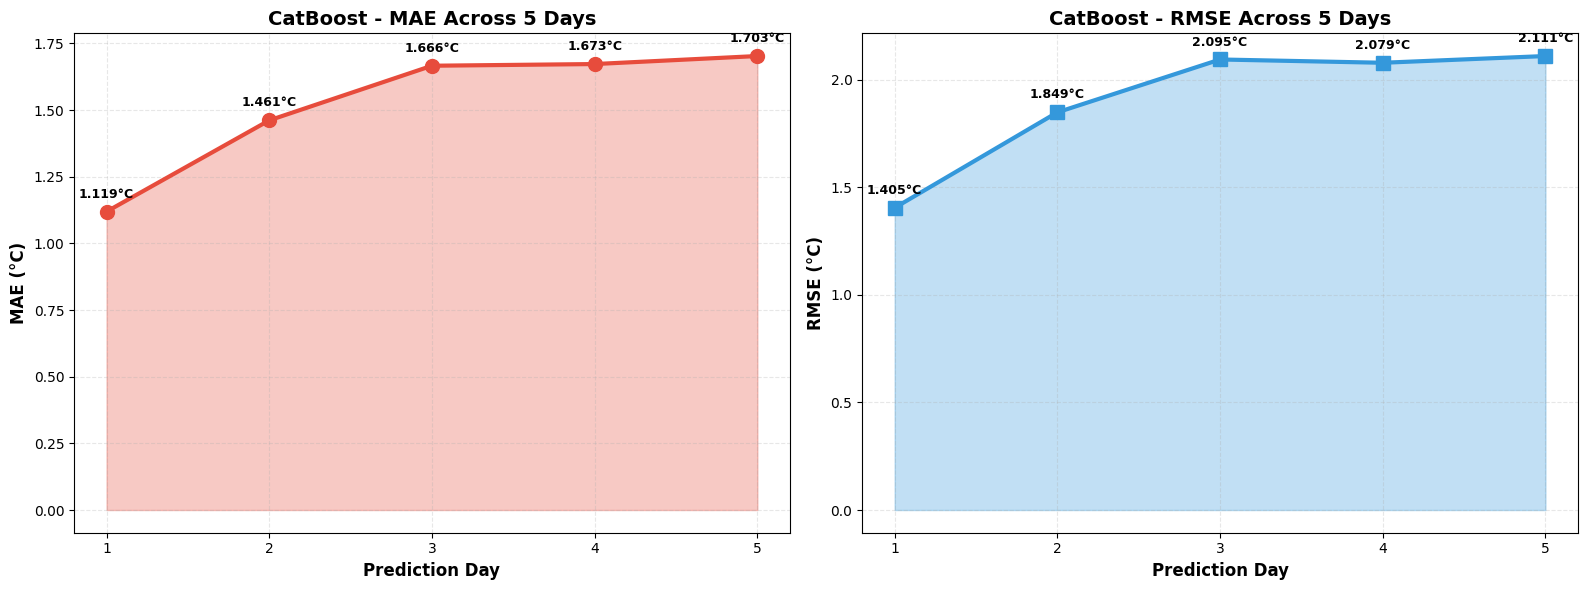

✅ Visualization 6: CatBoost MAE and RMSE charts created


In [ ]:
best_model = 'CatBoost'
if best_model in day_metrics:
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # MAE plot
    axes[0].plot(days, day_metrics[best_model]['mae'], marker='o', linewidth=3, 
                markersize=10, color='#e74c3c', label='MAE')
    axes[0].fill_between(days, 0, day_metrics[best_model]['mae'], alpha=0.3, color='#e74c3c')
    axes[0].set_xlabel('Prediction Day', fontsize=12, fontweight='bold')
    axes[0].set_ylabel('MAE (°C)', fontsize=12, fontweight='bold')
    axes[0].set_title(f'{best_model} - MAE Across 5 Days', fontsize=14, fontweight='bold')
    axes[0].grid(True, alpha=0.3, linestyle='--')
    axes[0].set_xticks(days)
    
    # Add values on points
    for i, (day, mae) in enumerate(zip(days, day_metrics[best_model]['mae'])):
        axes[0].annotate(f'{mae:.3f}°C', xy=(day, mae), 
                        xytext=(0, 10), textcoords='offset points',
                        ha='center', fontsize=9, fontweight='bold')
    
    # RMSE plot
    axes[1].plot(days, day_metrics[best_model]['rmse'], marker='s', linewidth=3, 
                markersize=10, color='#3498db', label='RMSE')
    axes[1].fill_between(days, 0, day_metrics[best_model]['rmse'], alpha=0.3, color='#3498db')
    axes[1].set_xlabel('Prediction Day', fontsize=12, fontweight='bold')
    axes[1].set_ylabel('RMSE (°C)', fontsize=12, fontweight='bold')
    axes[1].set_title(f'{best_model} - RMSE Across 5 Days', fontsize=14, fontweight='bold')
    axes[1].grid(True, alpha=0.3, linestyle='--')
    axes[1].set_xticks(days)
    
    # Add values on points
    for i, (day, rmse) in enumerate(zip(days, day_metrics[best_model]['rmse'])):
        axes[1].annotate(f'{rmse:.3f}°C', xy=(day, rmse), 
                        xytext=(0, 10), textcoords='offset points',
                        ha='center', fontsize=9, fontweight='bold')
    
    plt.tight_layout()
    plt.savefig(figures_dir / f'5day_{best_model}_mae_rmse.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print(f"✅ {best_model} MAE and RMSE charts created")
else:
    print(f"❌ Model {best_model} not found in results")


BEST MODEL BY EACH FORECAST DAY
  Day  Best Model MAE (°C) RMSE (°C)     R² MAPE (%)
Day 1    CatBoost   1.1192    1.4050 0.9090     4.48
Day 2    CatBoost   1.4615    1.8488 0.8424     6.00
Day 3 Extra Trees   1.6640    2.0716 0.8021     6.88
Day 4    CatBoost   1.6726    2.0792 0.8006     6.87
Day 5     XGBoost   1.6645    2.0866 0.7991     6.81


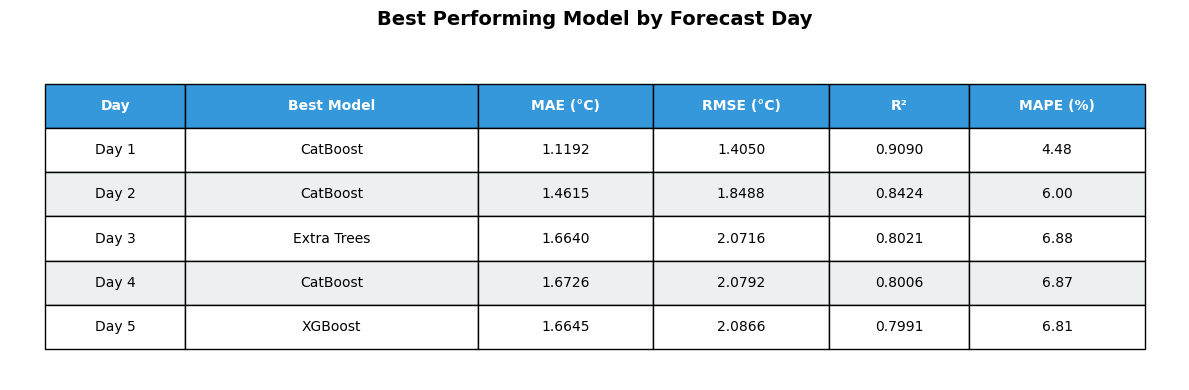


✅ Visualization 9: Best models by day table created


In [ ]:
summary_data_by_day = []

for day_idx in range(5):
    # Find best model for this day
    best_for_day = min(day_metrics.items(), key=lambda x: x[1]['mae'][day_idx])
    model_name = best_for_day[0]
    
    summary_data_by_day.append({
        'Day': f'Day {day_idx + 1}',
        'Best Model': model_name,
        'MAE (°C)': f"{best_for_day[1]['mae'][day_idx]:.4f}",
        'RMSE (°C)': f"{best_for_day[1]['rmse'][day_idx]:.4f}",
        'R²': f"{best_for_day[1]['r2'][day_idx]:.4f}",
        'MAPE (%)': f"{best_for_day[1]['mape'][day_idx]:.2f}"
    })

summary_df_by_day = pd.DataFrame(summary_data_by_day)

print("\n" + "="*80)
print("BEST MODEL BY EACH FORECAST DAY")
print("="*80)
print(summary_df_by_day.to_string(index=False))
print("="*80)

# Create visual table
fig, ax = plt.subplots(figsize=(12, 4))
ax.axis('tight')
ax.axis('off')

table = ax.table(cellText=summary_df_by_day.values, 
                colLabels=summary_df_by_day.columns,
                cellLoc='center', 
                loc='center',
                colWidths=[0.12, 0.25, 0.15, 0.15, 0.12, 0.15])

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 2.5)

# Style header
for i in range(len(summary_df_by_day.columns)):
    table[(0, i)].set_facecolor('#3498db')
    table[(0, i)].set_text_props(weight='bold', color='white')

# Alternate row colors
for i in range(1, len(summary_df_by_day) + 1):
    for j in range(len(summary_df_by_day.columns)):
        if i % 2 == 0:
            table[(i, j)].set_facecolor('#ecf0f1')
        else:
            table[(i, j)].set_facecolor('white')

plt.title('Best Performing Model by Forecast Day', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig(figures_dir / '5day_best_by_day_table.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✅  Best models by day table created")

# **7. Multi-output model predictions (5 Days Ahead)**

Train models to predict 5 days simultaneously using MultiOutputRegressor approach.

**Advantages:**
- Single model for all horizons
- Faster training
- Shared feature importance across days

**Comparison:**
- Multi-output vs. Separate models
- Performance degradation analysis

In [106]:
# ==========================================
# 🎯 MULTI-OUTPUT MODEL TRAINING - UPDATED VERSION
# ==========================================

from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor
from sklearn.linear_model import Ridge, BayesianRidge
from sklearn.svm import SVR
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.multioutput import MultiOutputRegressor
from sklearn.base import clone
import pandas as pd
import numpy as np
import time

def adjusted_r2_score(y_true, y_pred, n_features):
    """Calculate Adjusted R² Score"""
    n = len(y_true)
    r2 = r2_score(y_true, y_pred)
    adj_r2 = 1 - (1 - r2) * (n - 1) / (n - n_features - 1)
    return adj_r2

def mean_absolute_percentage_error(y_true, y_pred):
    """Calculate Mean Absolute Percentage Error (MAPE)"""
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    mask = y_true != 0
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

def root_mean_squared_error(y_true, y_pred):
    """Calculate Root Mean Squared Error (RMSE)"""
    return np.sqrt(mean_squared_error(y_true, y_pred))

# ==========================================
# 📊 DEFINE MODELS TO COMPARE (MULTI-OUTPUT)
# ==========================================

models_to_compare_mo = {
    'Random Forest': {
        'model': RandomForestRegressor(
            n_estimators=150,
            max_depth=5,
            max_features='sqrt',
            random_state=42,
            n_jobs=-1
        ),
        'needs_scaling': False,
        'needs_feature_selection': False,
        'supports_multioutput': True
    },
    'Extra Trees': {
        'model': ExtraTreesRegressor(
            n_estimators=150,
            max_depth=8,
            min_samples_split=5,
            min_samples_leaf=2,
            max_features='sqrt',
            random_state=42,
            n_jobs=-1
        ),
        'needs_scaling': False,
        'needs_feature_selection': False,
        'supports_multioutput': True
    },
    'XGBoost': {
        'model': XGBRegressor(
            n_estimators=100,
            max_depth=5,
            learning_rate=0.1,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=42,
            n_jobs=-1,
            verbosity=0,
            eval_metric='mae'
        ),
        'needs_scaling': False,
        'needs_feature_selection': False,
        'supports_multioutput': False
    },
    'LightGBM': {
        'model': LGBMRegressor(
            n_estimators=100,
            max_depth=5,
            learning_rate=0.1,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=42,
            n_jobs=-1,
            verbose=-1
        ),
        'needs_scaling': False,
        'needs_feature_selection': False,
        'supports_multioutput': False
    },
    'CatBoost': {
        'model': CatBoostRegressor(
            depth=6,
            learning_rate=0.1,
            n_estimators=300,
            loss_function='RMSE',
            random_seed=42,
            verbose=False,
            eval_metric='MAE'
        ),
        'needs_scaling': False,
        'needs_feature_selection': False,
        'supports_multioutput': False
    },
    'Ridge': {
        'model': Ridge(alpha=1.0, random_state=42),
        'needs_scaling': True,
        'needs_feature_selection': True,
        'supports_multioutput': True
    },
    'Bayesian Ridge': {
        'model': BayesianRidge(compute_score=True),
        'needs_scaling': True,
        'needs_feature_selection': True,
        'supports_multioutput': False
    },
    'SVR': {
        'model': SVR(kernel='rbf', C=10, epsilon=0.1, gamma='scale'),
        'needs_scaling': True,
        'needs_feature_selection': True,
        'supports_multioutput': False
    }
}

target_cols = list(y_train.columns)

# ==========================================
# 🚀 TRAIN ALL MODELS (MULTI-OUTPUT)
# ==========================================

all_model_results_mo = {}

for model_name, model_config in models_to_compare_mo.items():
    
    model_results = {}
    

    
    # 🆕 Choose data based on both scaling AND feature selection
    if model_config['needs_feature_selection']:
        if model_config['needs_scaling']:
            X_tr = X_train_scaled_df[X_train_fs.columns]
            X_vl = X_val_scaled_df[X_val_fs.columns]
            X_te = X_test_scaled_df[X_test_fs.columns]
            n_features = X_train_fs.shape[1]
        else:
            X_tr = X_train_fs
            X_vl = X_val_fs
            X_te = X_test_fs
            n_features = X_train_fs.shape[1]
    else:
        if model_config['needs_scaling']:
            X_tr = X_train_scaled_df
            X_vl = X_val_scaled_df
            X_te = X_test_scaled_df
            n_features = X_train.shape[1]
        else:
            X_tr = X_train
            X_vl = X_val
            X_te = X_test
            n_features = X_train.shape[1]

    # Prepare y multi-output
    Y_tr = y_train[target_cols].values
    Y_vl = y_val[target_cols].values
    Y_te = y_test[target_cols].values
    
    # Wrap MultiOutput for models that don't support multi-output
    base_model = clone(model_config['model'])
    if model_config.get('supports_multioutput', False):
        model = base_model
    else:
        model = MultiOutputRegressor(base_model)
    
    # Train
    try:
        start_time = time.time()
        model.fit(X_tr, Y_tr)
        train_time = time.time() - start_time
        print(f"✅ Training completed in {train_time:.2f}s")
        
    except Exception as e:
        print(f"❌ ERROR training {model_name}: {str(e)}")
        continue
    
    # Predict
    Y_tr_pred = model.predict(X_tr)
    Y_vl_pred = model.predict(X_vl)
    Y_te_pred = model.predict(X_te)
    
    # Calculate metrics for each horizon
    print(f"\n{'─'*80}")
    print(f"📊 {model_name} - METRICS BY DAY")
    print(f"{'─'*80}\n")
    
    for i, target_col in enumerate(target_cols):
        y_tr_true = Y_tr[:, i]
        y_vl_true = Y_vl[:, i]
        y_te_true = Y_te[:, i]
        
        y_tr_pred = Y_tr_pred[:, i]
        y_vl_pred = Y_vl_pred[:, i]
        y_te_pred = Y_te_pred[:, i]
        
        # Train metrics
        mae_train = mean_absolute_error(y_tr_true, y_tr_pred)
        mse_train = mean_squared_error(y_tr_true, y_tr_pred)
        rmse_train = root_mean_squared_error(y_tr_true, y_tr_pred)
        mape_train = mean_absolute_percentage_error(y_tr_true, y_tr_pred)
        r2_train = r2_score(y_tr_true, y_tr_pred)
        adj_r2_train = adjusted_r2_score(y_tr_true, y_tr_pred, n_features)
        
        # Val metrics
        mae_val = mean_absolute_error(y_vl_true, y_vl_pred)
        mse_val = mean_squared_error(y_vl_true, y_vl_pred)
        rmse_val = root_mean_squared_error(y_vl_true, y_vl_pred)
        mape_val = mean_absolute_percentage_error(y_vl_true, y_vl_pred)
        r2_val = r2_score(y_vl_true, y_vl_pred)
        adj_r2_val = adjusted_r2_score(y_vl_true, y_vl_pred, n_features)
        
        # Test metrics
        mae_test = mean_absolute_error(y_te_true, y_te_pred)
        mse_test = mean_squared_error(y_te_true, y_te_pred)
        rmse_test = root_mean_squared_error(y_te_true, y_te_pred)
        mape_test = mean_absolute_percentage_error(y_te_true, y_te_pred)
        r2_test = r2_score(y_te_true, y_te_pred)
        adj_r2_test = adjusted_r2_score(y_te_true, y_te_pred, n_features)
        
        # Overfitting gaps
        gap_mae_val = mae_val - mae_train
        gap_r2_val = r2_train - r2_val
        gap_mae_test = mae_test - mae_train
        gap_r2_test = r2_train - r2_test

        model_results[target_col] = {
            'train_time': train_time,

            'mae_train': mae_train,
            'mae_val': mae_val,
            'mae_test': mae_test,

            'mse_train': mse_train,
            'mse_val': mse_val,
            'mse_test': mse_test,

            'rmse_train': rmse_train,
            'rmse_val': rmse_val,
            'rmse_test': rmse_test,

            'mape_train': mape_train,
            'mape_val': mape_val,
            'mape_test': mape_test,

            'r2_train': r2_train,
            'r2_val': r2_val,
            'r2_test': r2_test,

            'adj_r2_train': adj_r2_train,
            'adj_r2_val': adj_r2_val,
            'adj_r2_test': adj_r2_test,

            'gap_mae_val': gap_mae_val,
            'gap_r2_val': gap_r2_val,
            'gap_mae_test': gap_mae_test,
            'gap_r2_test': gap_r2_test
        }
        
        # Print day metrics
        # day_num = i + 1
        # print(f"📍 Day {day_num} ({target_col}):")
        # print(f"   TRAIN - MAE: {mae_train:.4f}°C | RMSE: {rmse_train:.4f}°C | MAPE: {mape_train:.2f}% | R²: {r2_train:.4f}")
        # print(f"   VAL   - MAE: {mae_val:.4f}°C | RMSE: {rmse_val:.4f}°C | MAPE: {mape_val:.2f}% | R²: {r2_val:.4f}")
        # print(f"   TEST  - MAE: {mae_test:.4f}°C | RMSE: {rmse_test:.4f}°C | MAPE: {mape_test:.2f}% | R²: {r2_test:.4f}")
        # print(f"   🔍 GAP  - MAE: {gap_mae_test:+.4f}°C | R²: {gap_r2_test:+.4f}\n")

    all_model_results_mo[model_name] = model_results

print(f"\n{'='*100}")
print("✅ ALL MODELS TRAINED SUCCESSFULLY (MULTI-OUTPUT)")
print(f"{'='*100}")

# ==========================================
# 📊 COMPREHENSIVE SUMMARY TABLE
# ==========================================

print(f"\n{'='*120}")
print("📊 COMPREHENSIVE MODEL PERFORMANCE SUMMARY - ALL MODELS ACROSS 5 DAYS (MULTI-OUTPUT)")
print(f"{'='*120}\n")

summary_rows_mo = []

for model_name, model_results in all_model_results_mo.items():
    for day_idx in range(1, 6):
        target_col = f'y_temp_{day_idx}'
        metrics = model_results[target_col]
        
        summary_rows_mo.append({
            'Model': model_name,
            'Day': day_idx,
            'Train_MAE': metrics['mae_train'],
            'Val_MAE': metrics['mae_val'],
            'Test_MAE': metrics['mae_test'],
            'Train_RMSE': metrics['rmse_train'],
            'Val_RMSE': metrics['rmse_val'],
            'Test_RMSE': metrics['rmse_test'],
            'Train_MAPE': metrics['mape_train'],
            'Val_MAPE': metrics['mape_val'],
            'Test_MAPE': metrics['mape_test'],
            'Train_R²': metrics['r2_train'],
            'Val_R²': metrics['r2_val'],
            'Test_R²': metrics['r2_test'],
            'Test_Adj_R²': metrics['adj_r2_test'],
            'Gap_MAE': metrics['gap_mae_test'],
            'Gap_R²': metrics['gap_r2_test'],
            'Train_Time(s)': metrics['train_time']
        })

summary_df_mo = pd.DataFrame(summary_rows_mo)

# ==========================================
# 📈 SUMMARY TABLES
# ==========================================

print(f"{'─'*120}")
print("📈 TABLE 1: AVERAGE PERFORMANCE ACROSS ALL 5 DAYS (BY MODEL)")
print(f"{'─'*120}\n")

model_avg_mo = summary_df_mo.groupby('Model').agg({
    'Train_MAE': 'mean',
    'Val_MAE': 'mean',
    'Test_MAE': 'mean',
    'Train_RMSE': 'mean',
    'Val_RMSE': 'mean',
    'Test_RMSE': 'mean',
    'Train_MAPE': 'mean',
    'Val_MAPE': 'mean',
    'Test_MAPE': 'mean',
    'Train_R²': 'mean',
    'Val_R²': 'mean',
    'Test_R²': 'mean',
    'Test_Adj_R²': 'mean',
    'Gap_MAE': 'mean',
    'Gap_R²': 'mean',
    'Train_Time(s)': 'sum'
}).round(4)

model_avg_mo = model_avg_mo.sort_values('Test_MAE')
model_avg_mo.insert(0, 'Rank', range(1, len(model_avg_mo) + 1))

print(model_avg_mo.to_string())

# ==========================================
# 📊 PIVOT TABLES
# ==========================================

print(f"\n{'─'*120}")
print("📈 TABLE 2: PERFORMANCE BY PREDICTION DAY (ALL MODELS)")
print(f"{'─'*120}\n")

# MAE
pivot_mae_mo = summary_df_mo.pivot(index='Day', columns='Model', values='Test_MAE').round(4)
print("🔸 TEST MAE (°C):")
print(pivot_mae_mo.to_string())

print(f"\n{'─'*80}\n")

# RMSE
pivot_rmse_mo = summary_df_mo.pivot(index='Day', columns='Model', values='Test_RMSE').round(4)
print("🔸 TEST RMSE (°C):")
print(pivot_rmse_mo.to_string())

print(f"\n{'─'*80}\n")

# MAPE
pivot_mape_mo = summary_df_mo.pivot(index='Day', columns='Model', values='Test_MAPE').round(4)
print("🔸 TEST MAPE (%):")
print(pivot_mape_mo.to_string())

print(f"\n{'─'*80}\n")

# R²
pivot_r2_mo = summary_df_mo.pivot(index='Day', columns='Model', values='Test_R²').round(4)
print("🔸 TEST R²:")
print(pivot_r2_mo.to_string())

# ==========================================
# 🏆 BEST MODEL
# ==========================================

print(f"\n{'='*120}")
print("🏆 OVERALL BEST MODEL RECOMMENDATION (MULTI-OUTPUT)")
print(f"{'='*120}\n")

best_model_name_mo = model_avg_mo.index[0]
best_model_stats_mo = model_avg_mo.loc[best_model_name_mo]

print(f"🥇 WINNER: {best_model_name_mo}")
print(f"{'─'*80}")
print(f"   Average Test MAE:        {best_model_stats_mo['Test_MAE']:.4f}°C")
print(f"   Average Test RMSE:       {best_model_stats_mo['Test_RMSE']:.4f}°C")
print(f"   Average Test MAPE:       {best_model_stats_mo['Test_MAPE']:.4f}%")
print(f"   Average Test R²:         {best_model_stats_mo['Test_R²']:.4f}")
print(f"   Average Adjusted R²:     {best_model_stats_mo['Test_Adj_R²']:.4f}")
print(f"   Average Overfitting Gap: {best_model_stats_mo['Gap_R²']:.4f}")
print(f"   Total Training Time:     {best_model_stats_mo['Train_Time(s)']:.2f}s")

# Get Day 1 performance
day1_stats_mo = summary_df_mo[(summary_df_mo['Model'] == best_model_name_mo) & (summary_df_mo['Day'] == 1)].iloc[0]
print(f"\n📊 Day 1 Performance:")
print(f"   Test MAE:  {day1_stats_mo['Test_MAE']:.4f}°C")
print(f"   Test RMSE: {day1_stats_mo['Test_RMSE']:.4f}°C")
print(f"   Test MAPE: {day1_stats_mo['Test_MAPE']:.4f}%")
print(f"   Test R²:   {day1_stats_mo['Test_R²']:.4f}")

# Get Day 5 performance
day5_stats_mo = summary_df_mo[(summary_df_mo['Model'] == best_model_name_mo) & (summary_df_mo['Day'] == 5)].iloc[0]
print(f"\n📊 Day 5 Performance:")
print(f"   Test MAE:  {day5_stats_mo['Test_MAE']:.4f}°C")
print(f"   Test RMSE: {day5_stats_mo['Test_RMSE']:.4f}°C")
print(f"   Test MAPE: {day5_stats_mo['Test_MAPE']:.4f}%")
print(f"   Test R²:   {day5_stats_mo['Test_R²']:.4f}")

degradation_mae_mo = ((day5_stats_mo['Test_MAE'] - day1_stats_mo['Test_MAE']) / day1_stats_mo['Test_MAE']) * 100
degradation_rmse_mo = ((day5_stats_mo['Test_RMSE'] - day1_stats_mo['Test_RMSE']) / day1_stats_mo['Test_RMSE']) * 100
degradation_mape_mo = ((day5_stats_mo['Test_MAPE'] - day1_stats_mo['Test_MAPE']) / day1_stats_mo['Test_MAPE']) * 100

print(f"\n📉 Performance Degradation (Day 1 → Day 5):")
print(f"   MAE:  +{degradation_mae_mo:.2f}%")
print(f"   RMSE: +{degradation_rmse_mo:.2f}%")
print(f"   MAPE: +{degradation_mape_mo:.2f}%")

print(f"\n{'='*120}")
print("✅ COMPREHENSIVE SUMMARY COMPLETED (MULTI-OUTPUT)")
print(f"{'='*120}\n")

████████████████████████████████ 100% | 0.85/0.85 MB [02:32<00:00, 179.69s/MB]: 




🔬 TRAINING MODEL: Random Forest (multi-output)
✓ Using ORIGINAL features (199 features)
   Using native multi-output support
✅ Training completed in 0.44s
✅ Training completed in 0.44s

────────────────────────────────────────────────────────────────────────────────
📊 Random Forest - METRICS BY DAY
────────────────────────────────────────────────────────────────────────────────

📍 Day 1 (y_temp_1):
   TRAIN - MAE: 1.3577°C | RMSE: 1.7044°C | MAPE: 6.04% | R²: 0.8892
   VAL   - MAE: 1.5701°C | RMSE: 1.9195°C | MAPE: 6.80% | R²: 0.8524
   TEST  - MAE: 1.3585°C | RMSE: 1.6885°C | MAPE: 5.50% | R²: 0.8686
   🔍 GAP  - MAE: +0.0008°C | R²: +0.0206

📍 Day 2 (y_temp_2):
   TRAIN - MAE: 1.5790°C | RMSE: 1.9726°C | MAPE: 7.06% | R²: 0.8516
   VAL   - MAE: 1.7981°C | RMSE: 2.2364°C | MAPE: 7.81% | R²: 0.7975
   TEST  - MAE: 1.5688°C | RMSE: 1.9493°C | MAPE: 6.42% | R²: 0.8248
   🔍 GAP  - MAE: -0.0102°C | R²: +0.0269

📍 Day 3 (y_temp_3):
   TRAIN - MAE: 1.6924°C | RMSE: 2.0994°C | MAPE: 7.59% | R


🔄 MULTI-OUTPUT vs DIRECT TRAINING COMPARISON

🏆 Comparing: CatBoost
────────────────────────────────────────────────────────────────────────────────────────────────────

📊 PERFORMANCE COMPARISON TABLE
────────────────────────────────────────────────────────────────────────────────────────────────────

 Day  Direct_MAE  Multi_MAE  Direct_RMSE  Multi_RMSE  Direct_R²  Multi_R²  Direct_Time  Multi_Time  Diff_MAE  Diff_R²
   1      1.1192     1.1390       1.4050      1.4280     0.9090    0.9060       1.8367      5.0612    0.0197  -0.0030
   2      1.4615     1.4903       1.8488      1.8779     0.8424    0.8374       1.4643      5.0612    0.0289  -0.0050
   3      1.6663     1.6936       2.0945      2.1305     0.7977    0.7907       2.9866      5.0612    0.0273  -0.0070
   4      1.6726     1.7149       2.0792      2.1668     0.8006    0.7835       1.9081      5.0612    0.0423  -0.0172
   5      1.7027     1.7665       2.1106      2.1715     0.7945    0.7825       1.4381      5.0612    0.06

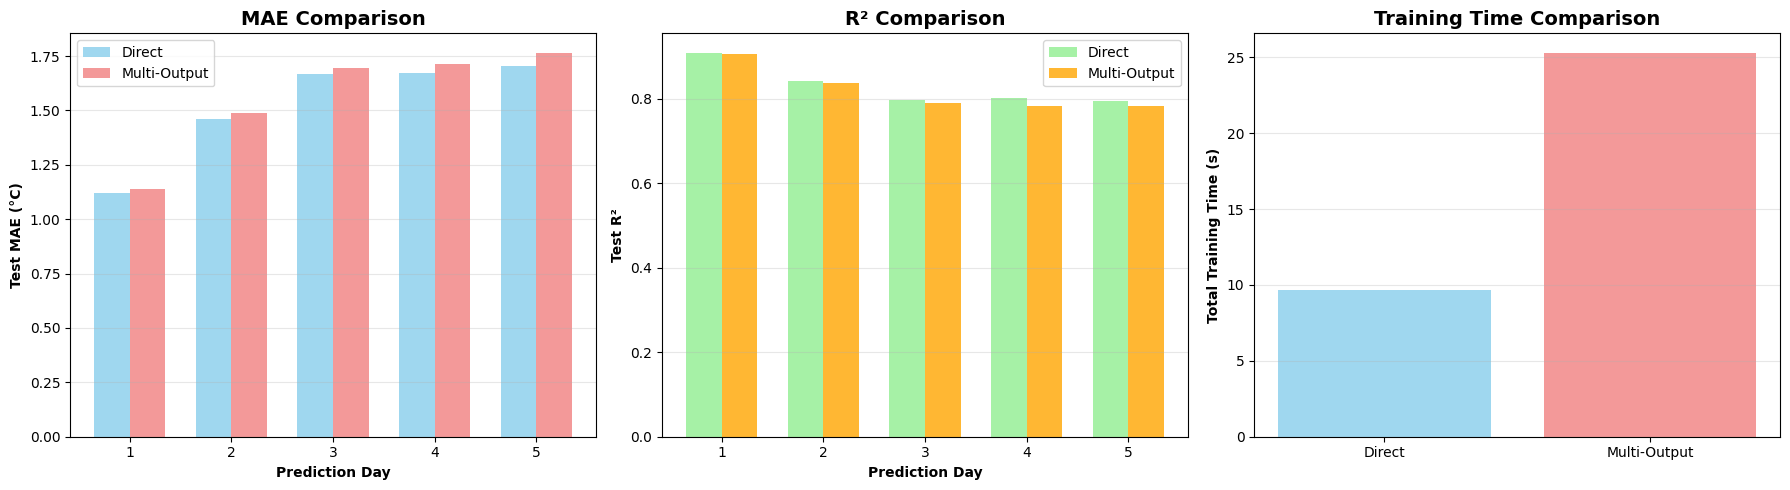


✅ Results logged to ClearML

✅ COMPARISON COMPLETED



██████▉                           21% | 0.41/1.89 MB [05:28<19:59, 808.13s/MB]: 

█████████████████████████████████ 100% | 2.55/2.55 MB [00:07<00:00,  2.86s/MB]: 

█████████████████████████████████ 100% | 2.55/2.55 MB [00:23<00:00,  9.34s/MB]: 



In [108]:
# ==========================================
# 🔄 MULTI-OUTPUT vs DIRECT TRAINING COMPARISON
# ==========================================

print(f"\n{'='*100}")
print(f"🔄 MULTI-OUTPUT vs DIRECT TRAINING COMPARISON")
print(f"{'='*100}\n")

# ==========================================
# 1️⃣ PREPARE COMPARISON DATA
# ==========================================

# Get best model name from direct training
best_direct_model = model_avg.index[0]

print(f"🏆 Comparing: {best_direct_model}")
print(f"{'─'*100}\n")

# Extract metrics from both approaches
comparison_rows = []

for day in range(1, 6):
    target_col = f'y_temp_{day}'
    
    # Direct model metrics
    direct_metrics = all_model_results[best_direct_model][target_col]
    
    # Multi-output metrics
    multi_metrics = all_model_results_mo[best_direct_model][target_col]
    
    comparison_rows.append({
        'Day': day,
        'Direct_MAE': direct_metrics['mae_test'],
        'Multi_MAE': multi_metrics['mae_test'],
        'Direct_RMSE': direct_metrics['rmse_test'],
        'Multi_RMSE': multi_metrics['rmse_test'],
        'Direct_R²': direct_metrics['r2_test'],
        'Multi_R²': multi_metrics['r2_test'],
        'Direct_Time': direct_metrics['train_time'],
        'Multi_Time': multi_metrics['train_time'] / 5  # Divide by 5 days
    })

comparison_df = pd.DataFrame(comparison_rows)

# ==========================================
# 2️⃣ PRINT COMPARISON TABLE
# ==========================================

print("📊 PERFORMANCE COMPARISON TABLE")
print(f"{'─'*100}\n")

# Calculate differences
comparison_df['Diff_MAE'] = comparison_df['Multi_MAE'] - comparison_df['Direct_MAE']
comparison_df['Diff_R²'] = comparison_df['Multi_R²'] - comparison_df['Direct_R²']

print(comparison_df.round(4).to_string(index=False))

# ==========================================
# 3️⃣ SUMMARY STATISTICS
# ==========================================

print(f"\n{'='*100}")
print("📈 SUMMARY STATISTICS")
print(f"{'='*100}\n")

direct_avg_mae = comparison_df['Direct_MAE'].mean()
multi_avg_mae = comparison_df['Multi_MAE'].mean()
direct_total_time = comparison_df['Direct_Time'].sum()
multi_total_time = comparison_df['Multi_Time'].iloc[0] * 5  # Total for all 5 days

print(f"🔵 DIRECT TRAINING:")
print(f"   Avg Test MAE:     {direct_avg_mae:.4f}°C")
print(f"   Avg Test R²:      {comparison_df['Direct_R²'].mean():.4f}")
print(f"   Total Train Time: {direct_total_time:.2f}s")

print(f"\n🟢 MULTI-OUTPUT:")
print(f"   Avg Test MAE:     {multi_avg_mae:.4f}°C")
print(f"   Avg Test R²:      {comparison_df['Multi_R²'].mean():.4f}")
print(f"   Total Train Time: {multi_total_time:.2f}s")

# Winner
mae_diff = direct_avg_mae - multi_avg_mae
time_diff = direct_total_time - multi_total_time

print(f"\n{'─'*100}")
if mae_diff > 0:
    print(f"🏆 WINNER: MULTI-OUTPUT")
    print(f"   Better MAE by:    {mae_diff:.4f}°C ({mae_diff/direct_avg_mae*100:.1f}%)")
else:
    print(f"🏆 WINNER: DIRECT")
    print(f"   Better MAE by:    {-mae_diff:.4f}°C ({-mae_diff/multi_avg_mae*100:.1f}%)")

print(f"   Time saved:       {time_diff:.2f}s ({time_diff/direct_total_time*100:.1f}%)")

# ==========================================
# 4️⃣ VISUALIZATION
# ==========================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

days = comparison_df['Day'].values
x = np.arange(len(days))
width = 0.35

# Plot 1: MAE Comparison
axes[0].bar(x - width/2, comparison_df['Direct_MAE'], width, 
           label='Direct', alpha=0.8, color='skyblue')
axes[0].bar(x + width/2, comparison_df['Multi_MAE'], width, 
           label='Multi-Output', alpha=0.8, color='lightcoral')
axes[0].set_xlabel('Prediction Day', fontweight='bold')
axes[0].set_ylabel('Test MAE (°C)', fontweight='bold')
axes[0].set_title('MAE Comparison', fontweight='bold', fontsize=14)
axes[0].set_xticks(x)
axes[0].set_xticklabels(days)
axes[0].legend()
axes[0].grid(True, alpha=0.3, axis='y')

# Plot 2: R² Comparison
axes[1].bar(x - width/2, comparison_df['Direct_R²'], width, 
           label='Direct', alpha=0.8, color='lightgreen')
axes[1].bar(x + width/2, comparison_df['Multi_R²'], width, 
           label='Multi-Output', alpha=0.8, color='orange')
axes[1].set_xlabel('Prediction Day', fontweight='bold')
axes[1].set_ylabel('Test R²', fontweight='bold')
axes[1].set_title('R² Comparison', fontweight='bold', fontsize=14)
axes[1].set_xticks(x)
axes[1].set_xticklabels(days)
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis='y')

# Plot 3: Training Time
time_data = pd.DataFrame({
    'Method': ['Direct', 'Multi-Output'],
    'Time': [direct_total_time, multi_total_time]
})
axes[2].bar(time_data['Method'], time_data['Time'], 
           color=['skyblue', 'lightcoral'], alpha=0.8)
axes[2].set_ylabel('Total Training Time (s)', fontweight='bold')
axes[2].set_title('Training Time Comparison', fontweight='bold', fontsize=14)
axes[2].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# ==========================================
# 5️⃣ LOG TO CLEARML
# ==========================================

if CLEARML_AVAILABLE and logger:
    logger.report_matplotlib_figure(
        title="Multi-Output vs Direct Comparison",
        series=f"{best_direct_model}",
        figure=fig,
        iteration=0
    )
    
    logger.report_table(
        title="Comparison Table",
        series="Multi vs Direct",
        table_plot=comparison_df,
        iteration=0
    )
    
    print("\n✅ Results logged to ClearML")

print(f"\n{'='*100}")
print(f"✅ COMPARISON COMPLETED")
print(f"{'='*100}\n")

# **8. ClearML Finalize Task**

After running the experiment, visit **https://app.clear.ml** to access:

### 📊 Experiment Tracking
- **Scalars**: Real-time metrics (MAE, MSE, R², Adjusted R²) for train/val/test
- **Plots**: Interactive visualizations of model performance
- **Hyperparameters**: All model configurations and settings
- **Console**: Full training logs and output

### 🔍 Model Management
- **Artifacts**: Saved models (.joblib files) and feature lists
- **Comparison**: Side-by-side comparison of different experiments
- **Versioning**: Track model evolution over time

### 📈 Advanced Features
- **Resource Monitoring**: CPU, GPU, Memory usage during training
- **Debugging**: Output logs, warnings, errors
- **Collaboration**: Share experiments with team members
- **Reproducibility**: Clone experiments with exact same settings

In [ ]:
# ==========================================
# 🏁 FINALIZE CLEARML TASK
# ==========================================

if CLEARML_AVAILABLE and task:
    # ✅ Compute summary from all_model_results (DAILY models)
    # Take any model to summarize (e.g., Random Forest)
    model_to_summarize = 'Random Forest'  # Or any model you choose
    
    if model_to_summarize in all_model_results:
        model_results = all_model_results[model_to_summarize]
        
        final_summary = {
            'avg_test_mae': np.mean([
                model_results[f'y_temp_{i}']['mae_test'] 
                for i in range(1, 6)
            ]),
            'avg_test_r2': np.mean([
                model_results[f'y_temp_{i}']['r2_test'] 
                for i in range(1, 6)
            ]),
            'avg_overfitting_gap': np.mean([
                model_results[f'y_temp_{i}']['gap_r2_test']
                for i in range(1, 6)
            ]),
            'best_day_mae': min([
                model_results[f'y_temp_{i}']['mae_test'] 
                for i in range(1, 6)
            ]),
            'worst_day_mae': max([
                model_results[f'y_temp_{i}']['mae_test'] 
                for i in range(1, 6)
            ])
        }
        
        # Log summary as text
        logger.report_text(
            f"""
            === FINAL EXPERIMENT SUMMARY ===
            Model: {model_to_summarize}
            
            Average Test MAE: {final_summary['avg_test_mae']:.4f}°C
            Average Test R²: {final_summary['avg_test_r2']:.4f}
            Average Overfitting Gap: {final_summary['avg_overfitting_gap']:.4f}
            Best Day MAE: {final_summary['best_day_mae']:.4f}°C
            Worst Day MAE: {final_summary['worst_day_mae']:.4f}°C
            
            Features: {n_features}
            Training Samples: {len(X_train)}
            Validation Samples: {len(X_val)}
            Test Samples: {len(X_test)}
            """
        )
        
        # Mark task as completed
        print("\n" + "="*60)
        print("✅ ClearML experiment tracking completed!")
        print(f"📊 View results at: https://app.clear.ml")
        print(f"🎯 Project: Temperature_Prediction_Hanoi")
        print(f"📝 Task: Feature_Engineering_Complete_Pipeline_v2")
        print("="*60)
        
        print(f"\n📈 Final Performance ({model_to_summarize}):")
        print(f"  Average Test MAE: {final_summary['avg_test_mae']:.4f}°C")
        print(f"  Average Test R²: {final_summary['avg_test_r2']:.4f}")
        print(f"  Overfitting Gap: {final_summary['avg_overfitting_gap']:.4f}")
    else:
        print(f"⚠️  Model '{model_to_summarize}' not found in all_model_results")

else:
    print("⚠️  ClearML not available - experiment not tracked")



            === FINAL EXPERIMENT SUMMARY ===
            Model: Random Forest
            
            Average Test MAE: 1.5923°C
            Average Test R²: 0.8191
            Average Overfitting Gap: 0.0194
            Best Day MAE: 1.3410°C
            Worst Day MAE: 1.7126°C
            
            Features: 186
            Training Samples: 2739
            Validation Samples: 364
            Test Samples: 548
            

✅ ClearML experiment tracking completed!
📊 View results at: https://app.clear.ml
🎯 Project: Temperature_Prediction_Hanoi
📝 Task: Feature_Engineering_Complete_Pipeline_v2

📈 Final Performance (Random Forest):
  Average Test MAE: 1.5923°C
  Average Test R²: 0.8191
  Overfitting Gap: 0.0194


In [140]:
def create_features_for_forecast(data):
    """
    Create features exactly like create_features_and_split,
    but DO NOT create y, DO NOT dropna, used to get X_latest for future prediction.
    """
    df = data.copy()
    
    # ===== PET (Potential Evapotranspiration) =====
    temp_diff = (df['tempmax'] - df['tempmin']).clip(lower=0)
    df['PET'] = (0.0023 * df['solarenergy'] * 0.408 * 
                 np.sqrt(temp_diff) * (df['temp'] + 17.8))
    
    # ===== DERIVED FEATURES =====
    df['daylight_duration_hours'] = (df['sunset'] - df['sunrise']).dt.total_seconds() / 3600
    df['wind_U'] = df['windspeed'] * np.sin(2 * np.pi * df['winddir'] / 360)
    df['wind_V'] = df['windspeed'] * np.cos(2 * np.pi * df['winddir'] / 360)
    df['pressure_daily_change'] = df['sealevelpressure'].diff(3)
    df['solar_cloud_interaction'] = df['solarradiation'] * (1 - (df['cloudcover'] / 100))
    df['wind_gust_ratio'] = df['windgust'] / (df['windspeed'] + 1e-6)
    
    # ===== CYCLICAL TIME FEATURES =====
    if 'datetime' in df.columns:
        df['month_sin'] = np.sin(2 * np.pi * df['datetime'].dt.month / 12)
        df['month_cos'] = np.cos(2 * np.pi * df['datetime'].dt.month / 12)
        df['day_sin'] = np.sin(2 * np.pi * df['datetime'].dt.day_of_year / 365.25)
        df['day_cos'] = np.cos(2 * np.pi * df['datetime'].dt.day_of_year / 365.25)
    
    # ===== ROLLING WINDOW FEATURES =====
    roll_cols = ['dew', 'humidity', 'precip', 'precipcover', 'windgust',
                 'windspeed', 'sealevelpressure', 'pressure_daily_change', 
                 'cloudcover', 'solarradiation', 'solarenergy', 
                 'solar_cloud_interaction', 'PET', 'daylight_duration_hours', 
                 'wind_U', 'wind_V']
    
    windows = [7, 28, 56, 84]
    all_features_list = []
    
    for col in roll_cols:
        if col not in df.columns:
            continue
        col_name_upper = col.upper()
        for w in windows:
            # Rolling mean
            mean_series = df[col].shift(1).rolling(window=w).mean()
            mean_series.name = f"{w}D_AVG_{col_name_upper}"
            all_features_list.append(mean_series)
            
            # Rolling variance
            var_series = df[col].shift(1).rolling(window=w).var()
            var_series.name = f"{w}D_VAR_{col_name_upper}"
            all_features_list.append(var_series)
    
    # ===== STATIC FEATURES =====
    cols = ['month_cos', 'month_sin', 'humidity', 'dew', 'precip', 
            'sealevelpressure', 'solar_cloud_interaction', 'precipcover', 
            'solarradiation', 'pressure_daily_change', 'PET', 
            'daylight_duration_hours', 'windspeed', 'winddir', 'solarenergy',
            'windgust', 'cloudcover', 'conditions_Clear', 'conditions_Overcast', 
            'conditions_Partially cloudy', 'conditions_Rain', 
            'conditions_Rain, Overcast', 'conditions_Rain, Partially cloudy']
    
    for col in cols:
        if col in df.columns:
            all_features_list.append(df[col])
    
    # ===== POLYNOMIAL FEATURES =====
    poly_candidates = ['humidity', 'dew', 'precip', 'precipcover', 'windspeed', 
                       'windgust', 'solarenergy', 'solarradiation', 'cloudcover', 
                       'PET', 'daylight_duration_hours', 'sealevelpressure']
    
    for col in poly_candidates:
        if col not in df.columns:
            continue
        base = df[col]
        all_features_list.append((base ** 2).rename(f"{col.upper()}_SQ"))
        all_features_list.append((base ** 3).rename(f"{col.upper()}_CUBE"))
        all_features_list.append(np.sqrt(base.clip(lower=0)).rename(f"{col.upper()}_SQRT"))
        all_features_list.append(np.log1p(base.clip(lower=0)).rename(f"{col.upper()}_LOG1P"))
    
    features_df = pd.concat(all_features_list, axis=1)
    
    # If you have clean_feature_names, use it to ensure consistency with X_train
    if 'clean_feature_names' in globals():
        features_df = clean_feature_names(features_df)
    if 'datetime' in df.columns:
        features_df.index = pd.to_datetime(df['datetime'])
    return features_df


█████████████████████████████████ 100% | 3.68/3.68 MB [00:03<00:00,  1.04s/MB]: 

# **9. Time Series Model Training: ARIMAX and Prophet**

In [141]:
# ==========================================
# 📊 SECTION 7: TIME SERIES MODELS WITH FEATURES (ARIMAX + PROPHET)
# ==========================================

print(f"\n{'='*100}")
print(f"📈 SECTION 7: TIME SERIES MODELS WITH FEATURES (USING create_features_for_forecast)")
print(f"{'='*100}\n")

import time
import numpy as np
import pandas as pd
from datetime import timedelta

from sklearn.metrics import mean_absolute_error, r2_score
from statsmodels.tsa.arima.model import ARIMA
from prophet import Prophet

# ==========================================
# 1️⃣ BUILD TIME SERIES (y_temp_1) + EXOG FROM create_features_for_forecast
# ==========================================

print(f"\n{'─'*80}")
print("📊 PREPARING TIME SERIES + EXOG USING create_features_for_forecast")
print(f"{'─'*80}")

def build_ts_and_exog_v2(raw_data_df):
    """
    Sử dụng create_features_for_forecast để tạo features,
    sau đó tạo target y_temp_1 từ raw data.
    
    Args:
        raw_data_df: DataFrame raw có cột 'datetime' và 'temp'
    
    Returns:
        ts: Series target (y_temp_1)
        exog: DataFrame features
    """
    # 1. Create features from existing function
    features_df = create_features_for_forecast(raw_data_df)
    
    # 2. Create target y_temp_1 (temperature for day D+1)
    raw_data_df = raw_data_df.copy()
    raw_data_df['datetime'] = pd.to_datetime(raw_data_df['datetime'])
    raw_data_df = raw_data_df.set_index('datetime').sort_index()
    
    # y_temp_1 = temperature for next day
    y_temp_1 = raw_data_df['temp'].shift(-1)
    
    # 3. Align features and target
    common_idx = features_df.index.intersection(y_temp_1.index)
    
    ts = y_temp_1.loc[common_idx]
    exog = features_df.loc[common_idx]
    
    # 4. ✅ FIX: Remove NaN/Inf BEFORE training
    # Combine to dropna together
    combined = pd.concat([ts.rename('target'), exog], axis=1)
    
    # Replace inf with NaN
    combined = combined.replace([np.inf, -np.inf], np.nan)
    
    # Drop rows with NaN
    combined = combined.dropna()
    
    # Split again
    ts_clean = combined['target']
    exog_clean = combined.drop(columns=['target'])
    
    return ts_clean, exog_clean

# Create features and targets for train/val/test
print("\n🎨 Creating features using create_features_for_forecast...")

ts_train, exog_train = build_ts_and_exog_v2(train_data)
ts_val, exog_val = build_ts_and_exog_v2(val_data)
ts_test, exog_test = build_ts_and_exog_v2(test_data)

# Clean feature names (LightGBM compatible)
exog_train = clean_feature_names_lightgbm(exog_train)
exog_val = clean_feature_names_lightgbm(exog_val)
exog_test = clean_feature_names_lightgbm(exog_test)

# Concatenate full data for refit and forecast
ts_full = pd.concat([ts_train, ts_val, ts_test])
exog_full = pd.concat([exog_train, exog_val, exog_test])

exog_cols = list(exog_train.columns)

# Get last date from raw data
full_raw = pd.concat([train_data, val_data, test_data], ignore_index=True)
full_raw["datetime"] = pd.to_datetime(full_raw["datetime"])
raw_last_date = full_raw["datetime"].max()


# Use SelectKBest to select top 20 most important features
selector = SelectKBest(score_func=f_regression, k=20)
selector.fit(exog_train, ts_train)

# Get selected feature names
selected_features = exog_train.columns[selector.get_support()].tolist()

print(f"✅ Selected {len(selected_features)} features:")
print(f"   {selected_features[:10]}")  # Print first 10 features
print(f"   ... and {len(selected_features)-10} more")

# Create new exog with selected features only
exog_train_selected = exog_train[selected_features]
exog_val_selected = exog_val[selected_features]
exog_test_selected = exog_test[selected_features]
exog_full_selected = exog_full[selected_features]

# ==========================================
# 2️⃣ ARIMAX WITH AUTO ORDER SELECTION
# ==========================================

print(f"\n{'='*100}")
print(f"📈 MODEL 1: ARIMAX (AUTO ORDER + TOP 20 FEATURES)")
print(f"{'='*100}")

from statsmodels.tsa.stattools import acf, pacf

# Find best order based on ACF/PACF
best_aic = np.inf
best_order = None
best_model = None

# Test different orders
orders_to_test = [
    (1, 1, 1), (2, 1, 1), (3, 1, 1),
    (1, 1, 2), (2, 1, 2), (3, 1, 2),
    (2, 0, 1), (2, 0, 2)
]

print("\n🔍 Testing different ARIMAX orders...")
for order in orders_to_test:
    try:
        model = ARIMA(ts_train, order=order, exog=exog_train_selected)
        fitted = model.fit()
        
        if fitted.aic < best_aic:
            best_aic = fitted.aic
            best_order = order
            best_model = fitted
            
        print(f"   Order {order}: AIC={fitted.aic:.2f}")
    except:
        continue

print(f"\n✅ Best ARIMAX order: {best_order} (AIC={best_aic:.2f})")

arimax_fitted = best_model
train_time_arimax = 0  # Already trained

print("\n🔮 Making ARIMAX predictions...")

# In-sample
arimax_train_pred = arimax_fitted.fittedvalues

# Forecast val
arimax_val_pred = arimax_fitted.forecast(
    steps=len(ts_val),
    exog=exog_val_selected
)

# Forecast test
exog_val_test_selected = pd.concat([exog_val_selected, exog_test_selected])
arimax_all_pred = arimax_fitted.forecast(
    steps=len(ts_val) + len(ts_test),
    exog=exog_val_test_selected
)
arimax_test_pred = arimax_all_pred[-len(ts_test):]

# Metrics
arimax_train_mae = mean_absolute_error(ts_train[1:], arimax_train_pred[1:])
arimax_val_mae = mean_absolute_error(ts_val, arimax_val_pred)
arimax_test_mae = mean_absolute_error(ts_test, arimax_test_pred)

arimax_train_r2 = r2_score(ts_train[1:], arimax_train_pred[1:])
arimax_val_r2 = r2_score(ts_val, arimax_val_pred)
arimax_test_r2 = r2_score(ts_test, arimax_test_pred)

print(f"\n📊 ARIMAX Performance (with feature selection):")
print(f"   Train - MAE: {arimax_train_mae:.4f}°C | R²: {arimax_train_r2:.4f}")
print(f"   Val   - MAE: {arimax_val_mae:.4f}°C | R²: {arimax_val_r2:.4f}")
print(f"   Test  - MAE: {arimax_test_mae:.4f}°C | R²: {arimax_test_r2:.4f}")
print(f"   🎯 Overfitting Gap: Train-Test MAE = {arimax_test_mae - arimax_train_mae:.4f}°C")

ts_results = [{
    "Model": "ARIMAX (Optimized)",
    "Features": len(selected_features),
    "Order": str(best_order),
    "Test_MAE": arimax_test_mae,
    "Test_R2": arimax_test_r2,
    "Val_R2": arimax_val_r2,
    "Overfitting_Gap": arimax_train_r2 - arimax_test_r2
}]

# ==========================================
# 3️⃣ PROPHET (NO CHANGES - ALREADY GOOD)
# ==========================================

print(f"\n{'='*100}")
print(f"📈 MODEL 2: PROPHET WITH REGRESSORS")
print(f"{'='*100}")

prophet_train_df = pd.DataFrame({
    "ds": ts_train.index,
    "y": ts_train.values
})

# Prophet also uses top 20 features
prophet_train_df[selected_features] = exog_train_selected.values

print(f"\n⚙️ Prophet Configuration:")
print(f"   Regressors: {len(selected_features)} features (reduced)")

print("\n🔄 Training Prophet...")
start_time = time.time()

prophet_model = Prophet(
    daily_seasonality=True,
    weekly_seasonality=True,
    yearly_seasonality=True,
    seasonality_mode="multiplicative"
)

for col in selected_features:
    prophet_model.add_regressor(col)

prophet_model.fit(prophet_train_df)

train_time_prophet = time.time() - start_time
print(f"✅ Prophet trained in {train_time_prophet:.2f}s")

# Predictions
prophet_train_pred = prophet_model.predict(prophet_train_df)["yhat"].values

prophet_val_df = pd.DataFrame({"ds": ts_val.index})
prophet_val_df[selected_features] = exog_val_selected.values
prophet_val_pred = prophet_model.predict(prophet_val_df)["yhat"].values

prophet_test_df = pd.DataFrame({"ds": ts_test.index})
prophet_test_df[selected_features] = exog_test_selected.values
prophet_test_pred = prophet_model.predict(prophet_test_df)["yhat"].values

# Metrics
prophet_train_mae = mean_absolute_error(ts_train, prophet_train_pred)
prophet_val_mae = mean_absolute_error(ts_val, prophet_val_pred)
prophet_test_mae = mean_absolute_error(ts_test, prophet_test_pred)

prophet_train_r2 = r2_score(ts_train, prophet_train_pred)
prophet_val_r2 = r2_score(ts_val, prophet_val_pred)
prophet_test_r2 = r2_score(ts_test, prophet_test_pred)

print(f"\n📊 Prophet Performance:")
print(f"   Train - MAE: {prophet_train_mae:.4f}°C | R²: {prophet_train_r2:.4f}")
print(f"   Val   - MAE: {prophet_val_mae:.4f}°C | R²: {prophet_val_r2:.4f}")
print(f"   Test  - MAE: {prophet_test_mae:.4f}°C | R²: {prophet_test_r2:.4f}")
print(f"   🎯 Overfitting Gap: {prophet_train_r2 - prophet_test_r2:.4f}")

ts_results.append({
    "Model": "Prophet + Regressors",
    "Features": len(selected_features),
    "Order": "N/A",
    "Test_MAE": prophet_test_mae,
    "Test_R2": prophet_test_r2,
    "Val_R2": prophet_val_r2,
    "Overfitting_Gap": prophet_train_r2 - prophet_test_r2
})

# ==========================================
# 4️⃣ COMPARISON
# ==========================================

print(f"\n{'='*100}")
print("📊 OPTIMIZED TIME SERIES MODELS COMPARISON")
print(f"{'='*100}\n")

comparison_ts = pd.DataFrame(ts_results)
print(comparison_ts.to_string(index=False))

# ==========================================
# 5️⃣ 5-DAY FORECAST
# ==========================================

print(f"\n{'='*100}")
print("🔮 PREDICTING NEXT 5 DAYS")
print(f"{'='*100}\n")

future_dates = pd.date_range(start=raw_last_date + timedelta(days=1), periods=5, freq="D")

# Exog future (top 20 features)
last_exog_selected = exog_full_selected.iloc[-1].fillna(method='ffill').fillna(0)
exog_future_selected = pd.DataFrame(
    [last_exog_selected.values] * len(future_dates),
    index=future_dates,
    columns=selected_features
)

# ARIMAX forecast
arimax_full = ARIMA(ts_full, order=best_order, exog=exog_full_selected).fit()
arimax_future = arimax_full.forecast(steps=5, exog=exog_future_selected)

print(f"\n{'─'*80}")
print("📈 ARIMAX - 5 Day Forecast")
print(f"{'─'*80}")
for i, (d, temp) in enumerate(zip(future_dates, arimax_future), 1):
    print(f"   Day {i} ({d.strftime('%Y-%m-%d')}): {temp:.2f}°C")

# Prophet forecast
prophet_full_df = pd.DataFrame({"ds": ts_full.index, "y": ts_full.values})
prophet_full_df[selected_features] = exog_full_selected.values

prophet_full_model = Prophet(
    daily_seasonality=True,
    weekly_seasonality=True,
    yearly_seasonality=True,
    seasonality_mode="multiplicative"
)
for col in selected_features:
    prophet_full_model.add_regressor(col)

prophet_full_model.fit(prophet_full_df)

prophet_future_df = pd.DataFrame({"ds": future_dates})
prophet_future_df[selected_features] = exog_future_selected.values
prophet_future = prophet_full_model.predict(prophet_future_df)

print(f"\n{'─'*80}")
print("📈 PROPHET - 5 Day Forecast")
print(f"{'─'*80}")
for i, row in prophet_future.iterrows():
    print(f"   Day {i+1} ({row['ds'].strftime('%Y-%m-%d')}): "
          f"{row['yhat']:.2f}°C [{row['yhat_lower']:.2f}°C - {row['yhat_upper']:.2f}°C]")

print(f"\n{'='*100}")
print("✅ SECTION 7 COMPLETED - OPTIMIZED TIME SERIES MODELS")
print(f"{'='*100}\n")


📈 SECTION 7: TIME SERIES MODELS WITH FEATURES (USING create_features_for_forecast)


────────────────────────────────────────────────────────────────────────────────
📊 PREPARING TIME SERIES + EXOG USING create_features_for_forecast
────────────────────────────────────────────────────────────────────────────────

🎨 Creating features using create_features_for_forecast...
✅ Selected 20 features:
   ['7D_AVG_DEW', '28D_AVG_DEW', '28D_AVG_SEALEVELPRESSURE', '56D_AVG_SEALEVELPRESSURE', '28D_AVG_SOLARRADIATION', '28D_AVG_SOLARENERGY', '7D_AVG_DAYLIGHT_DURATION_HOURS', '28D_AVG_DAYLIGHT_DURATION_HOURS', '56D_AVG_DAYLIGHT_DURATION_HOURS', '84D_AVG_DAYLIGHT_DURATION_HOURS']
   ... and 10 more

📈 MODEL 1: ARIMAX (AUTO ORDER + TOP 20 FEATURES)

🔍 Testing different ARIMAX orders...
✅ Selected 20 features:
   ['7D_AVG_DEW', '28D_AVG_DEW', '28D_AVG_SEALEVELPRESSURE', '56D_AVG_SEALEVELPRESSURE', '28D_AVG_SOLARRADIATION', '28D_AVG_SOLARENERGY', '7D_AVG_DAYLIGHT_DURATION_HOURS', '28D_AVG_DAYLIGHT_DURAT

c:\Users\ADMIN\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning:

No frequency information was provided, so inferred frequency D will be used.

c:\Users\ADMIN\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning:

No frequency information was provided, so inferred frequency D will be used.

c:\Users\ADMIN\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning:

No frequency information was provided, so inferred frequency D will be used.



   Order (1, 1, 1): AIC=10223.85


c:\Users\ADMIN\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning:

No frequency information was provided, so inferred frequency D will be used.

c:\Users\ADMIN\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning:

No frequency information was provided, so inferred frequency D will be used.

c:\Users\ADMIN\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning:

No frequency information was provided, so inferred frequency D will be used.



   Order (2, 1, 1): AIC=10224.74


...

✅ Prophet trained in 2.40s

📊 Prophet Performance:
   Train - MAE: 1.4996°C | R²: 0.8636
   Val   - MAE: 1.7870°C | R²: 0.8235
   Test  - MAE: 2.0918°C | R²: 0.7210
   🎯 Overfitting Gap: 0.1425

📊 OPTIMIZED TIME SERIES MODELS COMPARISON

               Model  Features     Order  Test_MAE  Test_R2   Val_R2  Overfitting_Gap
  ARIMAX (Optimized)        20 (2, 0, 2)  1.476624 0.840912 0.866602         0.069541
Prophet + Regressors        20       N/A  2.091824 0.721006 0.823473         0.142545

🔮 PREDICTING NEXT 5 DAYS


📊 Prophet Performance:
   Train - MAE: 1.4996°C | R²: 0.8636
   Val   - MAE: 1.7870°C | R²: 0.8235
   Test  - MAE: 2.0918°C | R²: 0.7210
   🎯 Overfitting Gap: 0.1425

📊 OPTIMIZED TIME SERIES MODELS COMPARISON

               Model  Features     Order  Test_MAE  Test_R2   Val_R2  Overfitting_Gap
  ARIMAX (Optimized)        20 (2, 0, 2)  1.476624 0.840912 0.866602         0.069541
Prophet + Regressors        20       N/A  2.091824 0.721006 0.823473         0.142545

🔮 PREDI

c:\Users\ADMIN\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning:

A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.

c:\Users\ADMIN\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning:

A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.

c:\Users\ADMIN\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning:

A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.

c:\Users\ADMIN\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning:

Maximum Likelihood optimization failed to converge. Check mle_retvals

c:\Users\ADMIN\AppData\Local\Programs\Python\


────────────────────────────────────────────────────────────────────────────────
📈 ARIMAX - 5 Day Forecast
────────────────────────────────────────────────────────────────────────────────
   Day 1 (2025-10-02): 27.62°C
   Day 2 (2025-10-03): 27.77°C
   Day 3 (2025-10-04): 27.85°C
   Day 4 (2025-10-05): 27.90°C
   Day 5 (2025-10-06): 27.93°C


09:48:13 - cmdstanpy - INFO - Chain [1] start processing
09:48:15 - cmdstanpy - INFO - Chain [1] done processing
09:48:15 - cmdstanpy - INFO - Chain [1] done processing



────────────────────────────────────────────────────────────────────────────────
📈 PROPHET - 5 Day Forecast
────────────────────────────────────────────────────────────────────────────────
   Day 1 (2025-10-02): 27.86°C [25.47°C - 30.20°C]
   Day 2 (2025-10-03): 27.85°C [25.51°C - 30.18°C]
   Day 3 (2025-10-04): 27.79°C [25.29°C - 30.20°C]
   Day 4 (2025-10-05): 27.85°C [25.44°C - 30.25°C]
   Day 5 (2025-10-06): 27.82°C [25.65°C - 30.25°C]

✅ SECTION 7 COMPLETED - OPTIMIZED TIME SERIES MODELS



# **10. Direct ML Model Predictions for next 5 days**

In [ ]:
from datetime import timedelta
import matplotlib.pyplot as plt

def predict_next_5_days_direct(
    full_data,
    all_model_results,
    X_train,
    best_scaler_name=None,
    scaled_datasets=None,
    window_days=200,
    save_dir="../data/processed"
):
    """
    All-in-one: dự đoán 5 ngày tương lai cho TẤT CẢ các model direct.

    full_data: DataFrame raw (train+val+test hoặc mới nhất), có 'datetime'
    models_to_predict: dict cấu hình model (giống phần direct)
    all_model_results: dict metrics để lấy MAE làm khoảng tin cậy
    X_train: DataFrame features train (dùng để align cột)
    best_scaler_name: tên scaler (key trong scaled_datasets) if available
    scaled_datasets: dict {scaler_name: {'scaler': scaler_obj, ...}}
    window_days: số ngày cuối dùng để tạo features (>= max rolling window)
    save_dir: thư mục lưu CSV
    """
    models_to_predict = {
    'Random Forest': {'needs_scaling': False},
    'Extra Trees': {'needs_scaling': False},
    'XGBoost': {'needs_scaling': False},
    'LightGBM': {'needs_scaling': False},
    'CatBoost': {'needs_scaling': False}}

    print(f"\n{'='*100}")
    print("🔮 FUTURE PREDICTION (DIRECT MODELS) - NEXT 5 DAYS")
    print(f"{'='*100}\n")
    
    full_data = full_data.sort_values("datetime").reset_index(drop=True)
    
    # Get last window to create features (ensure enough for 84-day rolling)
    last_window = full_data.tail(window_days).copy()
    
    # Create full features for this window
    features_df = create_features_for_forecast(last_window)
    
    # Get exactly the last row as input
    X_latest = features_df.iloc[[-1]].copy()
    
    # Align columns with X_train
    X_latest = X_latest.reindex(columns=X_train.columns, fill_value=0)
    
    # Create scaled version if best scaler exists
    if best_scaler_name is not None and scaled_datasets is not None:
        scaler = scaled_datasets[best_scaler_name]['scaler']
        X_latest_scaled = scaler.transform(X_latest)
        X_latest_scaled_df = pd.DataFrame(
            X_latest_scaled,
            columns=X_train.columns,
            index=X_latest.index
        )
        print(f"✅ Using scaler '{best_scaler_name}' for scaled predictions")
    else:
        X_latest_scaled_df = None
        print("ℹ️ No scaler provided – only original features will be used")
    
    last_date = last_window["datetime"].iloc[-1]
    print(f"📅 Last known date: {last_date}")
    
    # Results container
    all_model_predictions = {}
    
    # ==========================================
    # PREDICT FOR EACH MODEL
    # ==========================================
    
    for model_name, config in models_to_predict.items():
        # print(f"\n{'─'*100}")
        # print(f"📍 MODEL: {model_name}")
        # print(f"{'─'*100}")
        
        # Select input data for model
        if config.get('needs_scaling', False) and X_latest_scaled_df is not None:
            X_pred = X_latest_scaled_df
            # print("   ✓ Using SCALED features")
        else:
            X_pred = X_latest
            # print("   ✓ Using ORIGINAL features")
        
        predictions = []
        prediction_dates = []
        
        # print("\n   🔍 5-DAY RAW PREDICTIONS\n")
        
        # Retrain model for each horizon on full data (train+val+test)
        for i, target_col in enumerate(['y_temp_1', 'y_temp_2', 'y_temp_3', 'y_temp_4', 'y_temp_5'], 1):
            # Initialize correct model type
            if model_name == 'Random Forest':
                model = RandomForestRegressor(
                    n_estimators=150, max_depth=5,
                    min_samples_leaf=10, min_samples_split=20,
                    max_features='sqrt', random_state=42, n_jobs=-1
                )
            elif model_name == 'Extra Trees':
                model = ExtraTreesRegressor(
                    n_estimators=150, max_depth=8, min_samples_split=5,
                    min_samples_leaf=2, max_features='sqrt',
                    random_state=42, n_jobs=-1
                )
            elif model_name == 'XGBoost':
                model = XGBRegressor(
                    n_estimators=100, max_depth=5, learning_rate=0.1,
                    subsample=0.8, colsample_bytree=0.8,
                    random_state=42, n_jobs=-1, verbosity=0
                )
            elif model_name == 'LightGBM':
                model = LGBMRegressor(
                    n_estimators=100, max_depth=5, learning_rate=0.1,
                    subsample=0.8, colsample_bytree=0.8,
                    random_state=42, n_jobs=-1, verbose=-1
                )
            elif model_name == 'CatBoost':
                model = CatBoostRegressor(
                    depth=6,
                    learning_rate=0.1,
                    n_estimators=300,
                    loss_function='RMSE',
                    random_seed=42,
                    verbose=False
                )
            elif model_name == 'Ridge':
                model = Ridge(alpha=1.0, random_state=42)
            elif model_name == 'Bayesian Ridge':
                model = BayesianRidge(compute_score=True)
            elif model_name == 'SVR':
                model = SVR(kernel='rbf', C=10, epsilon=0.1, gamma='scale')
            else:
                print(f"⚠️ Unknown model: {model_name}, skipping...")
                predictions = [np.nan]*5
                break
            
            # Prepare full X / y for training
            if config.get('needs_scaling', False) and X_latest_scaled_df is not None:
                X_full = pd.concat([X_train_scaled_df, X_val_scaled_df, X_test_scaled_df])
            else:
                X_full = pd.concat([X_train, X_val, X_test])
            
            y_full = pd.concat([y_train, y_val, y_test])
            
            model.fit(X_full, y_full[target_col])
            
            # Predict
            pred = model.predict(X_pred)[0]
            predictions.append(pred)
            
            pred_date = last_date + timedelta(days=i)
            prediction_dates.append(pred_date)
        
        # Build results DataFrame
        results_df = pd.DataFrame({
            'Day': range(1, 6),
            'Date': prediction_dates,
            'Predicted_Temp': predictions
        })
        
        # Confidence interval based on measured test MAE
        avg_mae = np.mean([
            all_model_results[model_name][target_col]['mae_test']
            for target_col in ['y_temp_1', 'y_temp_2', 'y_temp_3', 'y_temp_4', 'y_temp_5']
        ])
        
        results_df['Lower_Bound'] = results_df['Predicted_Temp'] - avg_mae
        results_df['Upper_Bound'] = results_df['Predicted_Temp'] + avg_mae
        results_df['Model'] = model_name
        results_df['Uncertainty'] = avg_mae
        
        all_model_predictions[model_name] = results_df
        
        # Print clean, beautiful table
        display_df = results_df.copy()
        display_df['Date'] = display_df['Date'].dt.strftime('%Y-%m-%d')
        display_df['Predicted_Temp'] = display_df['Predicted_Temp'].round(2)
        display_df['Lower_Bound'] = display_df['Lower_Bound'].round(2)
        display_df['Upper_Bound'] = display_df['Upper_Bound'].round(2)
        
    
    # Combine all models
    combined_predictions = pd.concat(all_model_predictions.values(), ignore_index=True)
    # -------------------------------------------------------------
    # 🌟 BLOCK 1: PRINT SUMMARY TABLE OF ALL MODELS 🌟
    # -------------------------------------------------------------
    print(f"\n{'='*100}")
    print("📈 TỔNG HỢP DỰ ĐOÁN 5 NGÀY (TẤT CẢ MODELS)")
    print(f"{'='*100}\n")

    display_df_combined = combined_predictions.copy()

    # Format
    display_df_combined['Date'] = display_df_combined['Date'].dt.strftime('%Y-%m-%d')
    display_df_combined['Predicted_Temp'] = display_df_combined['Predicted_Temp'].round(2)
    display_df_combined['Lower_Bound'] = display_df_combined['Lower_Bound'].round(2)
    display_df_combined['Upper_Bound'] = display_df_combined['Upper_Bound'].round(2)
    display_df_combined['Uncertainty'] = display_df_combined['Uncertainty'].round(2)

    # Print summary table
    cols_to_show = ['Model', 'Day', 'Date', 'Predicted_Temp', 'Lower_Bound', 'Upper_Bound', 'Uncertainty']
    renamed_cols = {
        'Model': 'Model',
        'Day': 'D',
        'Date': 'Date',
        'Predicted_Temp': 'Temp(°C)',
        'Lower_Bound': 'Lower',
        'Upper_Bound': 'Upper',
        'Uncertainty': 'MAE (±)'
    }
    
    print(
        display_df_combined[cols_to_show]
        .rename(columns=renamed_cols)
        .to_string(index=False)
    )
    print("-" * 100)
    
    # -----------------------------------------------------------------
    # 🌟 BLOCK 2: CALCULATE AND PRINT AVERAGE RESULTS OF 4 BEST MODELS 🌟
    # -----------------------------------------------------------------
    
    # 1. Define 4 best models
    BEST_MODELS = ['Random Forest', 'CatBoost', 'XGBoost', 'LightGBM']
    
    # 2. Filter data to get only these 4 models
    best_model_predictions = combined_predictions[
        combined_predictions['Model'].isin(BEST_MODELS)
    ].copy()
    
    # 3. Calculate average by each Day (Day/Date)
    avg_predictions = best_model_predictions.groupby(['Day', 'Date']).agg(
        Predicted_Temp_Avg=('Predicted_Temp', 'mean'),
        Lower_Bound_Avg=('Lower_Bound', 'mean'),
        Upper_Bound_Avg=('Upper_Bound', 'mean'),
        Avg_Uncertainty=('Uncertainty', 'mean')
    ).reset_index()
    
    # 4. Format lại bảng kết quả trung bình
    avg_predictions['Date'] = avg_predictions['Date'].dt.strftime('%Y-%m-%d')
    avg_predictions['Predicted_Temp_Avg'] = avg_predictions['Predicted_Temp_Avg'].round(2)
    avg_predictions['Lower_Bound_Avg'] = avg_predictions['Lower_Bound_Avg'].round(2)
    avg_predictions['Upper_Bound_Avg'] = avg_predictions['Upper_Bound_Avg'].round(2)
    avg_predictions['Avg_Uncertainty'] = avg_predictions['Avg_Uncertainty'].round(2)

    # 5. Print average results table
    # 1. Filter necessary columns and pivot table
    pivot_df = combined_predictions[['Day', 'Date', 'Model', 'Predicted_Temp']].pivot(
        index=['Day', 'Date'],
        columns='Model',
        values='Predicted_Temp'
    ).reset_index()

    # 2. Define 4 best models và tính cột trung bình
    BEST_MODELS = ['Random Forest', 'CatBoost', 'XGBoost', 'LightGBM']

    # Get available model columns from best list
    valid_avg_cols = [col for col in BEST_MODELS if col in pivot_df.columns]

    # Calculate average for 4 best models and create new column
    pivot_df['AVG (Best 4)'] = pivot_df[valid_avg_cols].mean(axis=1)

    # 3. Format kết quả cuối cùng
    pivot_df['Date'] = pivot_df['Date'].dt.strftime('%Y-%m-%d')

    # Round all temperature columns (from column 3 onwards)
    # Get names of predicted temperature columns
    temp_cols = [col for col in pivot_df.columns if col not in ['Day', 'Date']]
    pivot_df[temp_cols] = pivot_df[temp_cols].round(2)
    
    # Reorder columns so average column is right after Date
    cols_order = ['Day', 'Date', 'AVG (Best 4)'] + sorted(valid_avg_cols) + [
        col for col in pivot_df.columns if col not in ['Day', 'Date', 'AVG (Best 4)'] + valid_avg_cols
    ]

    final_display_df = pivot_df[cols_order]

    # 4. Print pivoted results table
    print(f"\n{'='*120}")
    print("📊 BẢNG TỔNG HỢP DỰ ĐOÁN NHIỆT ĐỘ (NGÀY vs MODEL) (°C)")
    print(f"{'='*120}\n")
    print(final_display_df.to_string(index=False))
    print(f"\n{'='*120}")

    

    return all_model_predictions, combined_predictions


In [ ]:
full_data = pd.concat([train_data, val_data, test_data], ignore_index=True)

all_model_predictions, combined_predictions = predict_next_5_days_direct(
    full_data=full_data,
    all_model_results=all_model_results,
    X_train=X_train,
    best_scaler_name=best_scaler_name,          # if available
    scaled_datasets=scaled_datasets,            # if available
    window_days=200,
    save_dir="../data/processed"
)



🔮 FUTURE PREDICTION (DIRECT MODELS) - NEXT 5 DAYS

✅ Using scaler 'MinMax_[-1,1]_SAFE' for scaled predictions
📅 Last known date: 2025-10-01 00:00:00


                                            0% | 0.00/3.72 MB [00:00<?, ?MB/s]: 


📈 TỔNG HỢP DỰ ĐOÁN 5 NGÀY (TẤT CẢ MODELS)

        Model  D       Date  Temp(°C)  Lower  Upper  MAE (±)
Random Forest  1 2025-10-02     27.63  26.08  29.19     1.55
Random Forest  2 2025-10-03     27.88  26.33  29.44     1.55
Random Forest  3 2025-10-04     27.78  26.22  29.33     1.55
Random Forest  4 2025-10-05     27.68  26.13  29.23     1.55
Random Forest  5 2025-10-06     27.51  25.96  29.07     1.55
  Extra Trees  1 2025-10-02     27.36  25.80  28.92     1.56
  Extra Trees  2 2025-10-03     27.58  26.02  29.13     1.56
  Extra Trees  3 2025-10-04     27.30  25.74  28.85     1.56
  Extra Trees  4 2025-10-05     27.29  25.73  28.84     1.56
  Extra Trees  5 2025-10-06     27.22  25.66  28.77     1.56
      XGBoost  1 2025-10-02     27.99  26.42  29.57     1.58
      XGBoost  2 2025-10-03     28.78  27.20  30.35     1.58
      XGBoost  3 2025-10-04     27.46  25.88  29.04     1.58
      XGBoost  4 2025-10-05     28.19  26.62  29.77     1.58
      XGBoost  5 2025-10-06     27.72  26

Retrying (Retry(total=2, connect=2, read=5, redirect=5, status=None)) after connection broken by 'NameResolutionError("<urllib3.connection.HTTPSConnection object at 0x00000268A4C09090>: Failed to resolve 'files.clear.ml' ([Errno 11001] getaddrinfo failed)")': /
Retrying (Retry(total=1, connect=1, read=5, redirect=5, status=None)) after connection broken by 'NameResolutionError("<urllib3.connection.HTTPSConnection object at 0x00000268A4C09BD0>: Failed to resolve 'files.clear.ml' ([Errno 11001] getaddrinfo failed)")': /
██████████████████████████████████ 100% | 3.70/3.7 MB [00:16<00:00,  4.57s/MB]: 
████████████████████▋             65% | 2.41/3.72 MB [21:23<11:40, 533.45s/MB]: 
█████████████████████████████████ 100% | 4.47/4.47 MB [00:14<00:00,  3.34s/MB]: 
██████████████████████████████████ 100% | 3.70/3.7 MB [00:08<00:00,  2.35s/MB]: 
█████████████████████████████████ 100% | 4.47/4.47 MB [00:15<00:00,  3.52s/MB]: 
██████████████████████████████████ 100% | 3.70/3.7 MB [00:10<00:00,  2.

## ClearML summary

In [ ]:
if CLEARML_AVAILABLE and task:
    # Calculate average across ALL models
    all_test_mae = []
    all_test_r2 = []
    all_gaps = []
    
    for model_name, model_results in all_model_results.items():
        for i in range(1, 6):
            target = f'y_temp_{i}'
            all_test_mae.append(model_results[target]['mae_test'])
            all_test_r2.append(model_results[target]['r2_test'])
            all_gaps.append(model_results[target]['gap_r2_test'])
    
    final_summary = {
        'avg_test_mae': np.mean(all_test_mae),
        'avg_test_r2': np.mean(all_test_r2),
        'avg_overfitting_gap': np.mean(all_gaps),
        'best_day_mae': min(all_test_mae),
        'worst_day_mae': max(all_test_mae)
    }
    
    # Log summary
    logger.report_text(
        f"""
        === FINAL EXPERIMENT SUMMARY (ALL MODELS) ===
        
        Models: {', '.join(all_model_results.keys())}
        
        Average Test MAE: {final_summary['avg_test_mae']:.4f}°C
        Average Test R²: {final_summary['avg_test_r2']:.4f}
        Average Overfitting Gap: {final_summary['avg_overfitting_gap']:.4f}
        Best MAE: {final_summary['best_day_mae']:.4f}°C
        Worst MAE: {final_summary['worst_day_mae']:.4f}°C
        
        Features: {n_features}
        Training Samples: {len(X_train)}
        Validation Samples: {len(X_val)}
        Test Samples: {len(X_test)}
        """
    )
    
    print("\n" + "="*60)
    print("✅ ClearML experiment tracking completed!")
    print(f"📊 View results at: https://app.clear.ml")
    print("="*60)
    
    print(f"\n📈 Final Performance (All Models):")
    print(f"  Average Test MAE: {final_summary['avg_test_mae']:.4f}°C")
    print(f"  Average Test R²: {final_summary['avg_test_r2']:.4f}")


        === FINAL EXPERIMENT SUMMARY (ALL MODELS) ===
        
        Models: Random Forest, Extra Trees, XGBoost, LightGBM, CatBoost, Ridge, Bayesian Ridge, SVR
        
        Average Test MAE: 1.6748°C
        Average Test R²: 0.7889
        Average Overfitting Gap: 0.1142
        Best MAE: 1.1130°C
        Worst MAE: 2.2814°C
        
        Features: 186
        Training Samples: 2739
        Validation Samples: 364
        Test Samples: 548
        

✅ ClearML experiment tracking completed!
📊 View results at: https://app.clear.ml

📈 Final Performance (All Models):
  Average Test MAE: 1.6748°C
  Average Test R²: 0.7889


# **11. ONNX model Export & GPU Inference**

In [ ]:
# ==========================================
# ONNX MODEL EXPORT & GPU INFERENCE
# ==========================================

print(f"\n{'='*100}")
print(f"🚀 SECTION 8: ONNX MODEL EXPORT & GPU INFERENCE")
print(f"{'='*100}\n")

# ==========================================
# 1️⃣ EXPORT BEST MODEL TO ONNX
# ==========================================

print(f"{'─'*80}")
print("📦 EXPORTING BEST MODEL TO ONNX FORMAT")
print(f"{'─'*80}\n")

# Select best model from comparison (Day 1)
# best_model_name = 'RandomForest'
# print(f"🏆 Best model selected: {best_model_name}")
preferred_model = "Random Forest"

if 'comparison_df' in globals():
    # try to get corresponding Random Forest row in comparison_df
    rf_row = comparison_df[comparison_df['Model'] == preferred_model]
    if not rf_row.empty:
        best_row = rf_row.iloc[0]
        best_model_name = preferred_model
    else:
        # if for some reason Random Forest is not available, fallback to model with best Test_MAE
        best_row = comparison_df.iloc[0]
        best_model_name = best_row['Model']
else:
    # nếu chưa có comparison_df, vẫn dùng Random Forest if available trong models_to_compare
    if preferred_model in models_to_compare:
        best_model_name = preferred_model
        best_row = None  # no test_mae/test_r2 numbers to write to metadata
    else:
        # complete fallback: get first model in dict
        best_model_name = list(models_to_compare.keys())[0]
        best_row = None

print(f"🏆 Best model selected (preferred): {best_model_name}")

# Get model config
model_config = models_to_compare[best_model_name]
best_model_instance = model_config['model']

# Prepare data
if model_config['needs_scaling']:
    X_full = pd.concat([X_train_scaled_df, X_val_scaled_df, X_test_scaled_df])
    print(f"✓ Using SCALED features for export")
else:
    X_full = pd.concat([X_train, X_val, X_test])
    print(f"✓ Using ORIGINAL features for export")

y_full = pd.concat([y_train, y_val, y_test])

# Train on full data
print(f"\n⏱️  Training {best_model_name} on full data...")
from sklearn.base import clone
final_model = clone(best_model_instance)
final_model.fit(X_full, y_full['y_temp_1'])  # Train for Day 1 prediction
print(f"✅ Training completed!")

# ==========================================
# 2️⃣ CONVERT TO ONNX
# ==========================================

try:
    from skl2onnx import convert_sklearn
    from skl2onnx.common.data_types import FloatTensorType
    
    print(f"\n{'─'*80}")
    print("🔄 CONVERTING MODEL TO ONNX")
    print(f"{'─'*80}\n")
    
    # Define input type
    n_features = X_full.shape[1]
    initial_type = [('float_input', FloatTensorType([None, n_features]))]
    
    # Convert
    print(f"📊 Input shape: [batch_size, {n_features}]")
    onnx_model = convert_sklearn(
        final_model,
        initial_types=initial_type,
        target_opset=12
    )
    
    # Save ONNX model
    onnx_path = "../results/models/temperature_prediction.onnx"
    with open(onnx_path, "wb") as f:
        f.write(onnx_model.SerializeToString())
    
    print(f"✅ Model exported successfully!")
    print(f"💾 Saved to: {onnx_path}")
    
except ImportError:
    print("❌ skl2onnx not installed. Install with: pip install skl2onnx")
    print("   Skipping ONNX export...")
    onnx_model = None

# ==========================================
# 3️⃣ TEST ONNX RUNTIME (CPU)
# ==========================================

if onnx_model is not None:
    try:
        import onnxruntime as ort
        
        print(f"\n{'─'*80}")
        print("🧪 TESTING ONNX RUNTIME (CPU)")
        print(f"{'─'*80}\n")
        
        # Create session (CPU only first)
        providers = ['CPUExecutionProvider']
        session = ort.InferenceSession(onnx_path, providers=providers)
        
        print("✅ ONNX model loaded successfully!")
        
        # Get input/output info
        input_info = session.get_inputs()[0]
        output_info = session.get_outputs()[0]
        
        print(f"📥 Input name: {input_info.name}")
        print(f"📥 Input shape: {input_info.shape}")
        print(f"📤 Output name: {output_info.name}")
        print(f"📤 Output shape: {output_info.shape}")
        
        # Test prediction with real data
        X_test_sample = X_test.iloc[:5].values.astype(np.float32)
        
        print(f"\n🔮 Running predictions on {len(X_test_sample)} samples...")
        
        # Sklearn prediction
        sklearn_pred = final_model.predict(X_test_sample)
        
        # ONNX prediction
        onnx_pred = session.run(
            [output_info.name],
            {input_info.name: X_test_sample}
        )[0].flatten()
        
        # Compare results
        print(f"\n📊 PREDICTION COMPARISON:")
        print(f"{'─'*60}")
        print(f"{'Sample':<10} {'Sklearn':<15} {'ONNX':<15} {'Diff':<10}")
        print(f"{'─'*60}")
        
        for i in range(len(X_test_sample)):
            diff = abs(sklearn_pred[i] - onnx_pred[i])
            print(f"{i+1:<10} {sklearn_pred[i]:<15.4f} {onnx_pred[i]:<15.4f} {diff:<10.6f}")
        
        print(f"{'─'*60}")
        
        avg_diff = np.mean(np.abs(sklearn_pred - onnx_pred))
        print(f"\n📈 Average difference: {avg_diff:.8f}°C")
        
        if avg_diff < 1e-5:
            print("✅ ONNX predictions match sklearn predictions!")
        else:
            print("⚠️  Small difference detected (numerical precision)")
        
    except ImportError:
        print("❌ onnxruntime not installed. Install with: pip install onnxruntime")
        print("   Skipping ONNX testing...")

# ==========================================
# 4️⃣ TEST ONNX RUNTIME (GPU) - OPTIONAL
# ==========================================

if onnx_model is not None:
    try:
        import onnxruntime as ort
        
        print(f"\n{'─'*80}")
        print("🚀 TESTING ONNX RUNTIME (GPU)")
        print(f"{'─'*80}\n")
        
        # Check available providers
        available_providers = ort.get_available_providers()
        print(f"📋 Available providers: {available_providers}")
        
        if 'CUDAExecutionProvider' in available_providers:
            print("✅ GPU (CUDA) provider available!")
            
            # Create GPU session
            providers = [
                ('CUDAExecutionProvider', {
                    'device_id': 0,
                    'arena_extend_strategy': 'kNextPowerOfTwo',
                    'gpu_mem_limit': 2 * 1024 * 1024 * 1024,  # 2GB
                    'cudnn_conv_algo_search': 'EXHAUSTIVE',
                }),
                'CPUExecutionProvider'
            ]
            
            gpu_session = ort.InferenceSession(onnx_path, providers=providers)
            
            # Get actual provider used
            actual_provider = gpu_session.get_providers()[0]
            print(f"🎯 Using provider: {actual_provider}")
            
            # Benchmark GPU vs CPU
            import time
            
            X_bench = X_test.values.astype(np.float32)
            n_iterations = 100
            
            print(f"\n⏱️  Benchmarking {n_iterations} iterations...")
            
            # CPU benchmark
            cpu_session = ort.InferenceSession(onnx_path, providers=['CPUExecutionProvider'])
            cpu_input_name = cpu_session.get_inputs()[0].name
            cpu_output_name = cpu_session.get_outputs()[0].name
            
            start_time = time.time()
            for _ in range(n_iterations):
                _ = cpu_session.run([cpu_output_name], {cpu_input_name: X_bench})
            cpu_time = time.time() - start_time
            
            # GPU benchmark
            gpu_input_name = gpu_session.get_inputs()[0].name
            gpu_output_name = gpu_session.get_outputs()[0].name
            
            start_time = time.time()
            for _ in range(n_iterations):
                _ = gpu_session.run([gpu_output_name], {gpu_input_name: X_bench})
            gpu_time = time.time() - start_time
            
            print(f"\n📊 BENCHMARK RESULTS:")
            print(f"{'─'*60}")
            print(f"CPU Time: {cpu_time:.4f}s ({cpu_time/n_iterations*1000:.2f}ms per batch)")
            print(f"GPU Time: {gpu_time:.4f}s ({gpu_time/n_iterations*1000:.2f}ms per batch)")
            print(f"Speedup:  {cpu_time/gpu_time:.2f}x")
            print(f"{'─'*60}")
            
            if gpu_time < cpu_time:
                print("🚀 GPU is faster!")
            else:
                print("⚠️  CPU is faster (GPU overhead for small batches)")
            
        else:
            print("⚠️  GPU (CUDA) provider not available")
            print("   Install with: pip install onnxruntime-gpu")
            print("   Make sure CUDA is installed and configured")
            
    except Exception as e:
        print(f"❌ GPU testing error: {str(e)}")
        print("   Continuing with CPU only...")

# ==========================================
# 5️⃣ SAVE FEATURE NAMES FOR DEPLOYMENT
# ==========================================

print(f"\n{'─'*80}")
print("💾 SAVING DEPLOYMENT ARTIFACTS")
print(f"{'─'*80}\n")

# Save feature names
feature_names = list(X_full.columns)
feature_names_path = "../results/models/feature_names.txt"

with open(feature_names_path, 'w') as f:
    for fname in feature_names:
        f.write(f"{fname}\n")

print(f"✅ Feature names saved to: {feature_names_path}")
print(f"📊 Total features: {len(feature_names)}")

# Save model metadata
metadata = {
    'model_name': best_model_name,
    'n_features': n_features,
    'needs_scaling': model_config['needs_scaling'],
    'best_scaler': best_scaler_name if model_config['needs_scaling'] else None,
    'test_mae': comparison_df.iloc[0]['Test_MAE'],
    'test_r2': comparison_df.iloc[0]['Test_R²'],
    'training_samples': len(X_full),
    'export_date': pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S')
}

metadata_path = "../results/models/model_metadata.json"
import json
with open(metadata_path, 'w') as f:
    json.dump(metadata, f, indent=4)

print(f"✅ Model metadata saved to: {metadata_path}")

# Save scaler if needed
if model_config['needs_scaling'] and best_scaler is not None:
    scaler_path = "../results/models/best_scaler.joblib"
    joblib.dump(best_scaler, scaler_path)
    print(f"✅ Scaler saved to: {scaler_path}")

print(f"\n{'='*100}")
print("✅ SECTION 8 COMPLETED - ONNX EXPORT & GPU INFERENCE")
print(f"{'='*100}\n")

print("📦 DEPLOYMENT ARTIFACTS:")
print(f"   • ONNX Model:      {onnx_path}")
print(f"   • Feature Names:   {feature_names_path}")
print(f"   • Model Metadata:  {metadata_path}")
if model_config['needs_scaling']:
    print(f"   • Scaler:          {scaler_path}")

print("\n🚀 READY FOR DEPLOYMENT!")
print("   Use these files for production inference with ONNX Runtime")